# **Comprehensive Exploratory Data Analysis for the Grid2Op Thesis Dataset**



In [1]:
# SETUP 01: IMPORTS, PATHS, AND GLOBAL CONFIGURATION
from pathlib import Path
from collections import Counter
from itertools import combinations
import hashlib
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
LABEL_ORDER = ["normal", "overload", "line_trip", "cascade"]
LABEL_TO_INT = {label: index for index, label in enumerate(LABEL_ORDER)}
INT_TO_LABEL = {value: key for key, value in LABEL_TO_INT.items()}

# The notebook is intended to run from the repository root.
JSONL_PATH = Path("data/grid_dataset_neurips2020.jsonl")
META_PATH = Path("data/grid_dataset_neurips2020_meta.json")
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sampling keeps visualization and diagnostic baselines practical for 300,000 rows.
VIS_SAMPLE_SIZE = 5_000
STAT_SAMPLE_SIZE = 20_000
MODEL_SAMPLE_SIZE = 40_000
EXPENSIVE_SAMPLE_SIZE = 3_000
SHAP_SAMPLE_SIZE = 500

# Scan all JSONL rows during the final integrity audit. Set a positive integer to cap the scan.
RAW_AUDIT_MAX_LINES = None

np.random.seed(RANDOM_STATE)

if not JSONL_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {JSONL_PATH.resolve()}\n"
        "Run this notebook from the thesis-repository root or update JSONL_PATH."
    )

if not META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata file not found at: {META_PATH.resolve()}\n"
        "Run this notebook from the thesis-repository root or update META_PATH."
    )

with META_PATH.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

print("Dataset path :", JSONL_PATH)
print("Metadata path:", META_PATH)
print("Environment  :", metadata.get("env_name"))
print("Records      :", f'{metadata.get("total_records", 0):,}')

Dataset path : data\grid_dataset_neurips2020.jsonl
Metadata path: data\grid_dataset_neurips2020_meta.json
Environment  : l2rpn_neurips_2020_track1_small
Records      : 300,000


In [2]:
# SETUP 02: LOAD JSONL RECORDS AND DERIVE RAW-STATE EDA FEATURES
def _finite_array(record, key, dtype=np.float64):
    """Return a finite NumPy array for a JSONL field."""
    values = record.get(key, [])
    array = np.asarray(values, dtype=dtype)
    return np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)


def _safe_ratio(numerator, denominator, default=0.0):
    return float(numerator / denominator) if abs(float(denominator)) > 1e-12 else float(default)


def infer_physical_label(max_rho, connected_lines, total_lines):
    """Reconstruct the exact frame-based priority rule used by the generator."""
    if float(max_rho) >= 1.0:
        return "overload"
    disconnected_lines = int(total_lines) - int(connected_lines)
    if disconnected_lines == 0:
        return "normal"
    if disconnected_lines == 1:
        return "line_trip"
    return "cascade"


def load_and_extract_features(filepath):
    """
    Stream the completed JSONL dataset and derive graph-relevant aggregate features.

    These tabular aggregates are used for EDA only. The GNN still receives node-level
    and edge-level graph tensors from scripts/pyg_data.py.
    """
    rows = []

    with Path(filepath).open("r", encoding="utf-8") as file:
        for record_index, line in enumerate(file):
            record = json.loads(line)

            rho = _finite_array(record, "rho")
            line_status = np.asarray(record.get("line_status", np.ones(len(rho))), dtype=np.int64)
            load_p = _finite_array(record, "load_p")
            gen_p = _finite_array(record, "gen_p")
            p_or = _finite_array(record, "p_or")
            q_or = _finite_array(record, "q_or")
            v_or = _finite_array(record, "v_or")
            v_ex = _finite_array(record, "v_ex")

            if rho.size == 0:
                continue

            total_lines = int(line_status.size)
            connected_lines = int(np.sum(line_status == 1))
            disconnected_lines = int(total_lines - connected_lines)

            total_load = float(np.sum(load_p))
            total_gen = float(np.sum(gen_p))
            max_rho = float(np.max(rho))
            min_rho = float(np.min(rho))
            mean_rho = float(np.mean(rho))

            rows.append({
                "record_index": int(record_index),
                "label": str(record.get("label", "unknown")),
                "label_int": int(record.get("label_int", LABEL_TO_INT.get(str(record.get("label")), -1))),
                "physical_label_reconstructed": infer_physical_label(max_rho, connected_lines, total_lines),
                "fault_loc": int(record.get("fault_loc", -1)) if record.get("fault_loc") is not None else -1,
                "timestep": int(record.get("timestep", -1)),
                "chronic_id": int(record.get("chronic_id", -1)),
                "reward": float(record.get("reward", 0.0)),
                "max_rho": max_rho,
                "min_rho": min_rho,
                "mean_rho": mean_rho,
                "median_rho": float(np.median(rho)),
                "std_rho": float(np.std(rho)),
                "rho_q75": float(np.quantile(rho, 0.75)),
                "rho_range": float(max_rho - min_rho),
                "rho_above_90_pct": int(np.sum(rho > 0.90)),
                "rho_above_100_pct": int(np.sum(rho >= 1.0)),
                "rho_at_clip_count": int(np.sum(rho >= float(metadata.get("rho_clip", 2.0)))),
                "total_load": total_load,
                "mean_load": float(np.mean(load_p)) if load_p.size else 0.0,
                "std_load": float(np.std(load_p)) if load_p.size else 0.0,
                "total_gen": total_gen,
                "mean_gen": float(np.mean(gen_p)) if gen_p.size else 0.0,
                "std_gen": float(np.std(gen_p)) if gen_p.size else 0.0,
                "load_gen_ratio": _safe_ratio(total_load, total_gen),
                "power_balance": float(total_gen - total_load),
                "abs_power_balance": float(abs(total_gen - total_load)),
                "mean_abs_p_or": float(np.mean(np.abs(p_or))) if p_or.size else 0.0,
                "mean_abs_q_or": float(np.mean(np.abs(q_or))) if q_or.size else 0.0,
                "mean_v_or": float(np.mean(v_or)) if v_or.size else 0.0,
                "mean_v_ex": float(np.mean(v_ex)) if v_ex.size else 0.0,
                "total_lines": total_lines,
                "connected_lines": connected_lines,
                "disconnected_lines": disconnected_lines,
                "connected_fraction": _safe_ratio(connected_lines, total_lines),
            })

    frame = pd.DataFrame(rows)
    frame["label"] = pd.Categorical(frame["label"], categories=LABEL_ORDER, ordered=True)
    return frame


df = load_and_extract_features(JSONL_PATH)

MODEL_FEATURES_FULL = [
    "max_rho", "mean_rho", "std_rho", "rho_range",
    "rho_above_90_pct", "rho_above_100_pct",
    "total_load", "total_gen", "load_gen_ratio",
    "power_balance", "abs_power_balance",
    "mean_abs_p_or", "mean_abs_q_or", "mean_v_or", "mean_v_ex",
    "connected_lines", "disconnected_lines", "connected_fraction",
]

# Excludes the most direct rule-defining signals for a stricter diagnostic baseline.
MODEL_FEATURES_REDUCED = [
    "mean_rho", "std_rho", "rho_range", "rho_above_90_pct",
    "total_load", "total_gen", "load_gen_ratio",
    "power_balance", "abs_power_balance",
    "mean_abs_p_or", "mean_abs_q_or", "mean_v_or", "mean_v_ex",
]

EDA_TABLES = {}
EDA_RESULTS = {}

print(f"Loaded rows: {len(df):,}")
print(f"Columns    : {len(df.columns)}")
display(df.head())

Loaded rows: 300,000
Columns    : 35


,record_index,label,label_int,physical_label_reconstructed,fault_loc,timestep,chronic_id,reward,max_rho,min_rho,...,power_balance,abs_power_balance,mean_abs_p_or,mean_abs_q_or,mean_v_or,mean_v_ex,total_lines,connected_lines,disconnected_lines,connected_fraction
0,0,overload,1,overload,2,5,0,86.731941,1.016330,0.0,...,9.510408,9.510408,28.220863,16.381012,170.708657,156.309468,59,58,1,0.983051
1,1,overload,1,overload,2,6,0,86.805420,1.014662,0.0,...,9.439284,9.439284,28.054705,16.369707,170.712440,156.311975,59,58,1,0.983051
2,2,line_trip,2,line_trip,18,9,0,87.420914,0.837616,0.0,...,8.895816,8.895816,27.158624,16.034592,170.724437,156.388533,59,58,1,0.983051
3,3,line_trip,2,line_trip,18,10,0,88.128372,0.822638,0.0,...,8.602254,8.602254,26.740742,15.993423,170.732423,156.394587,59,58,1,0.983051
4,4,line_trip,2,line_trip,18,11,0,87.879288,0.819932,0.0,...,8.618459,8.618459,26.614395,15.983618,170.736925,156.398191,59,58,1,0.983051


In [3]:
# SETUP 03: REUSABLE SAMPLING, PLOTTING, AND DIAGNOSTIC-BASELINE HELPERS
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split


def store_table(name, table):
    """Store and display a report-ready table."""
    EDA_TABLES[name] = table.copy()
    display(table)
    return table


def stratified_sample(frame, n, label_col="label", random_state=RANDOM_STATE):
    """Sample rows while approximately preserving class representation."""
    if len(frame) <= n:
        return frame.copy()
    fractions = frame[label_col].value_counts(normalize=True, dropna=False)
    pieces = []
    for label, fraction in fractions.items():
        group = frame[frame[label_col] == label]
        take = max(1, min(len(group), int(round(n * float(fraction)))))
        pieces.append(group.sample(n=take, random_state=random_state))
    sampled = pd.concat(pieces, ignore_index=False)
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=random_state)
    return sampled.copy()


def model_frame(feature_cols=MODEL_FEATURES_FULL, n=MODEL_SAMPLE_SIZE):
    """Return a finite diagnostic-modelling sample."""
    sample = stratified_sample(df, min(n, len(df)))
    X = sample[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y = sample["label"].astype(str)
    return sample, X, y


def train_test_baseline(feature_cols=MODEL_FEATURES_FULL, n=MODEL_SAMPLE_SIZE, class_weight=None):
    """Train a reproducible tabular Random Forest for EDA diagnostics only."""
    sample, X, y = model_frame(feature_cols=feature_cols, n=n)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    model = RandomForestClassifier(
        n_estimators=140,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight,
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "sample": sample, "X": X, "y": y,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "model": model, "pred": pred,
    }


def plot_bar(series, title, xlabel="", ylabel="Count", rotation=0):
    plt.figure(figsize=(9, 5))
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_line(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(9, 5))
    plt.plot(x, y, marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


print("Reusable helpers are ready.")

Reusable helpers are ready.


## **Automatic Output Save**

In [ ]:
# AUTOMATIC OUTPUT PATHS FOR ALL TABLES AND FIGURES

from pathlib import Path
from collections import Counter
import json
import re

# 1. Create organized output folders

OUTPUT_DIR = Path("eda_outputs")

TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
SUMMARY_OUTPUT_DIR = OUTPUT_DIR / "summaries"

for directory in [
    OUTPUT_DIR,
    TABLE_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    SUMMARY_OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# 2. Track all saved outputs

SAVED_TABLE_PATHS = {}
SAVED_FIGURE_PATHS = []

_FIGURE_NAME_COUNTER = Counter()
_SAVED_FIGURE_OBJECTS = set()

# Preserve the original Matplotlib function before overriding it.
_ORIGINAL_PLT_SHOW = plt.show


def make_safe_filename(text):
    """Convert a chart title or table name into a filesystem-safe filename."""
    text = str(text).strip().lower()

    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text,
    )

    text = re.sub(
        r"_+",
        "_",
        text,
    )

    text = text.strip("_")

    return text or "unnamed_output"


# 3. Replace store_table() so that every table is saved immediately

def store_table(name, table):
    """
    Store, display, and immediately export a report-ready table.

    Every registered table is saved automatically as:
    eda_outputs/tables/<table_name>.csv
    """

    safe_name = make_safe_filename(
        name
    )

    output_path = (
        TABLE_OUTPUT_DIR
        / f"{safe_name}.csv"
    )

    table_to_save = table.copy()

    EDA_TABLES[
        name
    ] = table_to_save

    table_to_save.to_csv(
        output_path,
        index=True,
    )

    SAVED_TABLE_PATHS[
        name
    ] = str(
        output_path.resolve()
    )

    display(
        table_to_save
    )

    print(
        f"Saved table: {output_path.resolve()}"
    )

    return table_to_save


# 4. Override plt.show() so that every Matplotlib chart is saved

def save_and_show_all_open_figures(*args, **kwargs):
    """
    Save every newly created Matplotlib figure before displaying it.

    The figure title is used as the filename when available.
    Files are saved as:
    eda_outputs/figures/<chart_title>_<number>.png
    """

    for figure_number in plt.get_fignums():

        figure = plt.figure(
            figure_number
        )

        figure_object_id = id(
            figure
        )

        # Prevent saving the same figure repeatedly.
        if figure_object_id in _SAVED_FIGURE_OBJECTS:
            continue

        chart_title = ""

        for axis in figure.axes:
            if axis.get_title():
                chart_title = axis.get_title()
                break

        if not chart_title:
            chart_title = (
                f"figure_{figure_number}"
            )

        safe_title = make_safe_filename(
            chart_title
        )

        _FIGURE_NAME_COUNTER[
            safe_title
        ] += 1

        occurrence_number = (
            _FIGURE_NAME_COUNTER[
                safe_title
            ]
        )

        output_path = (
            FIGURE_OUTPUT_DIR
            / (
                f"{safe_title}_"
                f"{occurrence_number:02d}.png"
            )
        )

        figure.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        SAVED_FIGURE_PATHS.append(
            str(
                output_path.resolve()
            )
        )

        _SAVED_FIGURE_OBJECTS.add(
            figure_object_id
        )

        print(
            f"Saved figure: {output_path.resolve()}"
        )

    _ORIGINAL_PLT_SHOW(
        *args,
        **kwargs,
    )


plt.show = save_and_show_all_open_figures

print(
    "Automatic table and figure export is ready."
)

print(
    f"Table folder  : {TABLE_OUTPUT_DIR.resolve()}"
)

print(
    f"Figure folder : {FIGURE_OUTPUT_DIR.resolve()}"
)

print(
    f"Summary folder: {SUMMARY_OUTPUT_DIR.resolve()}"
)

Automatic table and figure export is ready.
Table folder  : F:\T2530913-code\eda_outputs\tables
Figure folder : F:\T2530913-code\eda_outputs\figures
Summary folder: F:\T2530913-code\eda_outputs\summaries


## **A. Dataset Structure and Physical Consistency**


In [4]:
# EDA 01: DATAFRAME PREVIEW, SHAPE, AND SCHEMA VALIDATION
print(f"DataFrame type : {type(df)}")
print(f"Rows           : {len(df):,}")
print(f"Columns        : {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 30 rows:")
display(df.head(30))

DataFrame type : <class 'pandas.core.frame.DataFrame'>
Rows           : 300,000
Columns        : 35

Column names:
['record_index', 'label', 'label_int', 'physical_label_reconstructed', 'fault_loc', 'timestep', 'chronic_id', 'reward', 'max_rho', 'min_rho', 'mean_rho', 'median_rho', 'std_rho', 'rho_q75', 'rho_range', 'rho_above_90_pct', 'rho_above_100_pct', 'rho_at_clip_count', 'total_load', 'mean_load', 'std_load', 'total_gen', 'mean_gen', 'std_gen', 'load_gen_ratio', 'power_balance', 'abs_power_balance', 'mean_abs_p_or', 'mean_abs_q_or', 'mean_v_or', 'mean_v_ex', 'total_lines', 'connected_lines', 'disconnected_lines', 'connected_fraction']

First 30 rows:


,record_index,label,label_int,physical_label_reconstructed,fault_loc,timestep,chronic_id,reward,max_rho,min_rho,...,power_balance,abs_power_balance,mean_abs_p_or,mean_abs_q_or,mean_v_or,mean_v_ex,total_lines,connected_lines,disconnected_lines,connected_fraction
0,0,overload,1,overload,2,5,0,86.731941,1.016330,0.000000,...,9.510408,9.510408,28.220863,16.381012,170.708657,156.309468,59,58,1,0.983051
1,1,overload,1,overload,2,6,0,86.805420,1.014662,0.000000,...,9.439284,9.439284,28.054705,16.369707,170.712440,156.311975,59,58,1,0.983051
2,2,line_trip,2,line_trip,18,9,0,87.420914,0.837616,0.000000,...,8.895816,8.895816,27.158624,16.034592,170.724437,156.388533,59,58,1,0.983051
3,3,line_trip,2,line_trip,18,10,0,88.128372,0.822638,0.000000,...,8.602254,8.602254,26.740742,15.993423,170.732423,156.394587,59,58,1,0.983051
4,4,line_trip,2,line_trip,18,11,0,87.879288,0.819932,0.000000,...,8.618459,8.618459,26.614395,15.983618,170.736925,156.398191,59,58,1,0.983051
5,5,line_trip,2,line_trip,11,20,0,86.355110,0.631360,0.000000,...,8.421051,8.421051,25.268035,15.786052,170.771620,156.416136,59,58,1,0.983051
6,6,line_trip,2,line_trip,7,33,0,85.832542,0.746742,0.000000,...,8.074327,8.074327,24.185878,15.988526,170.765889,156.425253,59,58,1,0.983051
7,7,normal,0,normal,-1,34,0,86.210846,0.764046,0.038372,...,7.858385,7.858385,24.064487,15.935417,173.299037,158.925353,59,59,0,1.000000
8,8,normal,0,normal,-1,62,0,100.889481,0.800037,0.022586,...,5.648001,5.648001,23.488674,15.733715,173.324017,158.956446,59,59,0,1.000000
9,9,line_trip,2,line_trip,16,71,0,98.166481,0.875145,0.000000,...,5.925534,5.925534,23.355624,15.655801,170.813825,156.448683,59,58,1,0.983051


,records,percentage
label,,
normal,61444,20.48
overload,103556,34.52
line_trip,75000,25.00
cascade,60000,20.00


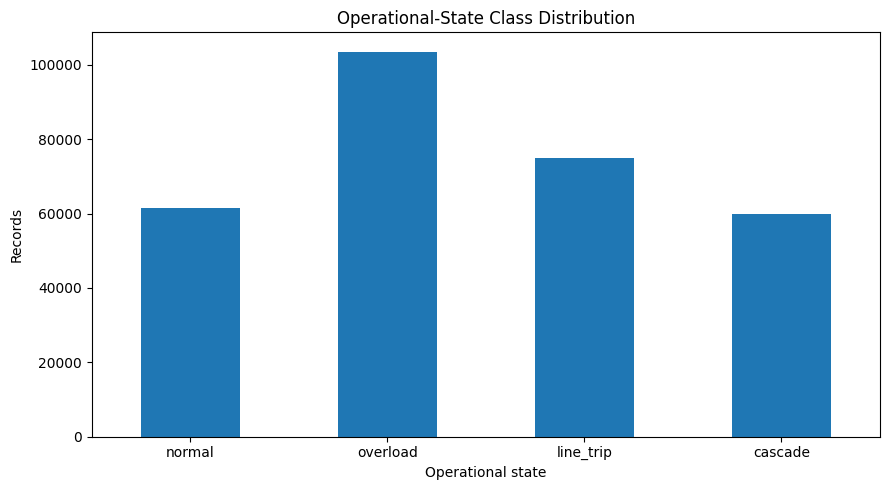

In [5]:
# EDA 02: CLASS DISTRIBUTION ANALYSIS
class_counts = df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
class_percentages = (100 * class_counts / len(df)).round(2)
class_distribution = pd.DataFrame({
    "records": class_counts.astype(int),
    "percentage": class_percentages,
})
store_table("02_class_distribution", class_distribution)
plot_bar(class_counts, "Operational-State Class Distribution", "Operational state", "Records")

In [6]:
# EDA 03: FRAME-BASED PHYSICAL LABEL CONSISTENCY AUDIT
label_consistency = (
    df["label"].astype(str) == df["physical_label_reconstructed"].astype(str)
)
consistency_summary = pd.DataFrame({
    "metric": ["matching labels", "contradictory labels", "consistency percentage"],
    "value": [
        int(label_consistency.sum()),
        int((~label_consistency).sum()),
        round(100 * float(label_consistency.mean()), 6),
    ],
})
store_table("03_physical_label_consistency", consistency_summary)

if (~label_consistency).any():
    print("\nExample contradictions:")
    display(
        df.loc[
            ~label_consistency,
            ["record_index", "label", "physical_label_reconstructed",
             "max_rho", "connected_lines", "disconnected_lines"],
        ].head(30)
    )
else:
    print("\nNo label contradictions were found.")

,metric,value
0,matching labels,300000.0
1,contradictory labels,0.0
2,consistency percentage,100.0



No label contradictions were found.


,records,mean_connected_lines,min_connected_lines,max_connected_lines,mean_disconnected_lines,max_disconnected_lines,mean_connected_fraction
label,,,,,,,
normal,61444,59.0000,59,59,0.0000,0,1.0000
overload,103556,57.1186,47,59,1.8814,12,0.9681
line_trip,75000,58.0000,58,58,1.0000,1,0.9831
cascade,60000,52.7096,0,57,6.2904,59,0.8934


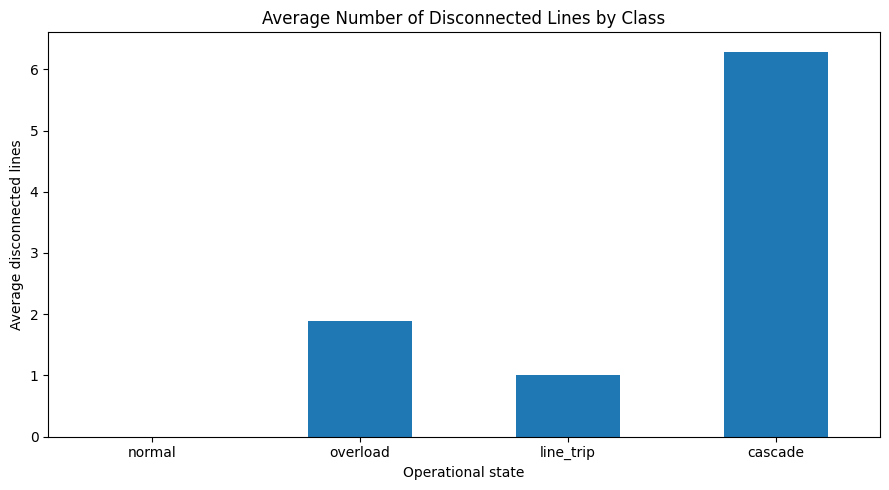

In [7]:
# EDA 04: TOPOLOGY AND LINE-STATUS ANALYSIS
topology_summary = (
    df.groupby("label", observed=False)
      .agg(
          records=("label", "size"),
          mean_connected_lines=("connected_lines", "mean"),
          min_connected_lines=("connected_lines", "min"),
          max_connected_lines=("connected_lines", "max"),
          mean_disconnected_lines=("disconnected_lines", "mean"),
          max_disconnected_lines=("disconnected_lines", "max"),
          mean_connected_fraction=("connected_fraction", "mean"),
      )
      .round(4)
)
store_table("04_topology_summary", topology_summary)

plot_bar(
    df.groupby("label", observed=False)["disconnected_lines"].mean(),
    "Average Number of Disconnected Lines by Class",
    "Operational state",
    "Average disconnected lines",
)


In [8]:
# EDA 05: ZERO-VARIANCE AND NEAR-ZERO-VARIANCE FEATURE CHECK
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
variance_table = pd.DataFrame({
    "feature": numeric_cols,
    "variance": [float(df[column].var()) for column in numeric_cols],
    "unique_values": [int(df[column].nunique(dropna=False)) for column in numeric_cols],
})
variance_table["zero_variance"] = variance_table["variance"].fillna(0.0) == 0.0
variance_table["near_zero_variance"] = variance_table["variance"].fillna(0.0) < 1e-10
variance_table = variance_table.sort_values(
    ["zero_variance", "near_zero_variance", "variance"],
    ascending=[False, False, True],
)
store_table("05_variance_check", variance_table)


,feature,variance,unique_values,zero_variance,near_zero_variance
15,rho_at_clip_count,0.000000e+00,1,True,True
29,total_lines,0.000000e+00,1,True,True
7,min_rho,2.104890e-04,52723,False,False
10,std_rho,4.209312e-03,279559,False,False
9,median_rho,6.423647e-03,274756,False,False
8,mean_rho,6.428915e-03,279550,False,False
11,rho_q75,1.240042e-02,277236,False,False
22,load_gen_ratio,1.332137e-02,279545,False,False
32,connected_fraction,1.342881e-02,14,False,False
6,max_rho,1.122132e-01,274141,False,False


,feature,variance,unique_values,zero_variance,near_zero_variance
15,rho_at_clip_count,0.000000e+00,1,True,True
29,total_lines,0.000000e+00,1,True,True
7,min_rho,2.104890e-04,52723,False,False
10,std_rho,4.209312e-03,279559,False,False
9,median_rho,6.423647e-03,274756,False,False
8,mean_rho,6.428915e-03,279550,False,False
11,rho_q75,1.240042e-02,277236,False,False
22,load_gen_ratio,1.332137e-02,279545,False,False
32,connected_fraction,1.342881e-02,14,False,False
6,max_rho,1.122132e-01,274141,False,False


,max_rho,mean_rho,std_rho,rho_range,rho_above_90_pct,rho_above_100_pct,total_load,total_gen,load_gen_ratio,power_balance,abs_power_balance,mean_abs_p_or,mean_abs_q_or,mean_v_or,mean_v_ex,connected_lines,disconnected_lines,connected_fraction
max_rho,1.0000,0.6448,0.8949,0.9991,0.7237,0.7086,0.2602,0.2729,0.2982,0.5806,0.5806,0.4538,0.3144,0.2271,0.2397,0.2641,-0.2641,0.2641
mean_rho,0.6448,1.0000,0.7519,0.6378,0.5673,0.5236,0.2994,0.3182,0.4565,0.8517,0.8517,0.9263,0.6371,0.4405,0.4470,0.4613,-0.4613,0.4613
std_rho,0.8949,0.7519,1.0000,0.8950,0.8359,0.8168,0.1819,0.1975,0.3328,0.6996,0.6996,0.5389,0.3771,0.2511,0.2640,0.2879,-0.2879,0.2879
rho_range,0.9991,0.6378,0.8950,1.0000,0.7244,0.7088,0.2531,0.2657,0.2926,0.5769,0.5769,0.4471,0.3055,0.2185,0.2312,0.2554,-0.2554,0.2554
rho_above_90_pct,0.7237,0.5673,0.8359,0.7244,1.0000,0.9176,0.0472,0.0614,0.0196,0.6222,0.6222,0.3372,0.1430,-0.0437,-0.0329,-0.0095,0.0095,-0.0095
rho_above_100_pct,0.7086,0.5236,0.8168,0.7088,0.9176,1.0000,0.0456,0.0588,0.0149,0.5771,0.5771,0.2786,0.1291,-0.0479,-0.0382,-0.0149,0.0149,-0.0149
total_load,0.2602,0.2994,0.1819,0.2531,0.0472,0.0456,1.0000,0.9997,0.3750,0.1020,0.1020,0.1857,0.4485,0.3444,0.3442,0.3480,-0.3480,0.3480
total_gen,0.2729,0.3182,0.1975,0.2657,0.0614,0.0588,0.9997,1.0000,0.3776,0.1247,0.1247,0.2038,0.4551,0.3465,0.3465,0.3506,-0.3506,0.3506
load_gen_ratio,0.2982,0.4565,0.3328,0.2926,0.0196,0.0149,0.3750,0.3776,1.0000,0.1578,0.1578,0.4373,0.8264,0.9853,0.9859,0.9872,-0.9872,0.9872
power_balance,0.5806,0.8517,0.6996,0.5769,0.6222,0.5771,0.1020,0.1247,0.1578,1.0000,1.0000,0.8094,0.3386,0.1302,0.1385,0.1527,-0.1527,0.1527


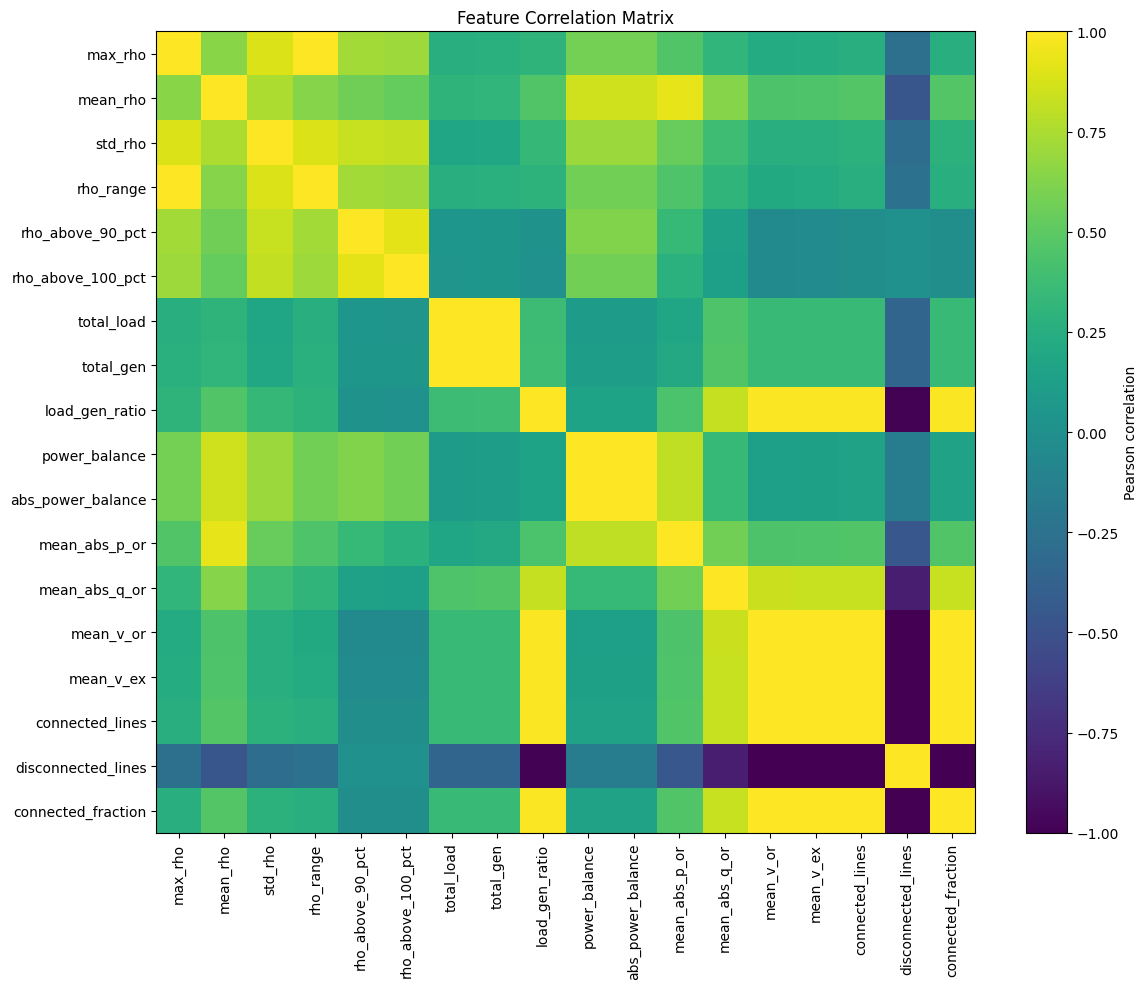

,feature_1,feature_2,correlation
0,max_rho,rho_range,0.999127
1,mean_rho,mean_abs_p_or,0.926294
2,rho_above_90_pct,rho_above_100_pct,0.917559
3,total_load,total_gen,0.999739
4,load_gen_ratio,mean_v_or,0.985297
5,load_gen_ratio,mean_v_ex,0.985921
6,load_gen_ratio,connected_lines,0.987162
7,load_gen_ratio,disconnected_lines,-0.987162
8,load_gen_ratio,connected_fraction,0.987162
9,power_balance,abs_power_balance,1.000000


,feature_1,feature_2,correlation
0,max_rho,rho_range,0.999127
1,mean_rho,mean_abs_p_or,0.926294
2,rho_above_90_pct,rho_above_100_pct,0.917559
3,total_load,total_gen,0.999739
4,load_gen_ratio,mean_v_or,0.985297
5,load_gen_ratio,mean_v_ex,0.985921
6,load_gen_ratio,connected_lines,0.987162
7,load_gen_ratio,disconnected_lines,-0.987162
8,load_gen_ratio,connected_fraction,0.987162
9,power_balance,abs_power_balance,1.000000


In [9]:
# EDA 06: FEATURE CORRELATION MATRIX
corr_features = MODEL_FEATURES_FULL
correlation_matrix = df[corr_features].corr(numeric_only=True)
store_table("06_correlation_matrix", correlation_matrix.round(4))

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_features)), corr_features, rotation=90)
plt.yticks(range(len(corr_features)), corr_features)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for left, right in combinations(corr_features, 2):
    value = float(correlation_matrix.loc[left, right])
    if abs(value) >= 0.90:
        high_corr_pairs.append({"feature_1": left, "feature_2": right, "correlation": value})
store_table("06_high_correlation_pairs", pd.DataFrame(high_corr_pairs))


,mean_connected_fraction,mean_disconnected_lines,mean_max_rho,mean_abs_active_flow,mean_abs_reactive_flow
label,,,,,
normal,1.00000,0.00000,0.73692,25.77212,16.25897
overload,0.96811,1.88143,1.30335,28.55152,15.94224
line_trip,0.98305,1.00000,0.75374,25.54509,16.11110
cascade,0.89338,6.29040,0.71991,23.68719,14.65322


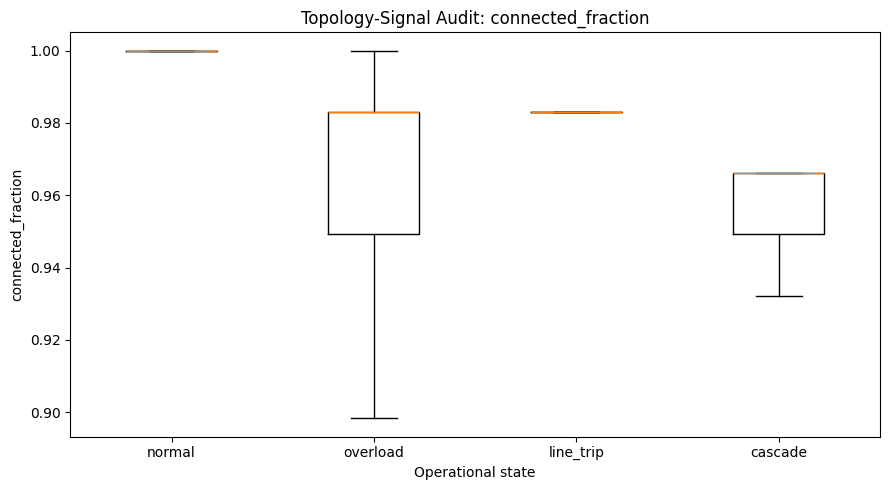

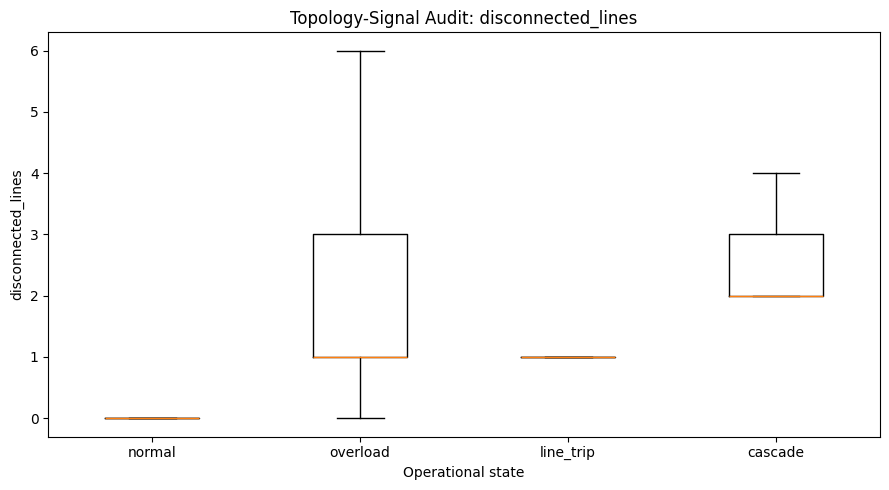

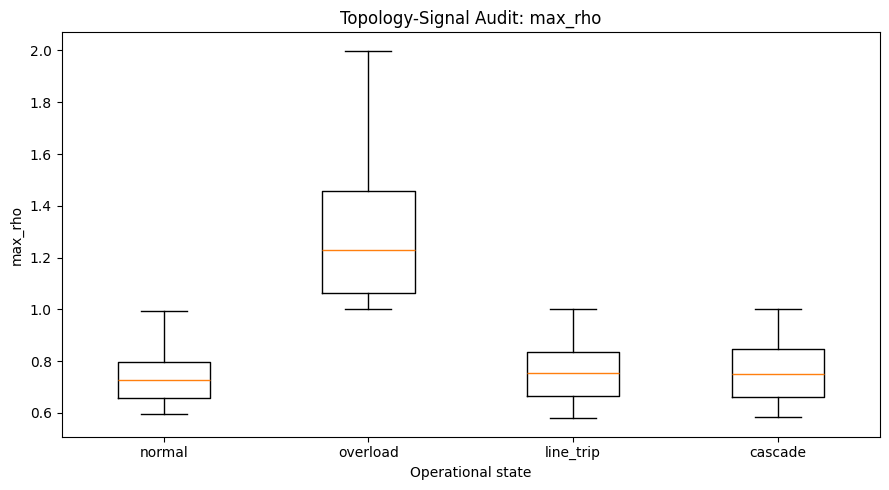

In [10]:
# EDA 07: NODE-VERSUS-EDGE TOPOLOGY-SIGNAL AUDIT
# This EDA checks whether topology changes are visible in graph-relevant aggregates.
topology_signal = (
    df.groupby("label", observed=False)
      .agg(
          mean_connected_fraction=("connected_fraction", "mean"),
          mean_disconnected_lines=("disconnected_lines", "mean"),
          mean_max_rho=("max_rho", "mean"),
          mean_abs_active_flow=("mean_abs_p_or", "mean"),
          mean_abs_reactive_flow=("mean_abs_q_or", "mean"),
      )
      .round(5)
)
store_table("07_node_edge_topology_signals", topology_signal)

for feature in ["connected_fraction", "disconnected_lines", "max_rho"]:
    grouped = []
    for label in LABEL_ORDER:
        label_values = df.loc[df["label"].astype(str) == label, feature]
        grouped.append(
            label_values.sample(n=min(1500, len(label_values)), random_state=RANDOM_STATE).values
        )
    plt.figure(figsize=(9, 5))
    plt.boxplot(grouped, labels=LABEL_ORDER, showfliers=False)
    plt.title(f"Topology-Signal Audit: {feature}")
    plt.xlabel("Operational state")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


,localized_records,unlocalized_records,unique_localized_substations,most_common_fault_substation,largest_substation_count
0,178556,121444,30,1,1098


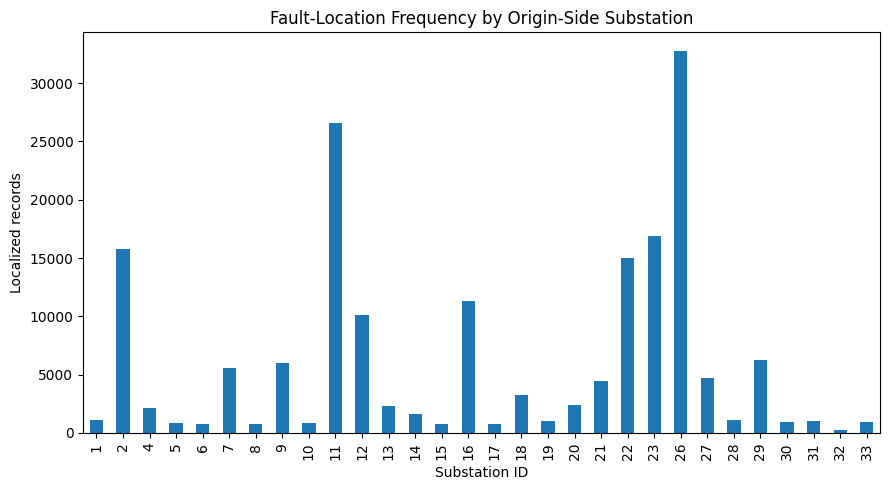

In [11]:
# EDA 08: FAULT-LOCALIZATION BIAS CHECK
localized = df[df["fault_loc"] >= 0].copy()
fault_loc_counts = localized["fault_loc"].value_counts().sort_index()
fault_loc_summary = pd.DataFrame({
    "localized_records": [len(localized)],
    "unlocalized_records": [int((df["fault_loc"] < 0).sum())],
    "unique_localized_substations": [int(localized["fault_loc"].nunique())],
    "most_common_fault_substation": [int(fault_loc_counts.index[0]) if len(fault_loc_counts) else -1],
    "largest_substation_count": [int(fault_loc_counts.iloc[0]) if len(fault_loc_counts) else 0],
})
store_table("08_fault_localization_summary", fault_loc_summary)

if len(fault_loc_counts):
    plot_bar(
        fault_loc_counts,
        "Fault-Location Frequency by Origin-Side Substation",
        "Substation ID",
        "Localized records",
        rotation=90,
    )


,rho_mean_proxy,rho_max_proxy,rho_spread_proxy,active_edge_count_proxy,disconnected_edge_count_proxy
label,,,,,
normal,0.32609,0.73692,0.70780,59.00000,0.00000
overload,0.38484,1.30335,1.30206,57.11857,1.88143
line_trip,0.32270,0.75374,0.75374,58.00000,1.00000
cascade,0.29628,0.71991,0.71991,52.70960,6.29040


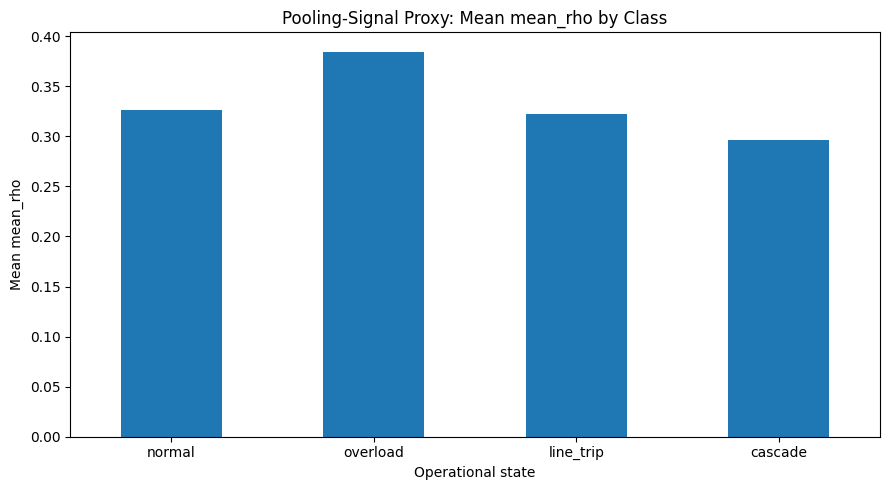

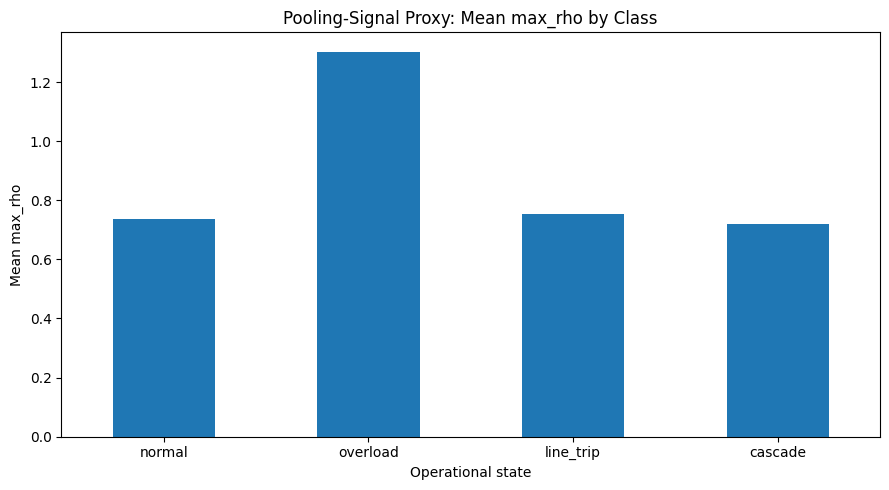

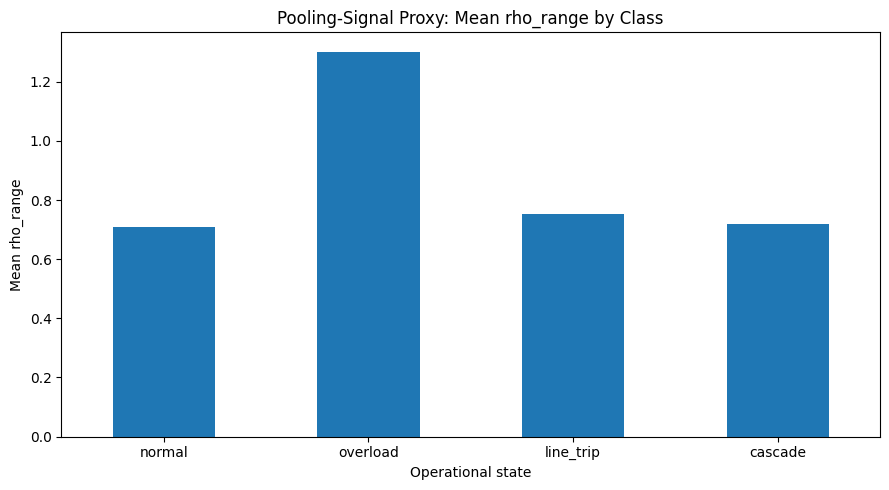

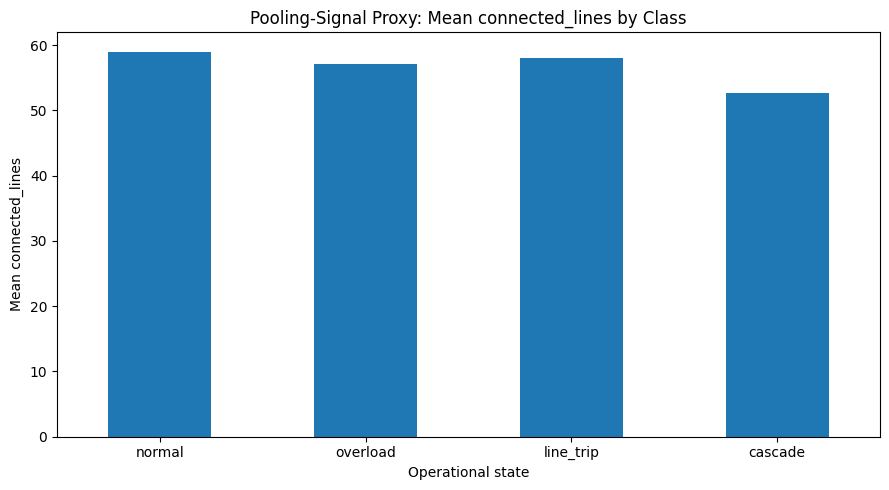

In [12]:
# EDA 09: GRAPH-POOLING SIGNAL HYPOTHESIS TEST
# Proxy statistics show why mean, max, and extreme-value pooling preserve different signals.
pooling_proxy = (
    df.groupby("label", observed=False)
      .agg(
          rho_mean_proxy=("mean_rho", "mean"),
          rho_max_proxy=("max_rho", "mean"),
          rho_spread_proxy=("rho_range", "mean"),
          active_edge_count_proxy=("connected_lines", "mean"),
          disconnected_edge_count_proxy=("disconnected_lines", "mean"),
      )
      .round(5)
)
store_table("09_pooling_signal_proxy", pooling_proxy)

for feature in ["mean_rho", "max_rho", "rho_range", "connected_lines"]:
    series = df.groupby("label", observed=False)[feature].mean()
    plot_bar(series, f"Pooling-Signal Proxy: Mean {feature} by Class", "Operational state", f"Mean {feature}")


## **B. Data Quality and Descriptive Exploration**


In [13]:
# EDA 10: BASIC DESCRIPTIVE STATISTICS
descriptive_statistics = df[MODEL_FEATURES_FULL + ["fault_loc", "timestep", "reward"]].describe().T
store_table("10_descriptive_statistics", descriptive_statistics.round(5))


,count,mean,std,min,25%,50%,75%,max
max_rho,300000.0,0.93325,0.33498,0.0,0.69861,0.83158,1.07638,2.00000
mean_rho,300000.0,0.33956,0.08018,0.0,0.29132,0.33246,0.39134,0.72652
std_rho,300000.0,0.20503,0.06488,0.0,0.16701,0.19120,0.22755,0.60892
rho_range,300000.0,0.92684,0.33851,0.0,0.68814,0.82308,1.07573,2.00000
rho_above_90_pct,300000.0,1.19728,2.37189,0.0,0.00000,0.00000,1.00000,20.00000
rho_above_100_pct,300000.0,0.79026,1.78735,0.0,0.00000,0.00000,1.00000,19.00000
total_load,300000.0,703.99932,234.76559,0.0,576.28000,661.42500,780.71000,1836.73999
total_gen,300000.0,713.94462,235.37855,0.0,586.13819,672.86645,790.44332,1858.33154
load_gen_ratio,300000.0,0.97170,0.11542,0.0,0.98135,0.98594,0.99127,0.99741
power_balance,300000.0,9.94530,5.40606,0.0,6.32529,8.75067,12.50437,131.68300


,count,mean,std,min,25%,50%,75%,max
max_rho,300000.0,0.93325,0.33498,0.0,0.69861,0.83158,1.07638,2.00000
mean_rho,300000.0,0.33956,0.08018,0.0,0.29132,0.33246,0.39134,0.72652
std_rho,300000.0,0.20503,0.06488,0.0,0.16701,0.19120,0.22755,0.60892
rho_range,300000.0,0.92684,0.33851,0.0,0.68814,0.82308,1.07573,2.00000
rho_above_90_pct,300000.0,1.19728,2.37189,0.0,0.00000,0.00000,1.00000,20.00000
rho_above_100_pct,300000.0,0.79026,1.78735,0.0,0.00000,0.00000,1.00000,19.00000
total_load,300000.0,703.99932,234.76559,0.0,576.28000,661.42500,780.71000,1836.73999
total_gen,300000.0,713.94462,235.37855,0.0,586.13819,672.86645,790.44332,1858.33154
load_gen_ratio,300000.0,0.97170,0.11542,0.0,0.98135,0.98594,0.99127,0.99741
power_balance,300000.0,9.94530,5.40606,0.0,6.32529,8.75067,12.50437,131.68300


In [14]:
# EDA 11: MISSING-VALUE AND NON-FINITE-VALUE AUDIT
numeric_frame = df.select_dtypes(include=[np.number])
quality_table = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": (100 * df.isna().mean()).round(6),
})
quality_table["positive_infinity"] = 0
quality_table["negative_infinity"] = 0
for column in numeric_frame.columns:
    values = numeric_frame[column].to_numpy(dtype=float)
    quality_table.loc[column, "positive_infinity"] = int(np.isposinf(values).sum())
    quality_table.loc[column, "negative_infinity"] = int(np.isneginf(values).sum())

store_table("11_missing_and_nonfinite_values", quality_table)


,missing_values,missing_percentage,positive_infinity,negative_infinity
record_index,0,0.0,0,0
label,0,0.0,0,0
label_int,0,0.0,0,0
physical_label_reconstructed,0,0.0,0,0
fault_loc,0,0.0,0,0
timestep,0,0.0,0,0
chronic_id,0,0.0,0,0
reward,0,0.0,0,0
max_rho,0,0.0,0,0
min_rho,0,0.0,0,0


,missing_values,missing_percentage,positive_infinity,negative_infinity
record_index,0,0.0,0,0
label,0,0.0,0,0
label_int,0,0.0,0,0
physical_label_reconstructed,0,0.0,0,0
fault_loc,0,0.0,0,0
timestep,0,0.0,0,0
chronic_id,0,0.0,0,0
reward,0,0.0,0,0
max_rho,0,0.0,0,0
min_rho,0,0.0,0,0


In [15]:
# EDA 12: DUPLICATE-RECORD ANALYSIS
aggregate_duplicate_cols = [
    "label", "max_rho", "mean_rho", "std_rho",
    "total_load", "total_gen", "connected_lines",
    "disconnected_lines", "fault_loc", "timestep", "chronic_id",
]
aggregate_duplicate_mask = df.duplicated(subset=aggregate_duplicate_cols, keep=False)
duplicate_summary = pd.DataFrame({
    "metric": ["rows in aggregate-level duplicate groups", "aggregate-level duplicate percentage"],
    "value": [
        int(aggregate_duplicate_mask.sum()),
        round(100 * float(aggregate_duplicate_mask.mean()), 6),
    ],
})
store_table("12_duplicate_summary", duplicate_summary)

if aggregate_duplicate_mask.any():
    display(df.loc[aggregate_duplicate_mask, aggregate_duplicate_cols].head(30))


,metric,value
0,rows in aggregate-level duplicate groups,0.0
1,aggregate-level duplicate percentage,0.0


In [16]:
# EDA 13: DATA-TYPE AND CARDINALITY VERIFICATION
dtype_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False),
    "missing_values": df.isna().sum(),
})
store_table("13_dtype_cardinality", dtype_table)


,dtype,unique_values,missing_values
record_index,int64,300000,0
label,category,4,0
label_int,int64,4,0
physical_label_reconstructed,object,4,0
fault_loc,int64,31,0
timestep,int64,1455,0
chronic_id,int64,26605,0
reward,float64,261869,0
max_rho,float64,274141,0
min_rho,float64,52723,0


,dtype,unique_values,missing_values
record_index,int64,300000,0
label,category,4,0
label_int,int64,4,0
physical_label_reconstructed,object,4,0
fault_loc,int64,31,0
timestep,int64,1455,0
chronic_id,int64,26605,0
reward,float64,261869,0
max_rho,float64,274141,0
min_rho,float64,52723,0


In [17]:
# EDA 14: FEATURE-RANGE AND METADATA-CONSISTENCY CHECK
range_table = pd.DataFrame({
    "minimum": df[MODEL_FEATURES_FULL].min(),
    "maximum": df[MODEL_FEATURES_FULL].max(),
    "mean": df[MODEL_FEATURES_FULL].mean(),
    "standard_deviation": df[MODEL_FEATURES_FULL].std(),
}).round(6)
store_table("14_feature_ranges", range_table)

metadata_check = pd.DataFrame({
    "metadata_field": [
        "environment", "total_records", "n_sub", "n_line", "n_load", "n_gen",
        "rho_clip", "node_feature_dim", "edge_feature_dim",
    ],
    "metadata_value": [
        metadata.get("env_name"), metadata.get("total_records"),
        metadata.get("n_sub"), metadata.get("n_line"), metadata.get("n_load"),
        metadata.get("n_gen"), metadata.get("rho_clip"),
        metadata.get("node_feature_dim"), metadata.get("edge_feature_dim"),
    ],
    "observed_or_expected_value": [
        "l2rpn_neurips_2020_track1_small", len(df),
        metadata.get("n_sub"), int(df["total_lines"].iloc[0]),
        metadata.get("n_load"), metadata.get("n_gen"),
        float(df["max_rho"].max()), 4,
        "Generator metadata stores 3 raw edge measurements; current pyg_data.py constructs 4 edge attributes including line_status.",
    ],
})
store_table("14_metadata_consistency", metadata_check)


,minimum,maximum,mean,standard_deviation
max_rho,0.0,1.999998,0.933250,0.334982
mean_rho,0.0,0.726524,0.339559,0.080181
std_rho,0.0,0.608918,0.205027,0.064879
rho_range,0.0,1.999998,0.926839,0.338513
rho_above_90_pct,0.0,20.000000,1.197277,2.371895
rho_above_100_pct,0.0,19.000000,0.790257,1.787354
total_load,0.0,1836.739986,703.999316,234.765593
total_gen,0.0,1858.331535,713.944618,235.378553
load_gen_ratio,0.0,0.997414,0.971701,0.115418
power_balance,0.0,131.682998,9.945302,5.406062


,metadata_field,metadata_value,observed_or_expected_value
0,environment,l2rpn_neurips_2020_track1_small,l2rpn_neurips_2020_track1_small
1,total_records,300000,300000
2,n_sub,36,36
3,n_line,59,59
4,n_load,37,37
5,n_gen,22,22
6,rho_clip,2.0,1.999998
7,node_feature_dim,4,4
8,edge_feature_dim,3,Generator metadata stores 3 raw edge measureme...


,metadata_field,metadata_value,observed_or_expected_value
0,environment,l2rpn_neurips_2020_track1_small,l2rpn_neurips_2020_track1_small
1,total_records,300000,300000
2,n_sub,36,36
3,n_line,59,59
4,n_load,37,37
5,n_gen,22,22
6,rho_clip,2.0,1.999998
7,node_feature_dim,4,4
8,edge_feature_dim,3,Generator metadata stores 3 raw edge measureme...


## **C. Visualization of Class-Conditional Behaviour**


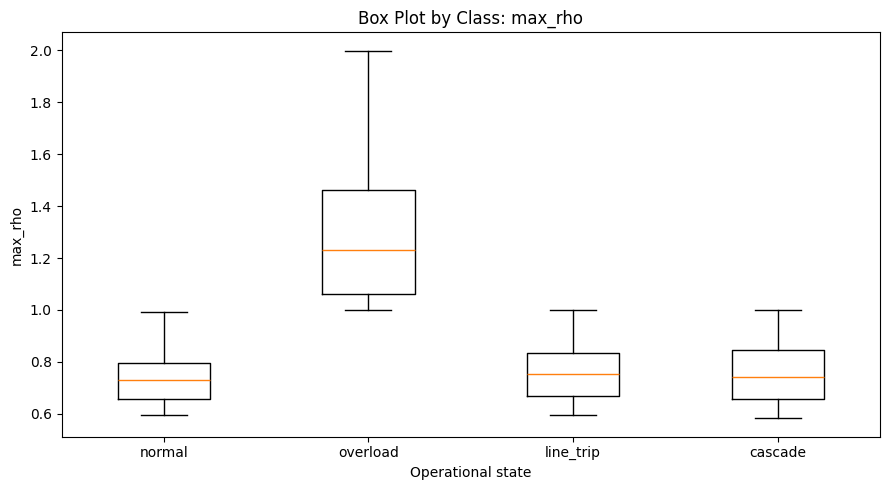

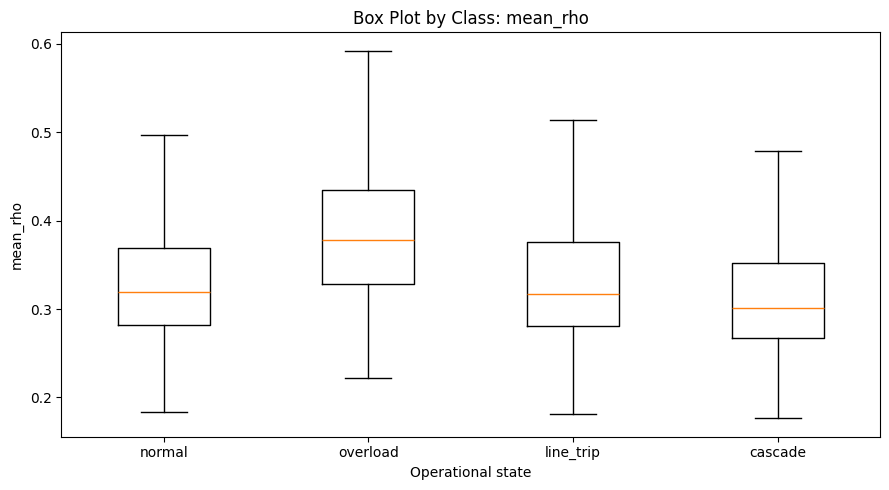

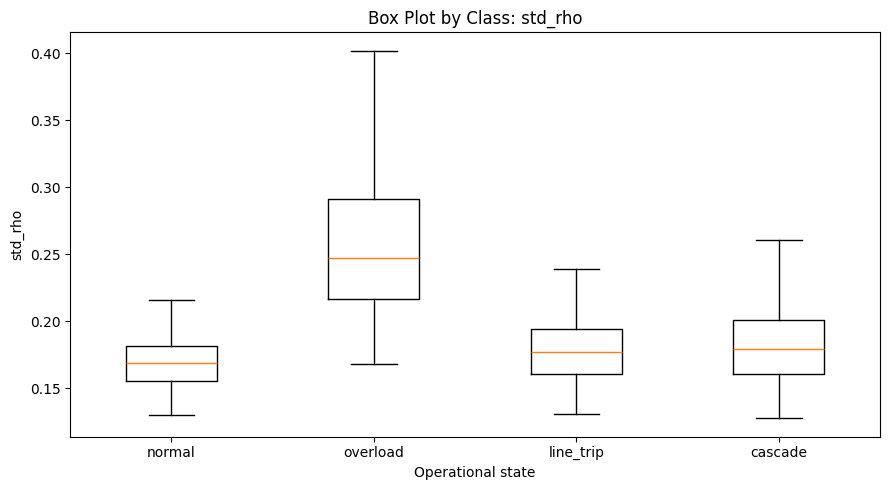

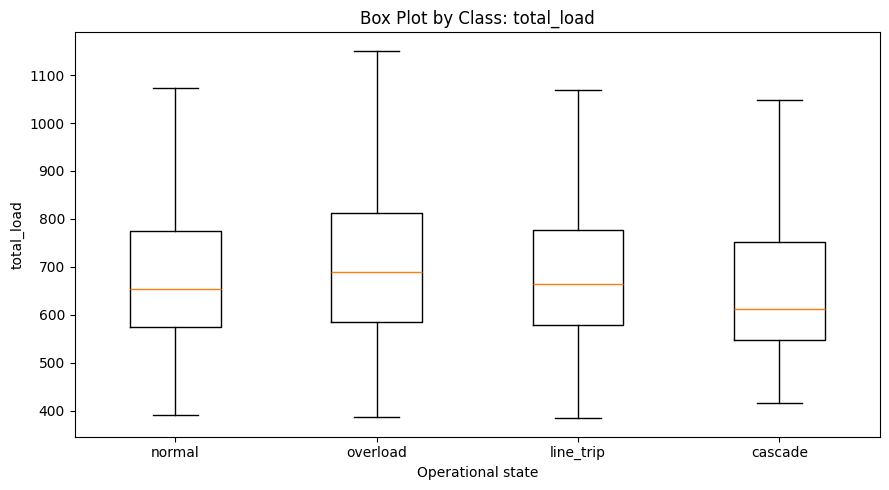

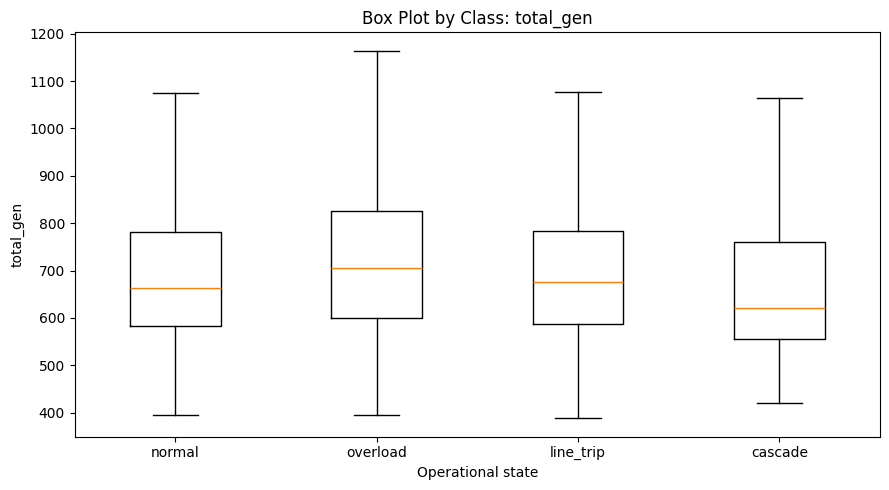

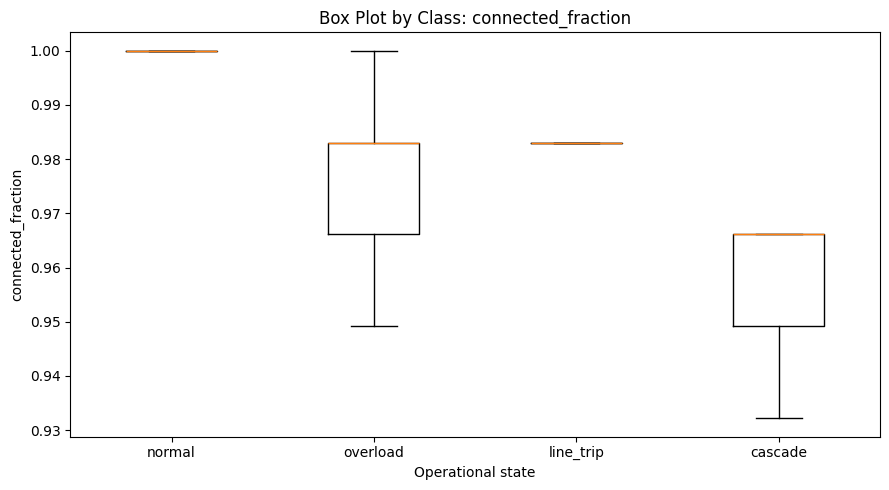

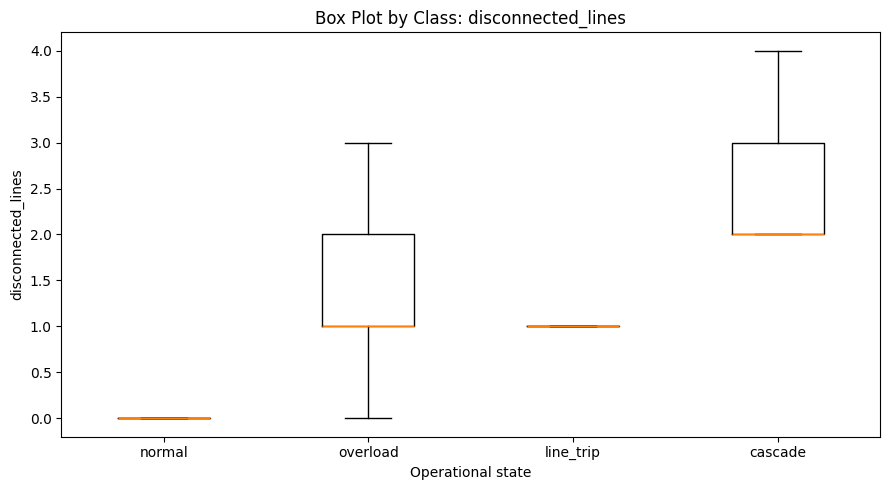

In [18]:
# EDA 15: BOX-PLOT VISUALIZATION BY CLASS
box_features = ["max_rho", "mean_rho", "std_rho", "total_load", "total_gen", "connected_fraction", "disconnected_lines"]
sample = stratified_sample(df, VIS_SAMPLE_SIZE)

for feature in box_features:
    grouped = [sample.loc[sample["label"].astype(str) == label, feature].values for label in LABEL_ORDER]
    plt.figure(figsize=(9, 5))
    plt.boxplot(grouped, labels=LABEL_ORDER, showfliers=False)
    plt.title(f"Box Plot by Class: {feature}")
    plt.xlabel("Operational state")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


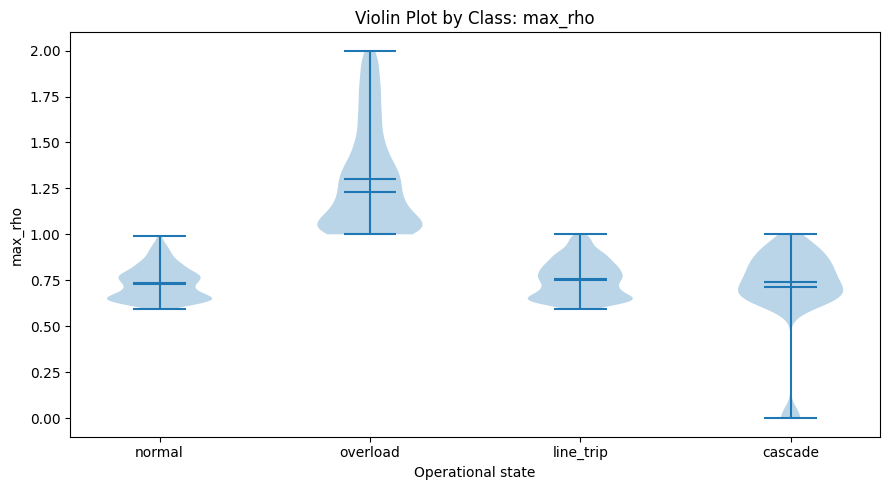

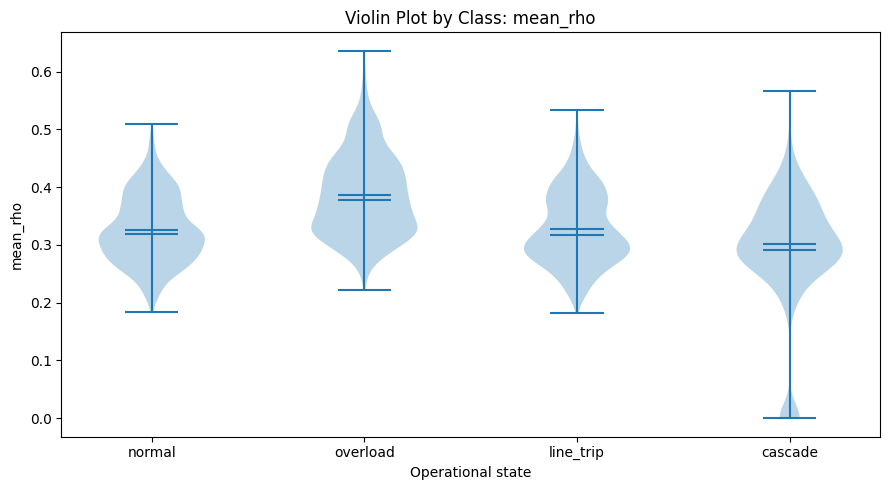

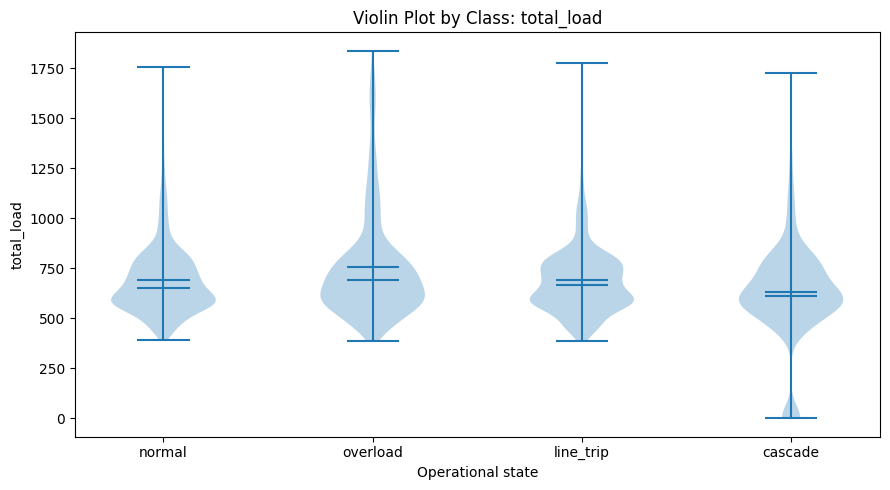

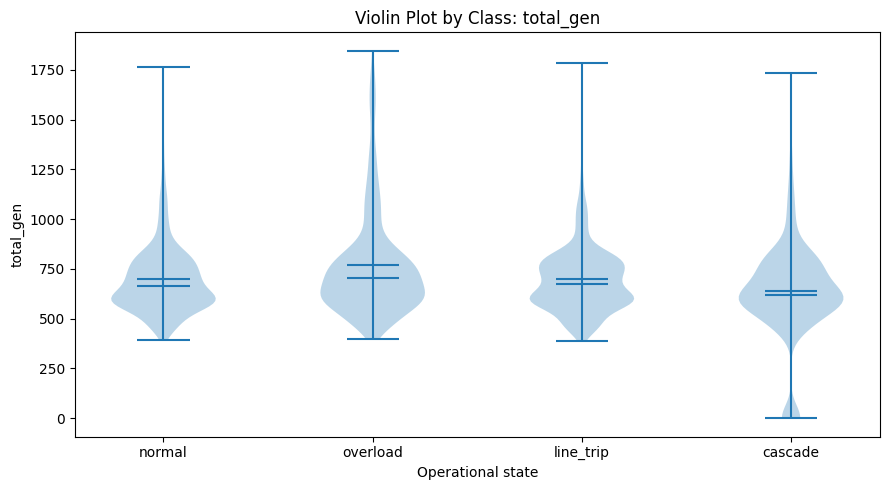

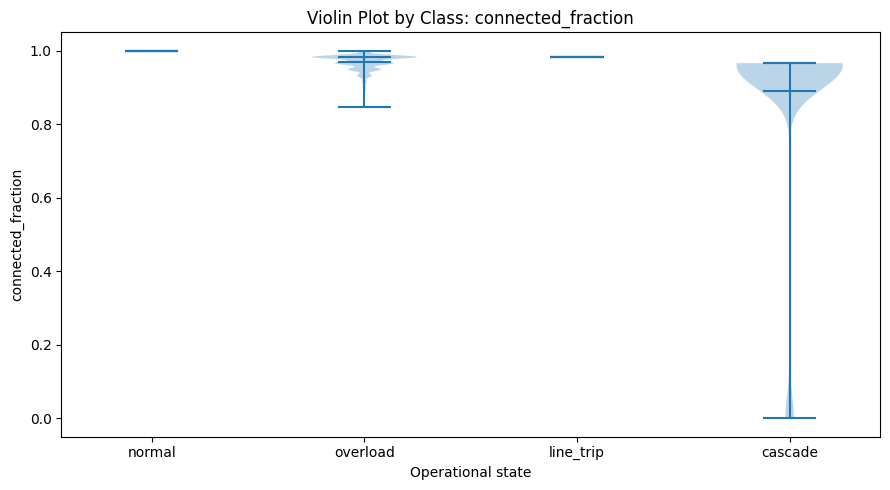

In [19]:
# EDA 16: VIOLIN-PLOT DISTRIBUTION BY CLASS
violin_features = ["max_rho", "mean_rho", "total_load", "total_gen", "connected_fraction"]
sample = stratified_sample(df, VIS_SAMPLE_SIZE)

for feature in violin_features:
    grouped = [sample.loc[sample["label"].astype(str) == label, feature].values for label in LABEL_ORDER]
    plt.figure(figsize=(9, 5))
    plt.violinplot(grouped, showmeans=True, showmedians=True)
    plt.xticks(range(1, len(LABEL_ORDER) + 1), LABEL_ORDER)
    plt.title(f"Violin Plot by Class: {feature}")
    plt.xlabel("Operational state")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


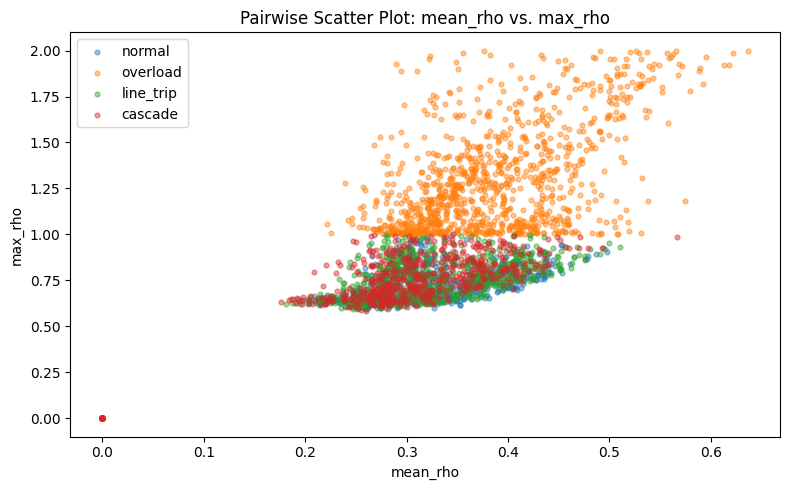

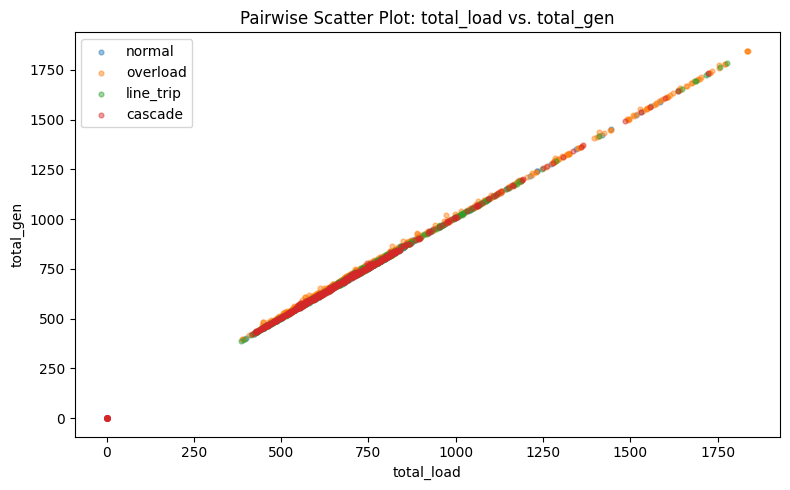

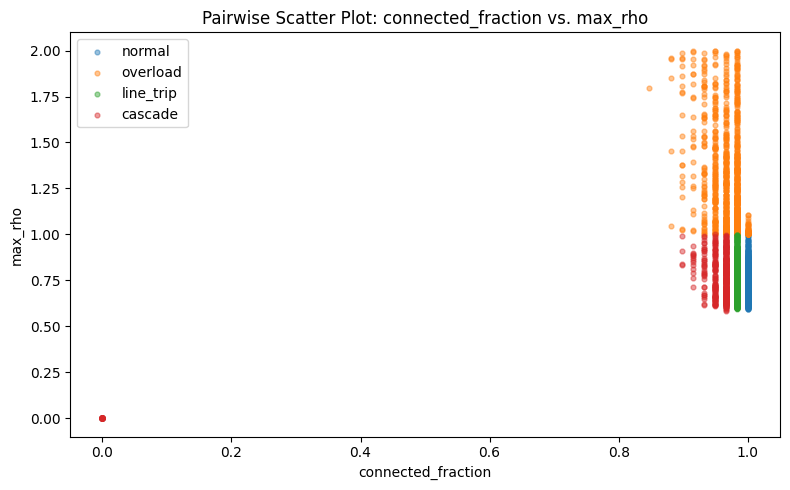

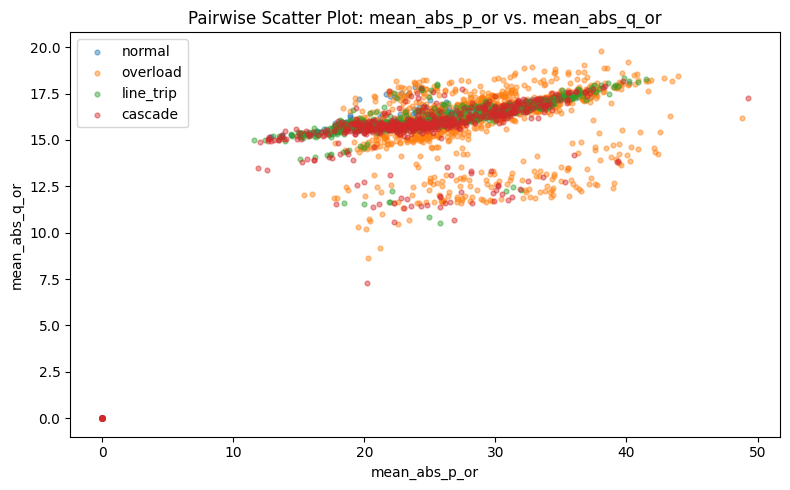

In [20]:
# EDA 17: PAIRWISE SCATTER-MATRIX EQUIVALENT
# Separate charts are used instead of a subplot matrix to keep every figure readable.
scatter_pairs = [
    ("mean_rho", "max_rho"),
    ("total_load", "total_gen"),
    ("connected_fraction", "max_rho"),
    ("mean_abs_p_or", "mean_abs_q_or"),
]
sample = stratified_sample(df, min(3000, VIS_SAMPLE_SIZE))

for x_feature, y_feature in scatter_pairs:
    plt.figure(figsize=(8, 5))
    for label in LABEL_ORDER:
        group = sample[sample["label"].astype(str) == label]
        plt.scatter(group[x_feature], group[y_feature], s=12, alpha=0.45, label=label)
    plt.title(f"Pairwise Scatter Plot: {x_feature} vs. {y_feature}")
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend()
    plt.tight_layout()
    plt.show()


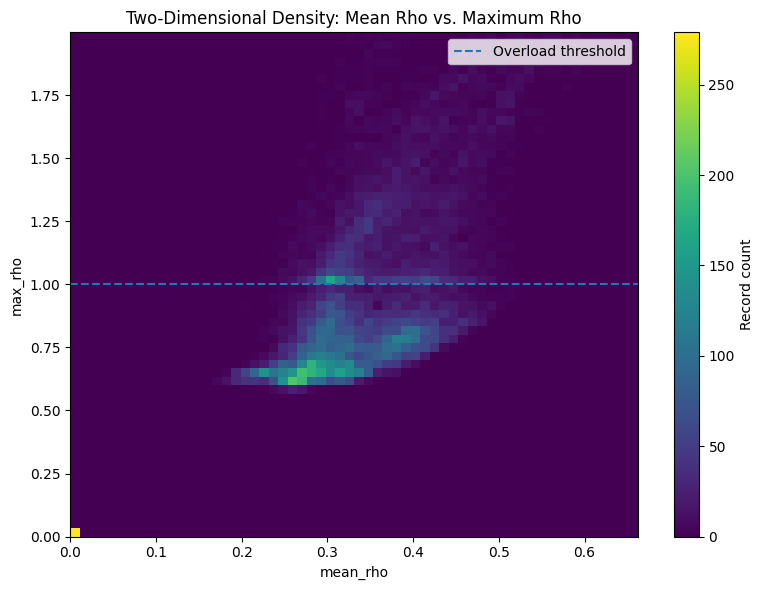

In [21]:
# EDA 18: TWO-DIMENSIONAL DENSITY HEATMAP
sample = stratified_sample(df, min(20_000, len(df)))
plt.figure(figsize=(8, 6))
plt.hist2d(sample["mean_rho"], sample["max_rho"], bins=60)
plt.colorbar(label="Record count")
plt.axhline(1.0, linestyle="--", label="Overload threshold")
plt.title("Two-Dimensional Density: Mean Rho vs. Maximum Rho")
plt.xlabel("mean_rho")
plt.ylabel("max_rho")
plt.legend()
plt.tight_layout()
plt.show()


## **D. Statistical Testing**


In [22]:
# EDA 19: ONE-WAY ANOVA ACROSS OPERATIONAL CLASSES
from scipy.stats import f_oneway

anova_rows = []
for feature in MODEL_FEATURES_FULL:
    groups = []
    for label in LABEL_ORDER:
        values = df.loc[df["label"].astype(str) == label, feature].dropna()
        groups.append(values.sample(n=min(STAT_SAMPLE_SIZE // len(LABEL_ORDER), len(values)), random_state=RANDOM_STATE).values)
    statistic, p_value = f_oneway(*groups)
    anova_rows.append({"feature": feature, "f_statistic": statistic, "p_value": p_value})

anova_table = pd.DataFrame(anova_rows).sort_values("p_value")
store_table("19_anova_results", anova_table)


,feature,f_statistic,p_value
0,max_rho,11231.424567,0.000000e+00
1,mean_rho,1238.047805,0.000000e+00
2,std_rho,4897.962033,0.000000e+00
3,rho_range,11522.556242,0.000000e+00
4,rho_above_90_pct,4298.390824,0.000000e+00
5,rho_above_100_pct,4423.342738,0.000000e+00
10,abs_power_balance,1042.744918,0.000000e+00
9,power_balance,1042.744918,0.000000e+00
14,mean_v_ex,712.982774,0.000000e+00
15,connected_lines,740.759565,0.000000e+00


,feature,f_statistic,p_value
0,max_rho,11231.424567,0.000000e+00
1,mean_rho,1238.047805,0.000000e+00
2,std_rho,4897.962033,0.000000e+00
3,rho_range,11522.556242,0.000000e+00
4,rho_above_90_pct,4298.390824,0.000000e+00
5,rho_above_100_pct,4423.342738,0.000000e+00
10,abs_power_balance,1042.744918,0.000000e+00
9,power_balance,1042.744918,0.000000e+00
14,mean_v_ex,712.982774,0.000000e+00
15,connected_lines,740.759565,0.000000e+00


In [23]:
# EDA 20: CHI-SQUARE TEST FOR LABEL ASSOCIATION WITH DISCRETE GRID STATES
from scipy.stats import chi2_contingency

chi_square_rows = []
discrete_candidates = {
    "disconnected_lines": pd.cut(df["disconnected_lines"], bins=[-1, 0, 1, 3, np.inf], labels=["0", "1", "2-3", "4+"]),
    "rho_above_100_pct": pd.cut(df["rho_above_100_pct"], bins=[-1, 0, 1, 3, np.inf], labels=["0", "1", "2-3", "4+"]),
    "rho_above_90_pct": pd.cut(df["rho_above_90_pct"], bins=[-1, 0, 1, 3, np.inf], labels=["0", "1", "2-3", "4+"]),
}

for feature, binned in discrete_candidates.items():
    contingency = pd.crosstab(df["label"], binned)
    statistic, p_value, dof, _ = chi2_contingency(contingency)
    chi_square_rows.append({
        "feature": feature,
        "chi_square": statistic,
        "degrees_of_freedom": dof,
        "p_value": p_value,
    })

chi_square_table = pd.DataFrame(chi_square_rows).sort_values("p_value")
store_table("20_chi_square_results", chi_square_table)


,feature,chi_square,degrees_of_freedom,p_value
0,disconnected_lines,449069.282670,9,0.0
1,rho_above_100_pct,300000.000000,9,0.0
2,rho_above_90_pct,234561.044284,9,0.0


,feature,chi_square,degrees_of_freedom,p_value
0,disconnected_lines,449069.282670,9,0.0
1,rho_above_100_pct,300000.000000,9,0.0
2,rho_above_90_pct,234561.044284,9,0.0


In [24]:
# EDA 21: PAIRWISE KOLMOGOROV-SMIRNOV DISTRIBUTION TEST
from scipy.stats import ks_2samp

ks_rows = []
ks_features = ["max_rho", "mean_rho", "total_load", "total_gen", "connected_fraction"]
for feature in ks_features:
    for label_a, label_b in combinations(LABEL_ORDER, 2):
        values_a = df.loc[df["label"].astype(str) == label_a, feature].dropna()
        values_b = df.loc[df["label"].astype(str) == label_b, feature].dropna()
        values_a = values_a.sample(n=min(5000, len(values_a)), random_state=RANDOM_STATE)
        values_b = values_b.sample(n=min(5000, len(values_b)), random_state=RANDOM_STATE)
        statistic, p_value = ks_2samp(values_a, values_b)
        ks_rows.append({
            "feature": feature,
            "class_a": label_a,
            "class_b": label_b,
            "ks_statistic": statistic,
            "p_value": p_value,
        })

ks_table = pd.DataFrame(ks_rows).sort_values(["feature", "p_value"])
store_table("21_pairwise_ks_results", ks_table)


,feature,class_a,class_b,ks_statistic,p_value
24,connected_fraction,normal,overload,0.9494,0.000000e+00
25,connected_fraction,normal,line_trip,1.0000,0.000000e+00
26,connected_fraction,normal,cascade,1.0000,0.000000e+00
27,connected_fraction,overload,line_trip,0.5042,0.000000e+00
28,connected_fraction,overload,cascade,0.4958,0.000000e+00
29,connected_fraction,line_trip,cascade,1.0000,0.000000e+00
0,max_rho,normal,overload,1.0000,0.000000e+00
3,max_rho,overload,line_trip,1.0000,0.000000e+00
4,max_rho,overload,cascade,1.0000,0.000000e+00
2,max_rho,normal,cascade,0.1342,1.200330e-39


,feature,class_a,class_b,ks_statistic,p_value
24,connected_fraction,normal,overload,0.9494,0.000000e+00
25,connected_fraction,normal,line_trip,1.0000,0.000000e+00
26,connected_fraction,normal,cascade,1.0000,0.000000e+00
27,connected_fraction,overload,line_trip,0.5042,0.000000e+00
28,connected_fraction,overload,cascade,0.4958,0.000000e+00
29,connected_fraction,line_trip,cascade,1.0000,0.000000e+00
0,max_rho,normal,overload,1.0000,0.000000e+00
3,max_rho,overload,line_trip,1.0000,0.000000e+00
4,max_rho,overload,cascade,1.0000,0.000000e+00
2,max_rho,normal,cascade,0.1342,1.200330e-39


In [25]:
# EDA 22: SHAPIRO-WILK NORMALITY TEST
from scipy.stats import shapiro

shapiro_rows = []
for feature in MODEL_FEATURES_REDUCED:
    values = df[feature].dropna()
    values = values.sample(n=min(5000, len(values)), random_state=RANDOM_STATE)
    statistic, p_value = shapiro(values)
    shapiro_rows.append({
        "feature": feature,
        "shapiro_statistic": statistic,
        "p_value": p_value,
        "approximately_normal_at_0_05": bool(p_value >= 0.05),
    })

shapiro_table = pd.DataFrame(shapiro_rows).sort_values("p_value")
store_table("22_shapiro_normality", shapiro_table)


,feature,shapiro_statistic,p_value,approximately_normal_at_0_05
6,load_gen_ratio,0.120156,7.618965e-93,False
12,mean_v_ex,0.209343,2.269482e-90,False
11,mean_v_or,0.216042,3.559931e-90,False
10,mean_abs_q_or,0.553152,9.740851e-78,False
3,rho_above_90_pct,0.566910,4.495913e-77,False
1,std_rho,0.853616,7.728687e-56,False
4,total_load,0.866947,3.887373e-54,False
7,power_balance,0.869876,9.600471e-54,False
8,abs_power_balance,0.869876,9.600471e-54,False
5,total_gen,0.870699,1.241692e-53,False


,feature,shapiro_statistic,p_value,approximately_normal_at_0_05
6,load_gen_ratio,0.120156,7.618965e-93,False
12,mean_v_ex,0.209343,2.269482e-90,False
11,mean_v_or,0.216042,3.559931e-90,False
10,mean_abs_q_or,0.553152,9.740851e-78,False
3,rho_above_90_pct,0.566910,4.495913e-77,False
1,std_rho,0.853616,7.728687e-56,False
4,total_load,0.866947,3.887373e-54,False
7,power_balance,0.869876,9.600471e-54,False
8,abs_power_balance,0.869876,9.600471e-54,False
5,total_gen,0.870699,1.241692e-53,False


In [26]:
# EDA 23: LEVENE TEST FOR HOMOGENEITY OF VARIANCE
from scipy.stats import levene

levene_rows = []
for feature in MODEL_FEATURES_FULL:
    groups = []
    for label in LABEL_ORDER:
        values = df.loc[df["label"].astype(str) == label, feature].dropna()
        groups.append(values.sample(n=min(5000, len(values)), random_state=RANDOM_STATE).values)
    statistic, p_value = levene(*groups, center="median")
    levene_rows.append({
        "feature": feature,
        "levene_statistic": statistic,
        "p_value": p_value,
        "equal_variance_at_0_05": bool(p_value >= 0.05),
    })

levene_table = pd.DataFrame(levene_rows).sort_values("p_value")
store_table("23_levene_results", levene_table)


,feature,levene_statistic,p_value,equal_variance_at_0_05
0,max_rho,1281.477983,0.000000e+00,False
2,std_rho,915.734448,0.000000e+00,False
3,rho_range,1316.886261,0.000000e+00,False
4,rho_above_90_pct,2060.628996,0.000000e+00,False
5,rho_above_100_pct,1417.282546,0.000000e+00,False
12,mean_abs_q_or,443.350248,6.808724e-279,False
13,mean_v_or,417.710056,3.240479e-263,False
14,mean_v_ex,405.928709,5.407925e-256,False
15,connected_lines,403.113538,2.887989e-254,False
16,disconnected_lines,403.113538,2.887989e-254,False


,feature,levene_statistic,p_value,equal_variance_at_0_05
0,max_rho,1281.477983,0.000000e+00,False
2,std_rho,915.734448,0.000000e+00,False
3,rho_range,1316.886261,0.000000e+00,False
4,rho_above_90_pct,2060.628996,0.000000e+00,False
5,rho_above_100_pct,1417.282546,0.000000e+00,False
12,mean_abs_q_or,443.350248,6.808724e-279,False
13,mean_v_or,417.710056,3.240479e-263,False
14,mean_v_ex,405.928709,5.407925e-256,False
15,connected_lines,403.113538,2.887989e-254,False
16,disconnected_lines,403.113538,2.887989e-254,False


## **E. Feature Engineering and Representation Analysis**


In [27]:
# EDA 24: FEATURE-SCALING AND STANDARDIZATION ANALYSIS
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

sample = stratified_sample(df, min(STAT_SAMPLE_SIZE, len(df)))
X = sample[MODEL_FEATURES_FULL].fillna(0.0)

scalers = {
    "original": None,
    "standard": StandardScaler(),
    "min_max": MinMaxScaler(),
    "robust": RobustScaler(),
}

scaling_rows = []
for scaler_name, scaler in scalers.items():
    transformed = X.to_numpy() if scaler is None else scaler.fit_transform(X)
    scaling_rows.append({
        "scaler": scaler_name,
        "mean_absolute_mean": float(np.mean(np.abs(np.mean(transformed, axis=0)))),
        "mean_standard_deviation": float(np.mean(np.std(transformed, axis=0))),
        "global_minimum": float(np.min(transformed)),
        "global_maximum": float(np.max(transformed)),
    })

scaling_table = pd.DataFrame(scaling_rows)
store_table("24_scaling_comparison", scaling_table)


,scaler,mean_absolute_mean,mean_standard_deviation,global_minimum,global_maximum
0,original,1.034312e+02,30.293961,0.000000,1851.441376
1,standard,2.835855e-16,1.000000,-8.388140,15.042480
2,min_max,5.029864e-01,0.116860,0.000000,1.000000
3,robust,6.149765e-01,3.281192,-100.149993,58.000000


,scaler,mean_absolute_mean,mean_standard_deviation,global_minimum,global_maximum
0,original,1.034312e+02,30.293961,0.000000,1851.441376
1,standard,2.835855e-16,1.000000,-8.388140,15.042480
2,min_max,5.029864e-01,0.116860,0.000000,1.000000
3,robust,6.149765e-01,3.281192,-100.149993,58.000000


label,normal,overload,line_trip,cascade,All
max_rho_band,,,,,
<0.70,25499,0,28021,22244,75764
0.70-0.90,32972,0,39547,28656,101175
0.90-1.00,2973,0,7432,9100,19505
1.00-1.20,0,47822,0,0,47822
1.20-1.50,0,30838,0,0,30838
>=1.50,0,24896,0,0,24896
All,61444,103556,75000,60000,300000


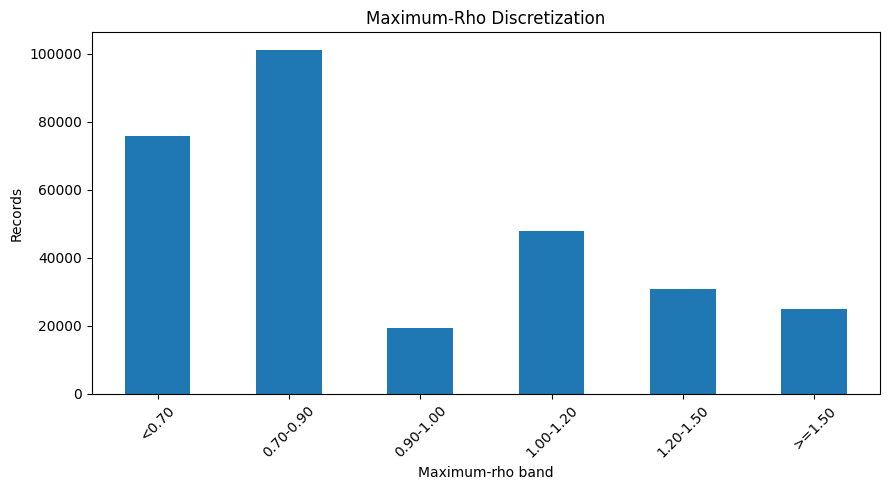

In [28]:
# EDA 25: FEATURE BINNING AND DISCRETIZATION
binned = df.copy()
binned["max_rho_band"] = pd.cut(
    binned["max_rho"],
    bins=[-np.inf, 0.70, 0.90, 1.00, 1.20, 1.50, np.inf],
    labels=["<0.70", "0.70-0.90", "0.90-1.00", "1.00-1.20", "1.20-1.50", ">=1.50"],
    right=False,
)
rho_band_table = pd.crosstab(binned["max_rho_band"], binned["label"], margins=True)
store_table("25_rho_band_by_label", rho_band_table)

plot_bar(
    binned["max_rho_band"].value_counts().sort_index(),
    "Maximum-Rho Discretization",
    "Maximum-rho band",
    "Records",
    rotation=45,
)


In [29]:
# EDA 26: POLYNOMIAL FEATURE-TRANSFORMATION ANALYSIS
from sklearn.preprocessing import PolynomialFeatures

poly_source = ["max_rho", "mean_rho", "total_load", "total_gen", "connected_fraction"]
sample = stratified_sample(df, min(5000, len(df)))
poly = PolynomialFeatures(degree=2, include_bias=False)
transformed = poly.fit_transform(sample[poly_source].fillna(0.0))
poly_names = poly.get_feature_names_out(poly_source)

poly_summary = pd.DataFrame({
    "original_feature_count": [len(poly_source)],
    "transformed_feature_count": [len(poly_names)],
    "generated_features": [", ".join(poly_names)],
})
store_table("26_polynomial_feature_summary", poly_summary)


,original_feature_count,transformed_feature_count,generated_features
0,5,20,"max_rho, mean_rho, total_load, total_gen, conn..."


,original_feature_count,transformed_feature_count,generated_features
0,5,20,"max_rho, mean_rho, total_load, total_gen, conn..."


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.497169,0.497169
1,2,0.278356,0.775525
2,3,0.093861,0.869386
3,4,0.075004,0.944389
4,5,0.025693,0.970082
5,6,0.011772,0.981854
6,7,0.008037,0.989891
7,8,0.004218,0.994109
8,9,0.003998,0.998107
9,10,0.001169,0.999276


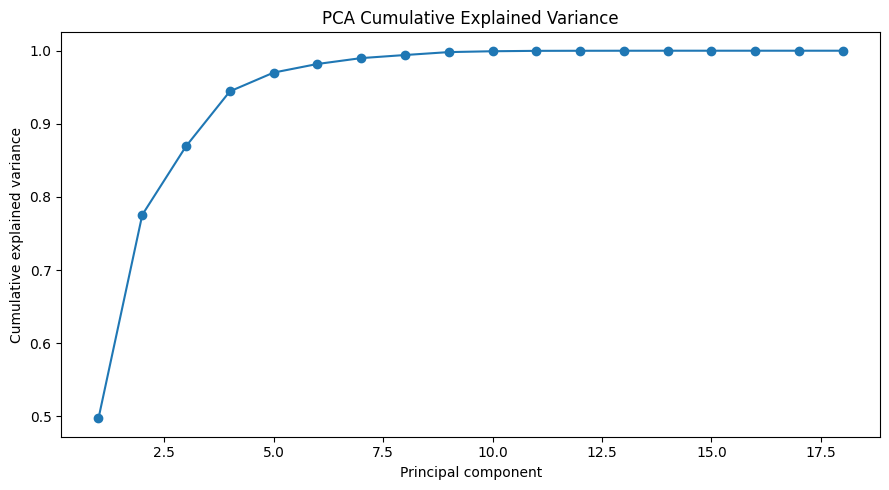

In [30]:
# EDA 27: PCA DIMENSIONALITY-REDUCTION ANALYSIS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sample = stratified_sample(df, min(STAT_SAMPLE_SIZE, len(df)))
X_scaled = StandardScaler().fit_transform(sample[MODEL_FEATURES_FULL].fillna(0.0))
pca = PCA().fit(X_scaled)

pca_table = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})
store_table("27_pca_variance", pca_table.round(6))

plot_line(
    pca_table["component"],
    pca_table["cumulative_explained_variance"],
    "PCA Cumulative Explained Variance",
    "Principal component",
    "Cumulative explained variance",
)


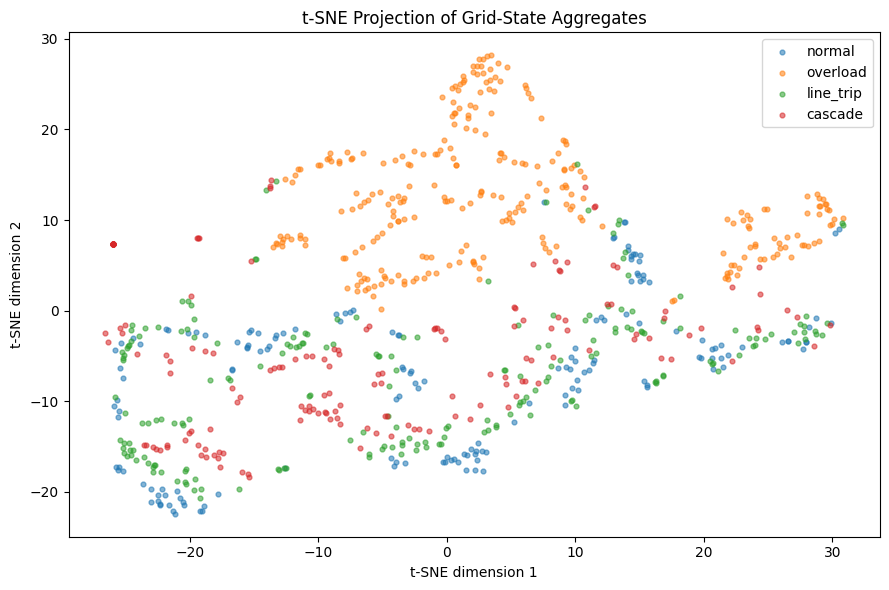

In [31]:
# EDA 28: T-SNE MANIFOLD VISUALIZATION
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sample = stratified_sample(df, min(800, EXPENSIVE_SAMPLE_SIZE, len(df)))
X_scaled = StandardScaler().fit_transform(sample[MODEL_FEATURES_FULL].fillna(0.0))
embedding = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    perplexity=25,
    max_iter=400,
).fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for label in LABEL_ORDER:
    mask = sample["label"].astype(str).to_numpy() == label
    plt.scatter(embedding[mask, 0], embedding[mask, 1], s=12, alpha=0.55, label=label)
plt.title("t-SNE Projection of Grid-State Aggregates")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.tight_layout()
plt.show()


,feature,mutual_information
13,mean_v_or,0.991880
14,mean_v_ex,0.905059
15,connected_lines,0.798281
17,connected_fraction,0.792818
16,disconnected_lines,0.790398
3,rho_range,0.681822
0,max_rho,0.675489
5,rho_above_100_pct,0.641263
4,rho_above_90_pct,0.492466
2,std_rho,0.443621


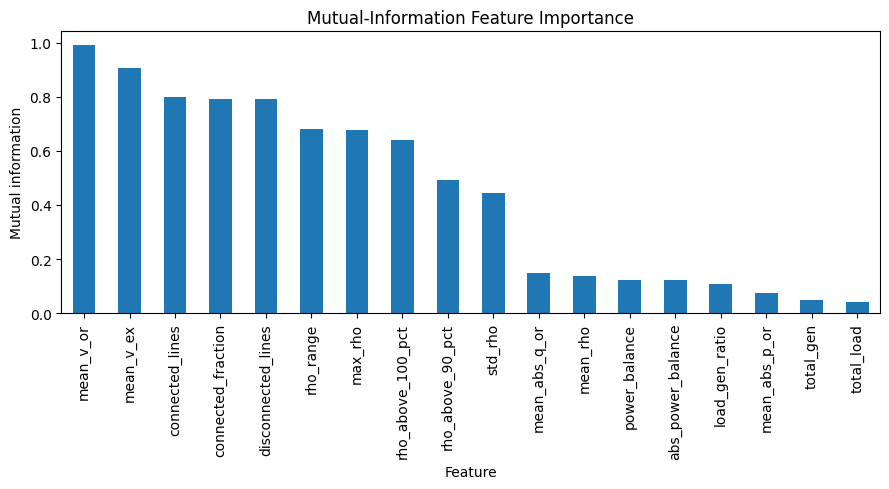

In [32]:
# EDA 29: MUTUAL-INFORMATION FEATURE IMPORTANCE
from sklearn.feature_selection import mutual_info_classif

sample, X, y = model_frame(MODEL_FEATURES_FULL, n=MODEL_SAMPLE_SIZE)
mi_values = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({
    "feature": MODEL_FEATURES_FULL,
    "mutual_information": mi_values,
}).sort_values("mutual_information", ascending=False)
store_table("29_mutual_information", mi_table)

plot_bar(
    mi_table.set_index("feature")["mutual_information"],
    "Mutual-Information Feature Importance",
    "Feature",
    "Mutual information",
    rotation=90,
)


,feature,importance
0,max_rho,0.135412
17,connected_fraction,0.126233
5,rho_above_100_pct,0.124278
15,connected_lines,0.119861
14,mean_v_ex,0.115845
16,disconnected_lines,0.108024
13,mean_v_or,0.095703
3,rho_range,0.092572
4,rho_above_90_pct,0.059575
2,std_rho,0.015822


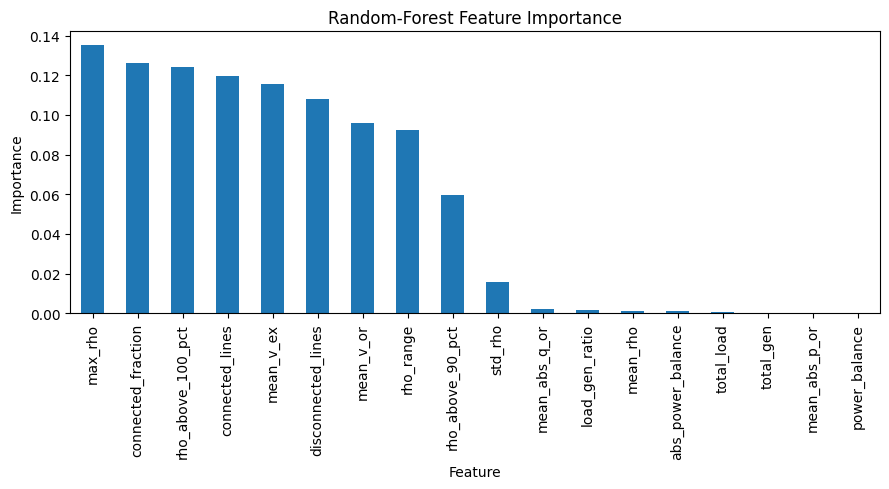

In [33]:
# EDA 30: RANDOM-FOREST FEATURE IMPORTANCE
sample, X, y = model_frame(MODEL_FEATURES_FULL, n=MODEL_SAMPLE_SIZE)
rf_importance_model = RandomForestClassifier(
    n_estimators=180,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_importance_model.fit(X, y)

rf_importance_table = pd.DataFrame({
    "feature": MODEL_FEATURES_FULL,
    "importance": rf_importance_model.feature_importances_,
}).sort_values("importance", ascending=False)
store_table("30_random_forest_importance", rf_importance_table)

plot_bar(
    rf_importance_table.set_index("feature")["importance"],
    "Random-Forest Feature Importance",
    "Feature",
    "Importance",
    rotation=90,
)


,feature,correlation_with_encoded_label,absolute_correlation
0,max_rho,-0.261377,0.261377
17,connected_fraction,-0.256925,0.256925
16,disconnected_lines,0.256925,0.256925
15,connected_lines,-0.256925,0.256925
14,mean_v_ex,-0.246165,0.246165
13,mean_v_or,-0.238404,0.238404
3,rho_range,-0.233305,0.233305
1,mean_rho,-0.227748,0.227748
12,mean_abs_q_or,-0.204322,0.204322
5,rho_above_100_pct,-0.191488,0.191488


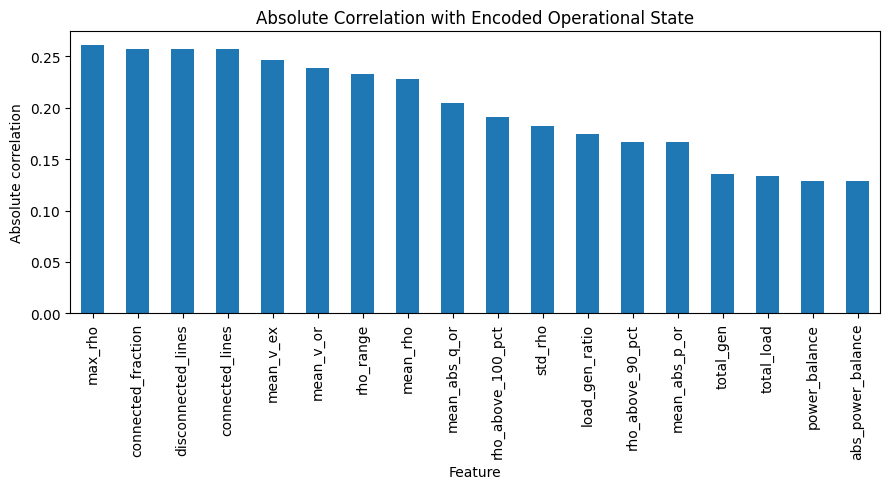

In [34]:
# EDA 31: CORRELATION-BASED FEATURE-IMPORTANCE ANALYSIS
encoded_label = df["label"].astype(str).map(LABEL_TO_INT).astype(float)
corr_rows = []
for feature in MODEL_FEATURES_FULL:
    value = float(pd.Series(df[feature]).corr(encoded_label))
    corr_rows.append({
        "feature": feature,
        "correlation_with_encoded_label": value,
        "absolute_correlation": abs(value),
    })

label_corr_table = pd.DataFrame(corr_rows).sort_values("absolute_correlation", ascending=False)
store_table("31_label_correlation_importance", label_corr_table)
plot_bar(
    label_corr_table.set_index("feature")["absolute_correlation"],
    "Absolute Correlation with Encoded Operational State",
    "Feature",
    "Absolute correlation",
    rotation=90,
)


## **F. Dataset Imbalance, Clustering, Explainability, and Outliers**


In [35]:
# EDA 32: CLASS-IMBALANCE ANALYSIS
counts = df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
largest = int(counts.max())
smallest = int(counts.min())
imbalance_table = pd.DataFrame({
    "records": counts,
    "percentage": (100 * counts / counts.sum()).round(4),
    "inverse_frequency_weight": (counts.sum() / (len(counts) * counts)).round(6),
    "sqrt_inverse_frequency_weight": np.sqrt(counts.sum() / (len(counts) * counts)).round(6),
})
store_table("32_class_imbalance", imbalance_table)

print(f"Largest-to-smallest class ratio: {largest / max(smallest, 1):.4f}")


,records,percentage,inverse_frequency_weight,sqrt_inverse_frequency_weight
label,,,,
normal,61444,20.4813,1.220624,1.104818
overload,103556,34.5187,0.724246,0.851026
line_trip,75000,25.0000,1.000000,1.000000
cascade,60000,20.0000,1.250000,1.118034


Largest-to-smallest class ratio: 1.7259


In [36]:
# EDA 33: K-MEANS CLUSTERING ANALYSIS
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sample = stratified_sample(df, min(10_000, len(df)))
X_scaled = StandardScaler().fit_transform(sample[MODEL_FEATURES_FULL].fillna(0.0))
kmeans = KMeans(n_clusters=len(LABEL_ORDER), random_state=RANDOM_STATE, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

cluster_table = pd.crosstab(
    pd.Series(clusters, name="cluster"),
    sample["label"].astype(str).reset_index(drop=True),
)
store_table("33_kmeans_cluster_by_label", cluster_table)

cluster_summary = pd.DataFrame({
    "metric": ["adjusted_rand_index", "silhouette_score"],
    "value": [
        adjusted_rand_score(sample["label"].astype(str), clusters),
        silhouette_score(X_scaled, clusters, sample_size=min(5000, len(sample)), random_state=RANDOM_STATE),
    ],
})
store_table("33_kmeans_summary", cluster_summary)


label,cascade,line_trip,normal,overload
cluster,,,,
0,519,738,537,2089
1,142,0,0,0
2,1,0,0,637
3,1338,1762,1511,726


,metric,value
0,adjusted_rand_index,0.084733
1,silhouette_score,0.337915


,metric,value
0,adjusted_rand_index,0.084733
1,silhouette_score,0.337915


,feature,mean_permutation_importance,std_permutation_importance
0,max_rho,0.007856,0.001080
5,rho_above_100_pct,0.000026,0.000052
1,mean_rho,0.000000,0.000000
2,std_rho,0.000000,0.000000
3,rho_range,0.000000,0.000000
4,rho_above_90_pct,0.000000,0.000000
6,total_load,0.000000,0.000000
7,total_gen,0.000000,0.000000
8,load_gen_ratio,0.000000,0.000000
9,power_balance,0.000000,0.000000


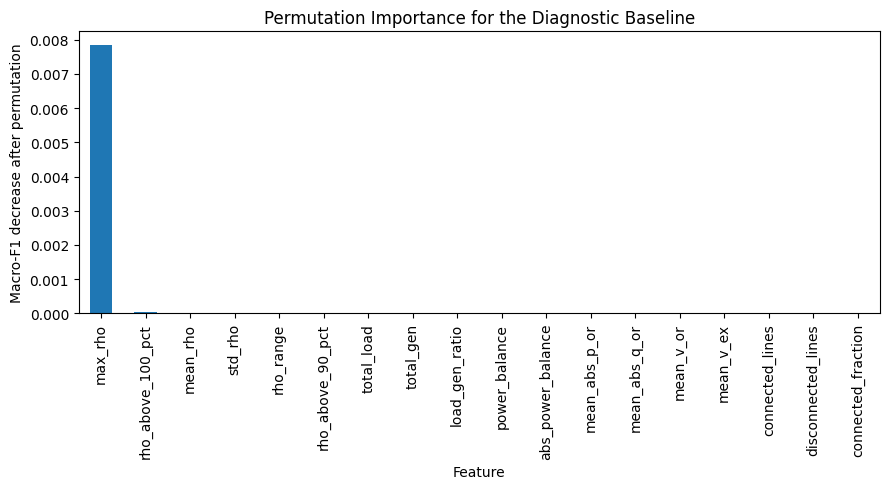

SHAP values computed successfully for 500 records.


In [37]:
# EDA 34: SHAP OR PERMUTATION-IMPORTANCE INTERPRETATION
from sklearn.inspection import permutation_importance

baseline = train_test_baseline(MODEL_FEATURES_FULL, n=min(MODEL_SAMPLE_SIZE, 30_000))
permutation = permutation_importance(
    baseline["model"],
    baseline["X_test"],
    baseline["y_test"],
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="f1_macro",
)
permutation_table = pd.DataFrame({
    "feature": MODEL_FEATURES_FULL,
    "mean_permutation_importance": permutation.importances_mean,
    "std_permutation_importance": permutation.importances_std,
}).sort_values("mean_permutation_importance", ascending=False)
store_table("34_permutation_importance", permutation_table)

plot_bar(
    permutation_table.set_index("feature")["mean_permutation_importance"],
    "Permutation Importance for the Diagnostic Baseline",
    "Feature",
    "Macro-F1 decrease after permutation",
    rotation=90,
)

try:
    import shap
    shap_sample = baseline["X_test"].sample(n=min(SHAP_SAMPLE_SIZE, len(baseline["X_test"])), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(baseline["model"])
    shap_values = explainer.shap_values(shap_sample)
    print("SHAP values computed successfully for", len(shap_sample), "records.")
except Exception as error:
    print("Optional SHAP rendering was skipped:", error)
    print("Permutation importance above remains available without the optional SHAP package.")


In [38]:
# EDA 35: OUTLIER DETECTION USING IQR, Z-SCORE, AND MAHALANOBIS DISTANCE
from scipy.stats import chi2, zscore

outlier_features = ["max_rho", "mean_rho", "total_load", "total_gen", "mean_abs_p_or", "mean_abs_q_or"]
sample = stratified_sample(df, min(STAT_SAMPLE_SIZE, len(df)))
X = sample[outlier_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)

q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
iqr = q3 - q1
iqr_mask = ((X < (q1 - 1.5 * iqr)) | (X > (q3 + 1.5 * iqr))).any(axis=1)

z_values = np.abs(zscore(X, nan_policy="omit"))
z_mask = np.any(z_values > 3.0, axis=1)

covariance = np.cov(X.to_numpy(), rowvar=False)
inverse_covariance = np.linalg.pinv(covariance)
centered = X.to_numpy() - X.to_numpy().mean(axis=0)
mahalanobis_squared = np.einsum("ij,jk,ik->i", centered, inverse_covariance, centered)
mahalanobis_threshold = chi2.ppf(0.997, df=X.shape[1])
mahalanobis_mask = mahalanobis_squared > mahalanobis_threshold

outlier_summary = pd.DataFrame({
    "method": ["IQR", "absolute z-score > 3", "Mahalanobis distance"],
    "outlier_records": [int(iqr_mask.sum()), int(z_mask.sum()), int(mahalanobis_mask.sum())],
    "outlier_percentage": [
        100 * float(iqr_mask.mean()),
        100 * float(z_mask.mean()),
        100 * float(mahalanobis_mask.mean()),
    ],
})
store_table("35_outlier_summary", outlier_summary.round(5))


,method,outlier_records,outlier_percentage
0,IQR,3660,18.30
1,absolute z-score > 3,924,4.62
2,Mahalanobis distance,1064,5.32


,method,outlier_records,outlier_percentage
0,IQR,3660,18.30
1,absolute z-score > 3,924,4.62
2,Mahalanobis distance,1064,5.32


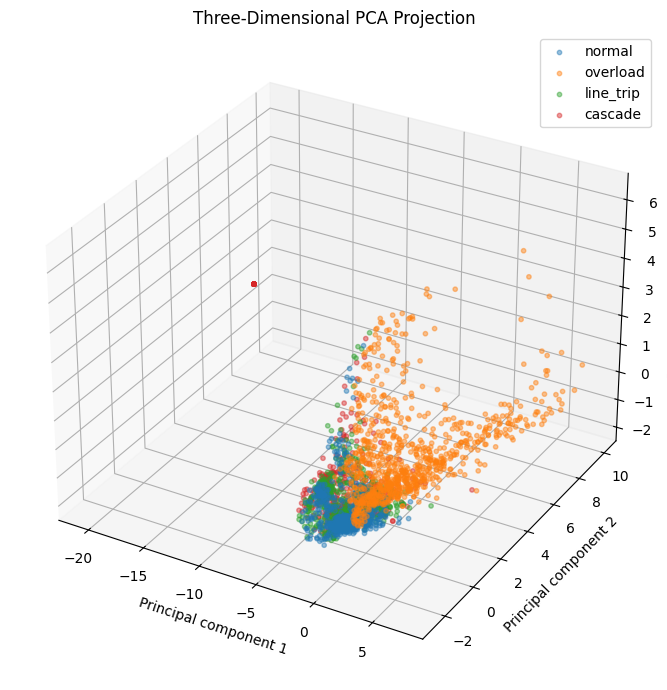

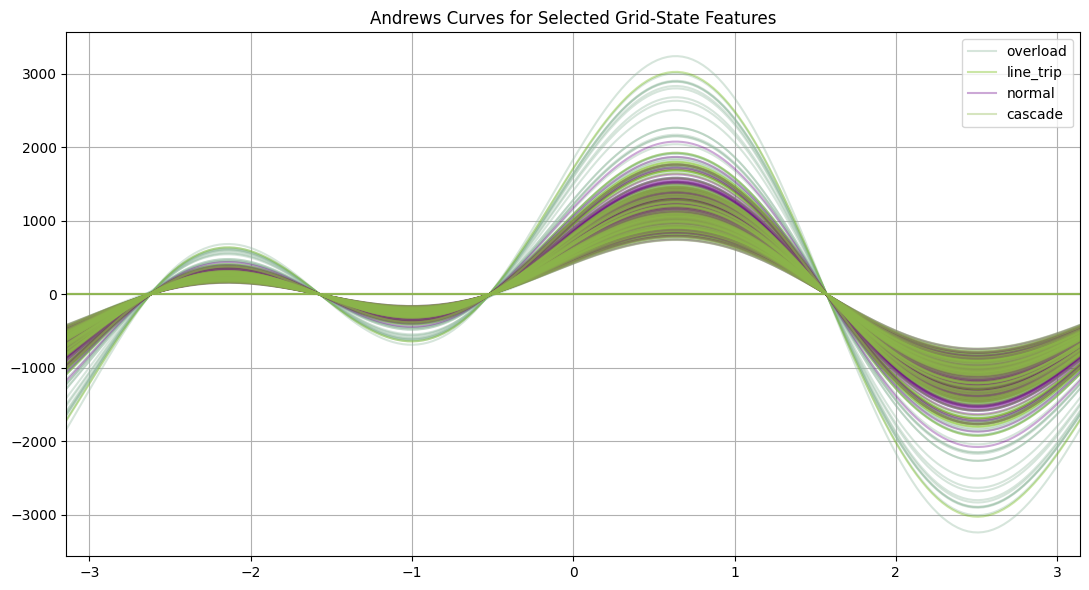

In [39]:
# EDA 36: THREE-DIMENSIONAL PCA AND ANDREWS-CURVE ANALYSIS
from pandas.plotting import andrews_curves
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sample = stratified_sample(df, min(2500, len(df)))
X_scaled = StandardScaler().fit_transform(sample[MODEL_FEATURES_FULL].fillna(0.0))
projection = PCA(n_components=3).fit_transform(X_scaled)

figure = plt.figure(figsize=(9, 7))
axis = figure.add_subplot(111, projection="3d")
for label in LABEL_ORDER:
    mask = sample["label"].astype(str).to_numpy() == label
    axis.scatter(projection[mask, 0], projection[mask, 1], projection[mask, 2], s=10, alpha=0.45, label=label)
axis.set_title("Three-Dimensional PCA Projection")
axis.set_xlabel("Principal component 1")
axis.set_ylabel("Principal component 2")
axis.set_zlabel("Principal component 3")
axis.legend()
plt.tight_layout()
plt.show()

andrews_sample = stratified_sample(df, min(500, len(df)))
plt.figure(figsize=(11, 6))
andrews_curves(
    andrews_sample[["label", "max_rho", "mean_rho", "total_load", "total_gen", "connected_fraction"]],
    "label",
    alpha=0.35,
)
plt.title("Andrews Curves for Selected Grid-State Features")
plt.tight_layout()
plt.show()


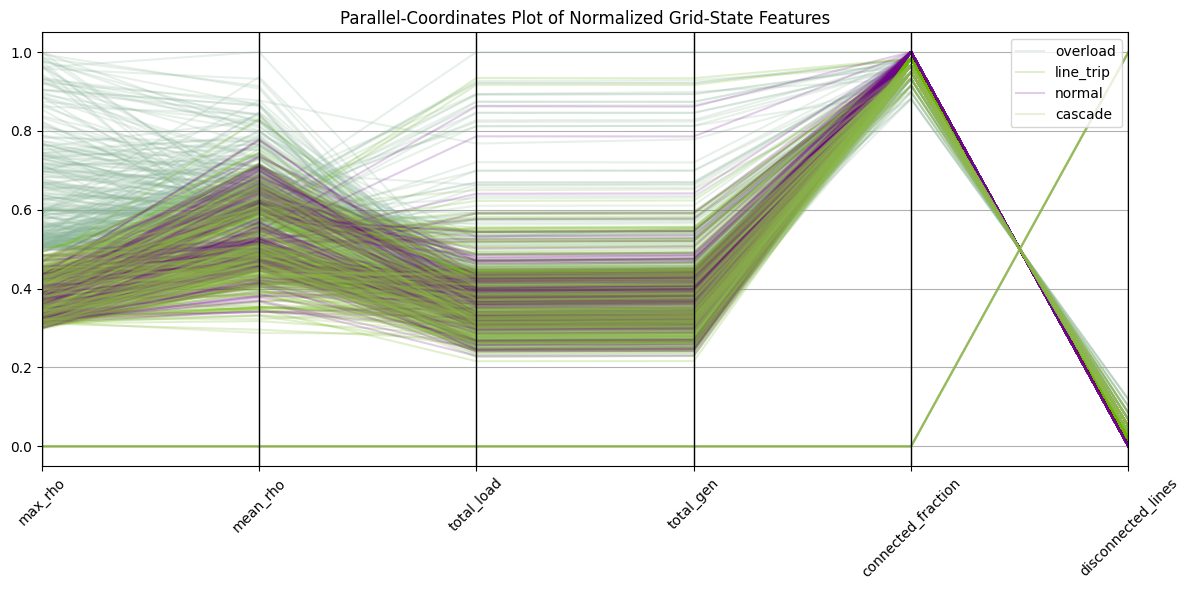

In [40]:
# EDA 37: PARALLEL-COORDINATES PLOT
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

sample = stratified_sample(df, min(800, len(df)))
parallel_features = ["max_rho", "mean_rho", "total_load", "total_gen", "connected_fraction", "disconnected_lines"]
scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(sample[parallel_features]),
    columns=parallel_features,
)
scaled["label"] = sample["label"].astype(str).reset_index(drop=True)

plt.figure(figsize=(12, 6))
parallel_coordinates(scaled, "label", alpha=0.20)
plt.title("Parallel-Coordinates Plot of Normalized Grid-State Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **G. Diagnostic Baseline Modelling**


,training_records,training_macro_f1,validation_macro_f1,validation_macro_f1_std
0,3000,1.0,0.128308,0.000000
1,6399,1.0,0.128308,0.000000
2,9800,1.0,0.382158,0.004356
3,13200,1.0,0.677508,0.000428
4,16600,1.0,0.998549,0.000690
5,20000,1.0,0.998601,0.000673


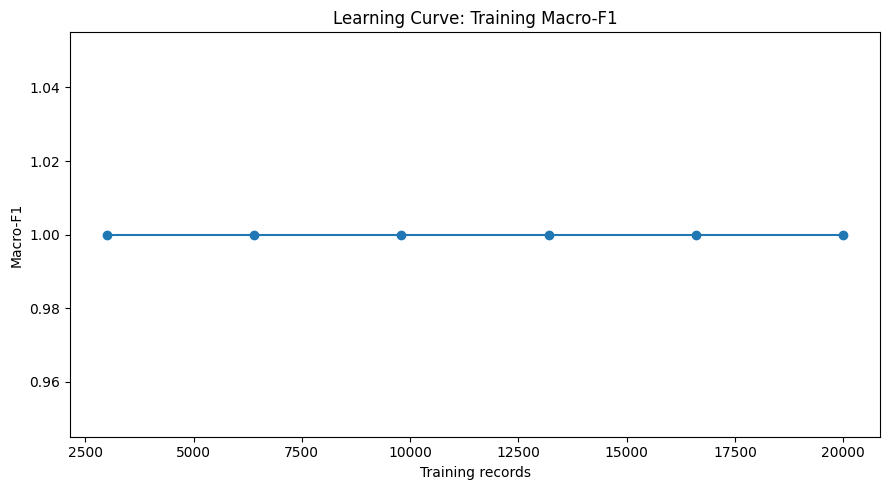

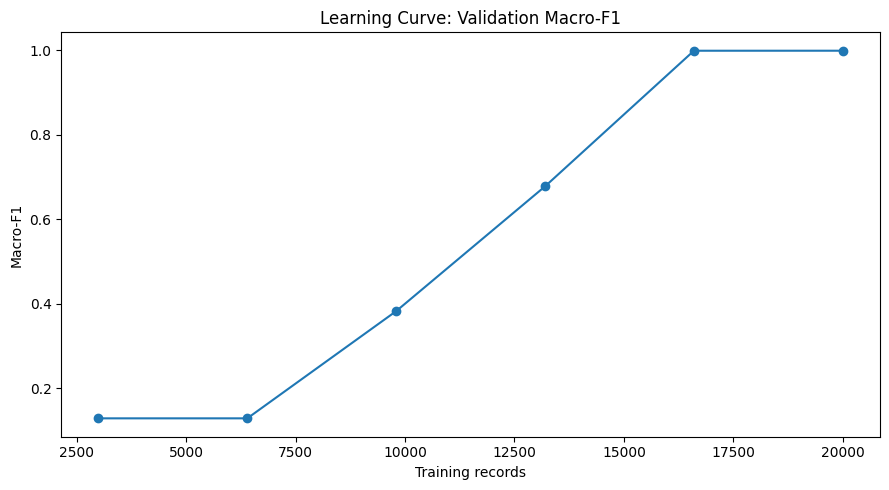

In [41]:
# EDA 38: BASIC LEARNING-CURVE ANALYSIS
from sklearn.model_selection import learning_curve

sample, X, y = model_frame(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 30_000))
curve_model = RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1)

train_sizes, train_scores, validation_scores = learning_curve(
    curve_model,
    X,
    y,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.15, 1.0, 6),
    n_jobs=-1,
)

learning_curve_table = pd.DataFrame({
    "training_records": train_sizes,
    "training_macro_f1": train_scores.mean(axis=1),
    "validation_macro_f1": validation_scores.mean(axis=1),
    "validation_macro_f1_std": validation_scores.std(axis=1),
})
store_table("38_learning_curve", learning_curve_table.round(6))

plot_line(
    learning_curve_table["training_records"],
    learning_curve_table["training_macro_f1"],
    "Learning Curve: Training Macro-F1",
    "Training records",
    "Macro-F1",
)
plot_line(
    learning_curve_table["training_records"],
    learning_curve_table["validation_macro_f1"],
    "Learning Curve: Validation Macro-F1",
    "Training records",
    "Macro-F1",
)


,normal,overload,line_trip,cascade
normal,2038,10,0,0
overload,2,3450,0,0
line_trip,0,0,2497,3
cascade,0,1,0,1999


,precision,recall,f1-score,support
normal,0.99902,0.99512,0.99706,2048.0000
overload,0.99682,0.99942,0.99812,3452.0000
line_trip,1.00000,0.99880,0.99940,2500.0000
cascade,0.99850,0.99950,0.99900,2000.0000
accuracy,0.99840,0.99840,0.99840,0.9984
macro avg,0.99859,0.99821,0.99840,10000.0000
weighted avg,0.99840,0.99840,0.99840,10000.0000


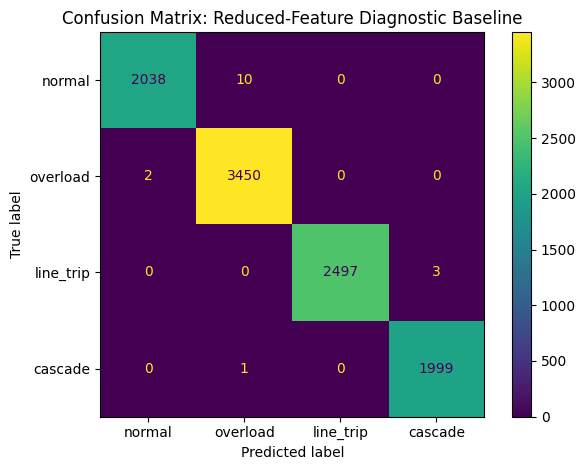

In [42]:
# EDA 39: CONFUSION-MATRIX ANALYSIS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=MODEL_SAMPLE_SIZE)
matrix = confusion_matrix(baseline["y_test"], baseline["pred"], labels=LABEL_ORDER)
matrix_table = pd.DataFrame(matrix, index=LABEL_ORDER, columns=LABEL_ORDER)
store_table("39_confusion_matrix", matrix_table)

display(pd.DataFrame(classification_report(
    baseline["y_test"],
    baseline["pred"],
    labels=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)).T.round(5))

display_object = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=LABEL_ORDER)
display_object.plot(values_format="d")
plt.title("Confusion Matrix: Reduced-Feature Diagnostic Baseline")
plt.tight_layout()
plt.show()


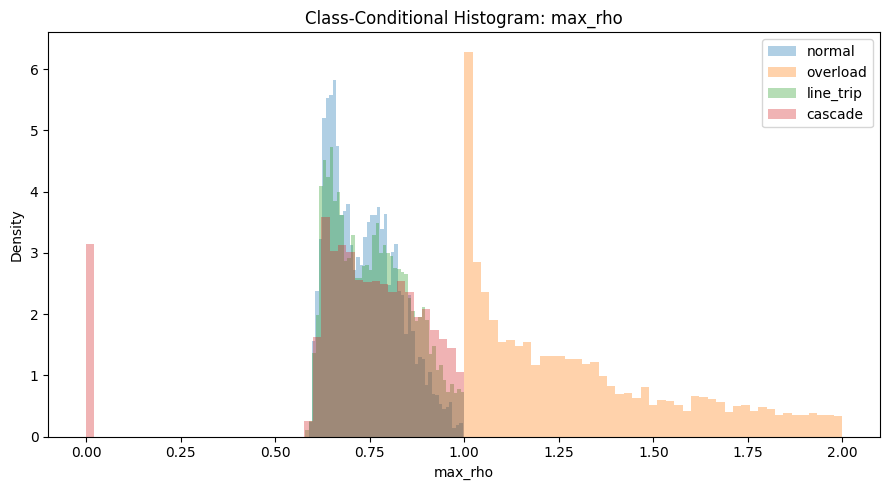

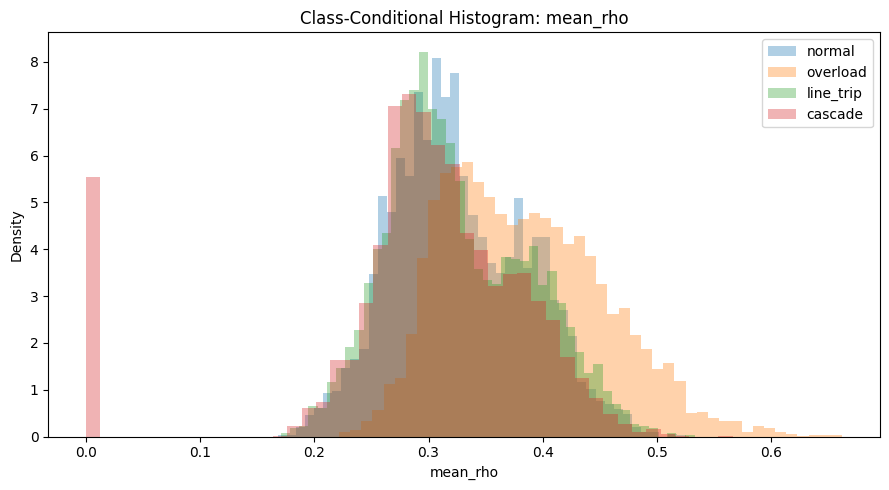

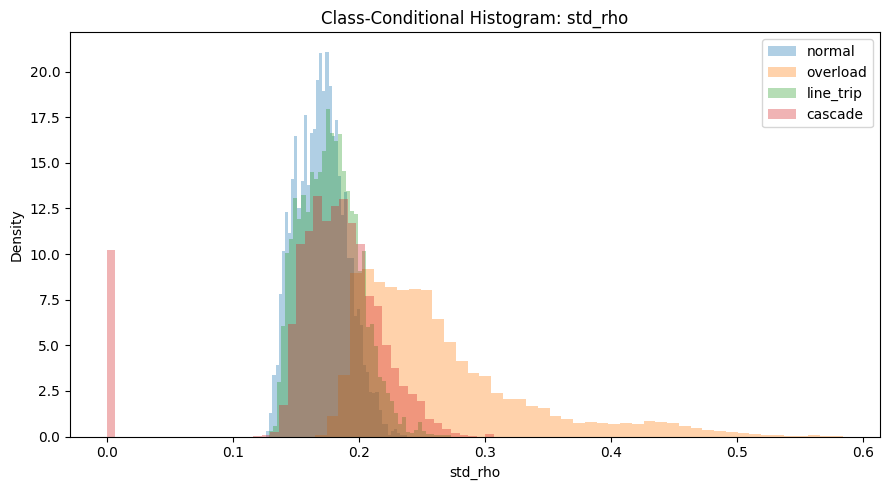

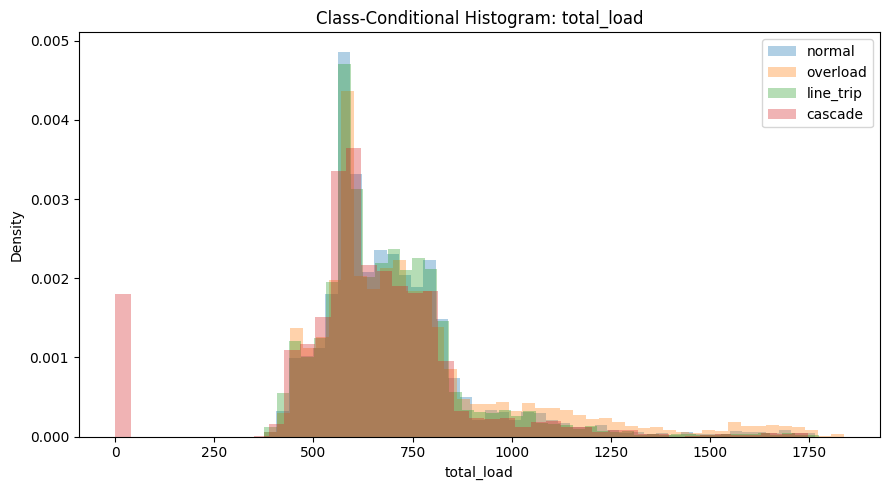

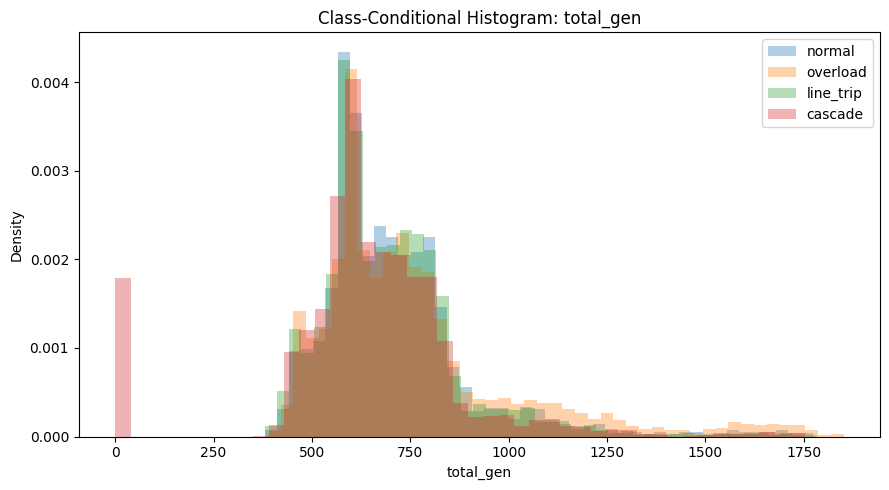

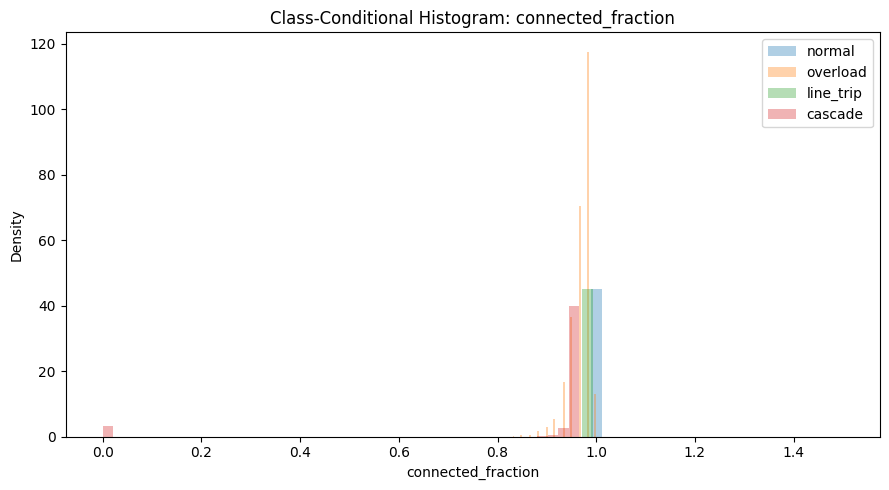

In [43]:
# EDA 40: ENHANCED HISTOGRAM ANALYSIS
histogram_features = ["max_rho", "mean_rho", "std_rho", "total_load", "total_gen", "connected_fraction"]
sample = stratified_sample(df, min(STAT_SAMPLE_SIZE, len(df)))

for feature in histogram_features:
    plt.figure(figsize=(9, 5))
    for label in LABEL_ORDER:
        values = sample.loc[sample["label"].astype(str) == label, feature]
        plt.hist(values, bins=45, alpha=0.35, density=True, label=label)
    plt.title(f"Class-Conditional Histogram: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


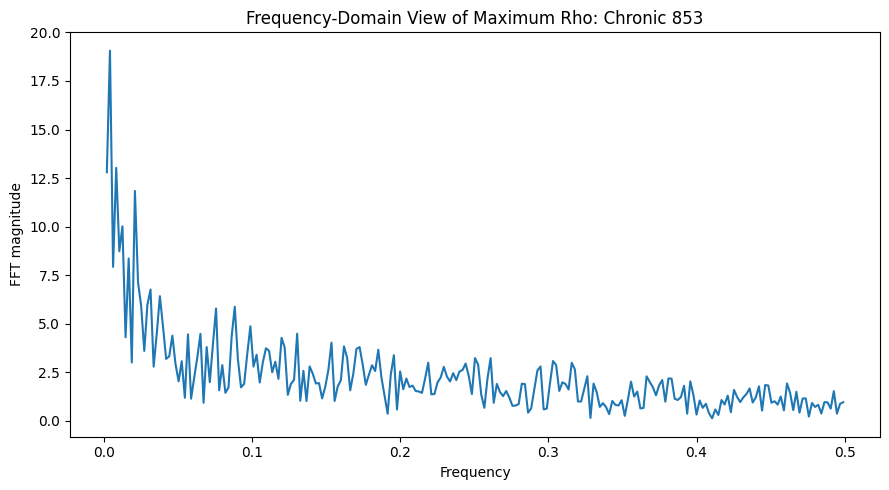

,chronic_id,ordered_records,dominant_nonzero_frequency
0,853,475,0.004211


,chronic_id,ordered_records,dominant_nonzero_frequency
0,853,475,0.004211


In [44]:
# EDA 41: FREQUENCY-DOMAIN ANALYSIS OF CHRONIC-ORDERED GRID STRESS
# The largest available chronic is used so that the signal preserves temporal order.
largest_chronic = int(df["chronic_id"].value_counts().index[0])
series = (
    df[df["chronic_id"] == largest_chronic]
      .sort_values("timestep")["max_rho"]
      .to_numpy(dtype=float)
)
series = series - np.mean(series)
frequency = np.fft.rfftfreq(len(series), d=1.0)
magnitude = np.abs(np.fft.rfft(series))

plt.figure(figsize=(9, 5))
plt.plot(frequency[1:], magnitude[1:])
plt.title(f"Frequency-Domain View of Maximum Rho: Chronic {largest_chronic}")
plt.xlabel("Frequency")
plt.ylabel("FFT magnitude")
plt.tight_layout()
plt.show()

frequency_summary = pd.DataFrame({
    "chronic_id": [largest_chronic],
    "ordered_records": [len(series)],
    "dominant_nonzero_frequency": [float(frequency[1:][np.argmax(magnitude[1:])]) if len(frequency) > 1 else np.nan],
})
store_table("41_frequency_domain_summary", frequency_summary)


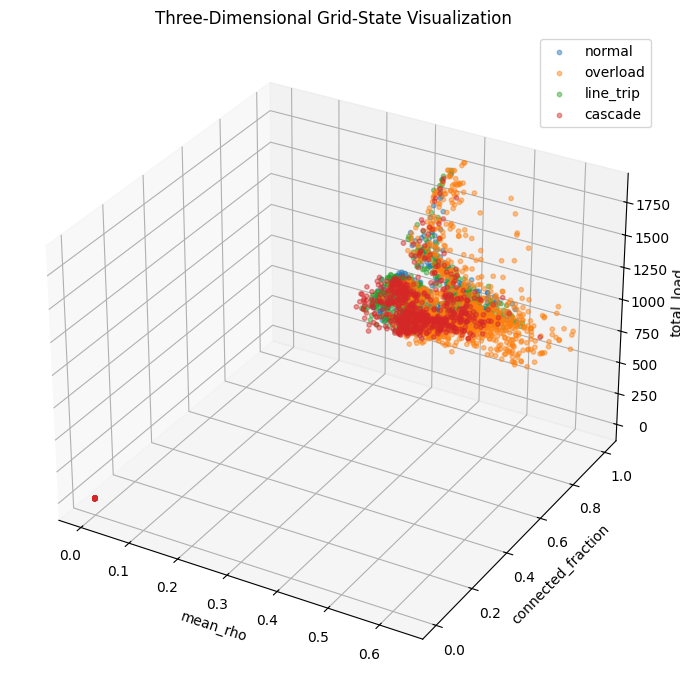

In [45]:
# EDA 42: THREE-DIMENSIONAL RAW-FEATURE VISUALIZATION
sample = stratified_sample(df, min(3500, len(df)))

figure = plt.figure(figsize=(9, 7))
axis = figure.add_subplot(111, projection="3d")
for label in LABEL_ORDER:
    group = sample[sample["label"].astype(str) == label]
    axis.scatter(group["mean_rho"], group["connected_fraction"], group["total_load"], s=10, alpha=0.45, label=label)
axis.set_title("Three-Dimensional Grid-State Visualization")
axis.set_xlabel("mean_rho")
axis.set_ylabel("connected_fraction")
axis.set_zlabel("total_load")
axis.legend()
plt.tight_layout()
plt.show()


,metric,training_records,training_score,validation_score,validation_score_std
0,accuracy,3000,1.0,0.345200,0.000000
1,accuracy,6399,1.0,0.345200,0.000000
2,accuracy,9800,1.0,0.595133,0.000094
3,accuracy,13200,1.0,0.800000,0.000000
4,accuracy,16600,1.0,1.000000,0.000000
5,accuracy,20000,1.0,1.000000,0.000000
6,f1_macro,3000,1.0,0.128308,0.000000
7,f1_macro,6399,1.0,0.128308,0.000000
8,f1_macro,9800,1.0,0.388094,0.000082
9,f1_macro,13200,1.0,0.678571,0.000000


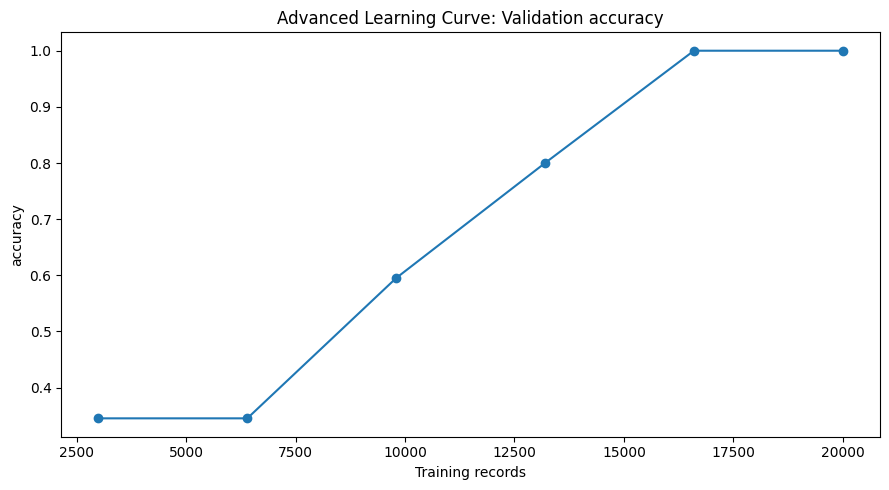

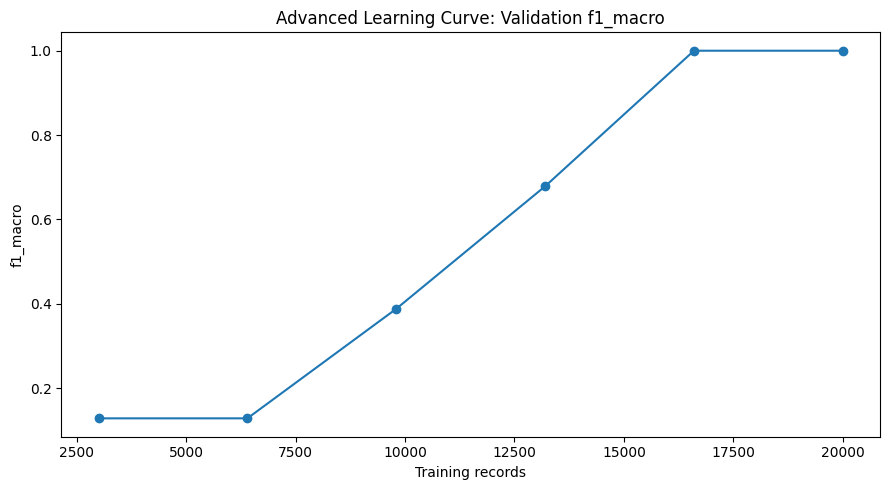

In [46]:
# EDA 43: ADVANCED LEARNING-CURVE ANALYSIS WITH ACCURACY AND MACRO-F1
from sklearn.model_selection import learning_curve

sample, X, y = model_frame(MODEL_FEATURES_FULL, n=min(MODEL_SAMPLE_SIZE, 30_000))
curve_model = RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1)
sizes = np.linspace(0.15, 1.0, 6)

rows = []
for metric in ["accuracy", "f1_macro"]:
    train_sizes, train_scores, validation_scores = learning_curve(
        curve_model, X, y, cv=3, scoring=metric, train_sizes=sizes, n_jobs=-1
    )
    for size, training, validation in zip(train_sizes, train_scores, validation_scores):
        rows.append({
            "metric": metric,
            "training_records": int(size),
            "training_score": float(training.mean()),
            "validation_score": float(validation.mean()),
            "validation_score_std": float(validation.std()),
        })

advanced_curve_table = pd.DataFrame(rows)
store_table("43_advanced_learning_curve", advanced_curve_table.round(6))

for metric in ["accuracy", "f1_macro"]:
    subset = advanced_curve_table[advanced_curve_table["metric"] == metric]
    plot_line(
        subset["training_records"],
        subset["validation_score"],
        f"Advanced Learning Curve: Validation {metric}",
        "Training records",
        metric,
    )


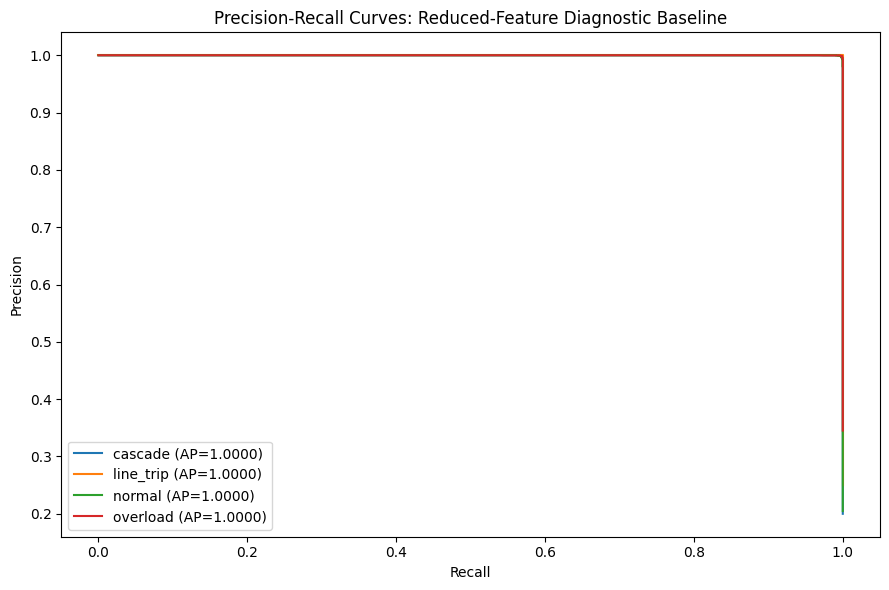

,class,average_precision
0,cascade,0.999999
1,line_trip,1.000000
2,normal,0.999975
3,overload,0.999984


,class,average_precision
0,cascade,0.999999
1,line_trip,1.000000
2,normal,0.999975
3,overload,0.999984


In [47]:
# EDA 44: PRECISION-RECALL CURVE ANALYSIS
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import label_binarize

baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=MODEL_SAMPLE_SIZE)
probabilities = baseline["model"].predict_proba(baseline["X_test"])
class_order = baseline["model"].classes_.tolist()
binary_y = label_binarize(baseline["y_test"], classes=class_order)

pr_rows = []
plt.figure(figsize=(9, 6))
for index, label in enumerate(class_order):
    precision, recall, _ = precision_recall_curve(binary_y[:, index], probabilities[:, index])
    average_precision = average_precision_score(binary_y[:, index], probabilities[:, index])
    pr_rows.append({"class": label, "average_precision": average_precision})
    plt.plot(recall, precision, label=f"{label} (AP={average_precision:.4f})")
plt.title("Precision-Recall Curves: Reduced-Feature Diagnostic Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

store_table("44_precision_recall_summary", pd.DataFrame(pr_rows))


In [48]:
# EDA 45: CROSS-VALIDATION FOLD ANALYSIS
from sklearn.model_selection import StratifiedKFold, cross_validate

sample, X, y = model_frame(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 30_000))
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

scores = cross_validate(
    model,
    X,
    y,
    cv=cross_validation,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro", "weighted_f1": "f1_weighted"},
    n_jobs=-1,
)

fold_table = pd.DataFrame({
    "fold": np.arange(1, len(scores["test_accuracy"]) + 1),
    "accuracy": scores["test_accuracy"],
    "macro_f1": scores["test_macro_f1"],
    "weighted_f1": scores["test_weighted_f1"],
})
store_table("45_cross_validation_folds", fold_table.round(6))


,fold,accuracy,macro_f1,weighted_f1
0,1,0.999000,0.998974,0.999000
1,2,0.999167,0.999139,0.999167
2,3,0.998667,0.998677,0.998666
3,4,0.998167,0.998113,0.998167
4,5,0.998500,0.998571,0.998500


,fold,accuracy,macro_f1,weighted_f1
0,1,0.999000,0.998974,0.999000
1,2,0.999167,0.999139,0.999167
2,3,0.998667,0.998677,0.998666
3,4,0.998167,0.998113,0.998167
4,5,0.998500,0.998571,0.998500


## **H. Temporal, Localization, Robustness, and Physics Audits**


next_label,normal,overload,line_trip,cascade
label,,,,
normal,0.596647,0.334937,0.043885,0.024531
overload,0.092022,0.847172,0.008201,0.052606
line_trip,0.032493,0.022707,0.906853,0.037947
cascade,0.019501,0.027523,0.045949,0.907027


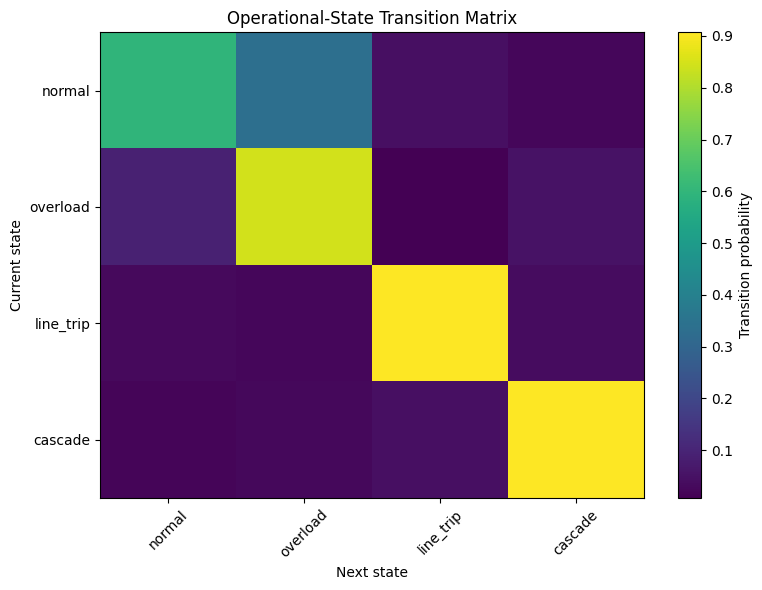

In [49]:
# EDA 46: FAULT-PROGRESSION AND STATE-TRANSITION ANALYSIS
ordered = df.sort_values(["chronic_id", "timestep", "record_index"]).copy()
ordered["next_label"] = ordered.groupby("chronic_id", observed=False)["label"].shift(-1)
transition_table = pd.crosstab(
    ordered["label"],
    ordered["next_label"],
    normalize="index",
).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0.0)
store_table("46_state_transition_matrix", transition_table.round(6))

plt.figure(figsize=(8, 6))
plt.imshow(transition_table.to_numpy(), aspect="auto")
plt.colorbar(label="Transition probability")
plt.xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=45)
plt.yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
plt.title("Operational-State Transition Matrix")
plt.xlabel("Next state")
plt.ylabel("Current state")
plt.tight_layout()
plt.show()


In [50]:
# EDA 47: FEATURE-TO-FAULT-LOCATION ASSOCIATION ANALYSIS
localized = df[df["fault_loc"] >= 0].copy()
if localized.empty:
    print("No localized fault rows are available.")
else:
    fault_location_correlations = (
        localized[MODEL_FEATURES_FULL + ["fault_loc"]]
        .corr(numeric_only=True)["fault_loc"]
        .drop("fault_loc")
        .to_frame("correlation_with_fault_loc")
    )
    fault_location_correlations["absolute_correlation"] = fault_location_correlations["correlation_with_fault_loc"].abs()
    fault_location_correlations = fault_location_correlations.sort_values("absolute_correlation", ascending=False)
    store_table("47_fault_location_correlations", fault_location_correlations)


,correlation_with_fault_loc,absolute_correlation
std_rho,0.360518,0.360518
mean_v_or,-0.349462,0.349462
rho_above_90_pct,0.329971,0.329971
mean_v_ex,-0.293209,0.293209
rho_above_100_pct,0.290075,0.290075
mean_rho,0.283570,0.283570
rho_range,0.262487,0.262487
max_rho,0.261782,0.261782
connected_lines,-0.202234,0.202234
disconnected_lines,0.202234,0.202234


In [51]:
# EDA 48: RANDOM-SPLIT STRATIFICATION ANALYSIS
from sklearn.model_selection import train_test_split

train_frame, test_frame = train_test_split(
    df[["label"]],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)
stratification_table = pd.DataFrame({
    "full_dataset_pct": (100 * df["label"].value_counts(normalize=True).reindex(LABEL_ORDER)).round(5),
    "train_pct": (100 * train_frame["label"].value_counts(normalize=True).reindex(LABEL_ORDER)).round(5),
    "test_pct": (100 * test_frame["label"].value_counts(normalize=True).reindex(LABEL_ORDER)).round(5),
})
store_table("48_stratification_analysis", stratification_table)


,full_dataset_pct,train_pct,test_pct
label,,,
normal,20.48133,20.48125,20.48167
overload,34.51867,34.51875,34.51833
line_trip,25.00000,25.00000,25.00000
cascade,20.00000,20.00000,20.00000


,full_dataset_pct,train_pct,test_pct
label,,,
normal,20.48133,20.48125,20.48167
overload,34.51867,34.51875,34.51833
line_trip,25.00000,25.00000,25.00000
cascade,20.00000,20.00000,20.00000


,noise_scale,macro_f1,prediction_change_rate,macro_f1_change_from_reference
0,0.00,0.999237,0.000000,0.000000
1,0.01,0.995787,0.003733,-0.003450
2,0.03,0.987407,0.012267,-0.011829
3,0.05,0.937881,0.058000,-0.061356
4,0.10,0.780189,0.200933,-0.219047


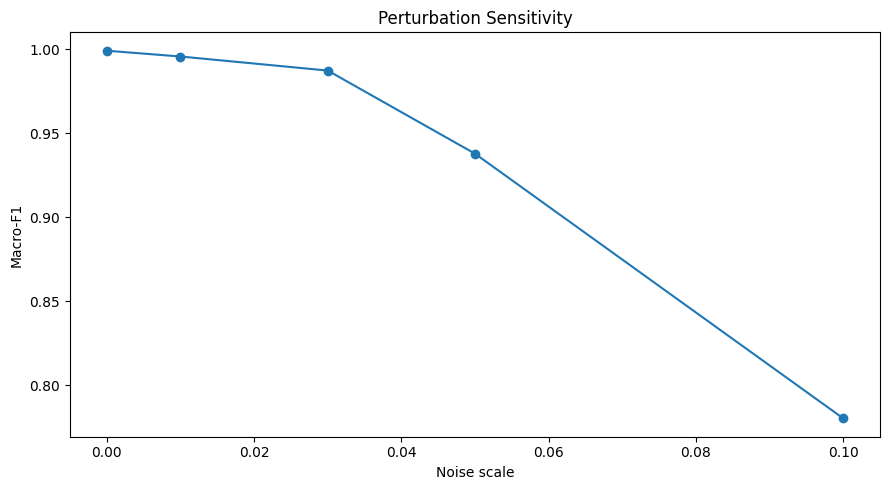

In [52]:
# EDA 49: INPUT-PERTURBATION SENSITIVITY ANALYSIS
baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 30_000))
X_test = baseline["X_test"].copy()
reference_prediction = baseline["model"].predict(X_test)
reference_macro_f1 = f1_score(baseline["y_test"], reference_prediction, average="macro")

rng = np.random.default_rng(RANDOM_STATE)
sensitivity_rows = []
for noise_scale in [0.00, 0.01, 0.03, 0.05, 0.10]:
    feature_scale = X_test.std(axis=0).replace(0.0, 1.0).to_numpy()
    noise = rng.normal(0.0, noise_scale, size=X_test.shape) * feature_scale
    perturbed = X_test.to_numpy() + noise
    prediction = baseline["model"].predict(perturbed)
    macro_f1 = f1_score(baseline["y_test"], prediction, average="macro")
    sensitivity_rows.append({
        "noise_scale": noise_scale,
        "macro_f1": macro_f1,
        "prediction_change_rate": float(np.mean(prediction != reference_prediction)),
        "macro_f1_change_from_reference": macro_f1 - reference_macro_f1,
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)
store_table("49_input_perturbation_sensitivity", sensitivity_table.round(6))
plot_line(sensitivity_table["noise_scale"], sensitivity_table["macro_f1"], "Perturbation Sensitivity", "Noise scale", "Macro-F1")


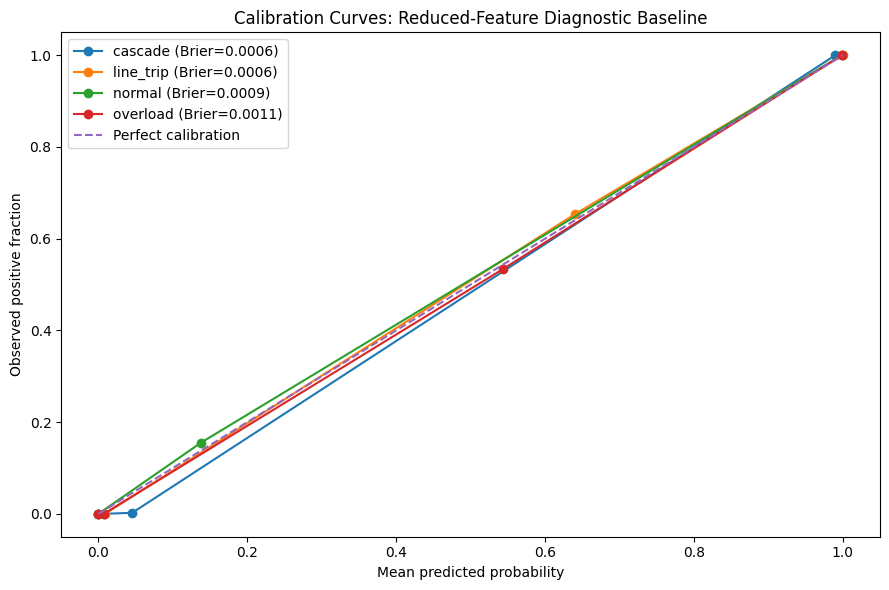

,class,brier_score
0,cascade,0.000560
1,line_trip,0.000643
2,normal,0.000936
3,overload,0.001136


,class,brier_score
0,cascade,0.000560
1,line_trip,0.000643
2,normal,0.000936
3,overload,0.001136


In [53]:
# EDA 50: PROBABILITY-CALIBRATION ANALYSIS
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=MODEL_SAMPLE_SIZE)
probabilities = baseline["model"].predict_proba(baseline["X_test"])
class_order = baseline["model"].classes_.tolist()
binary_y = label_binarize(baseline["y_test"], classes=class_order)

calibration_rows = []
plt.figure(figsize=(9, 6))
for index, label in enumerate(class_order):
    fraction_positive, mean_predicted = calibration_curve(
        binary_y[:, index], probabilities[:, index], n_bins=10, strategy="quantile"
    )
    brier = brier_score_loss(binary_y[:, index], probabilities[:, index])
    calibration_rows.append({"class": label, "brier_score": brier})
    plt.plot(mean_predicted, fraction_positive, marker="o", label=f"{label} (Brier={brier:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curves: Reduced-Feature Diagnostic Baseline")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive fraction")
plt.legend()
plt.tight_layout()
plt.show()

store_table("50_calibration_summary", pd.DataFrame(calibration_rows))


In [54]:
# EDA 51: PER-CLASS DETAILED STATISTICS
per_class_statistics = (
    df.groupby("label", observed=False)[MODEL_FEATURES_FULL]
      .agg(["mean", "median", "std", "min", "max"])
      .round(5)
)
store_table("51_per_class_statistics", per_class_statistics)


max_rho                                     mean_rho           \
              mean   median      std      min      max     mean   median   
label                                                                      
normal     0.73692  0.72684  0.08919  0.58288  0.99988  0.32609  0.31830   
overload   1.30335  1.22903  0.27327  1.00000  2.00000  0.38484  0.37772   
line_trip  0.75374  0.74386  0.10108  0.57165  1.00000  0.32270  0.31285   
cascade    0.71991  0.74915  0.22267  0.00000  0.99999  0.29628  0.30300   

                                      ... disconnected_lines                   \
               std      min      max  ...               mean median       std   
label                                 ...                                       
normal     0.05915  0.16797  0.53000  ...            0.00000    0.0   0.00000   
overload   0.06874  0.20390  0.72652  ...            1.88143    2.0   1.29274   
line_trip  0.06128  0.16836  0.53922  ...            1.00000    1.0   0.00000   
cascade    0.09879  0.00000  0.56632  ...            6.29040    2.0  14.39419   

                  connected_fraction                                      
          min max               mean   median      std      min      max  
label                                                                     
normal      0   0            1.00000  1.00000  0.00000  1.00000  1.00000  
overload    0  12            0.96811  0.96610  0.02191  0.79661  1.00000  
line_trip   1   1            0.98305  0.98305  0.00000  0.98305  0.98305  
cascade     2  59            0.89338  0.96610  0.24397  0.00000  0.96610  

[4 rows x 90 columns]

max_rho                                     mean_rho           \
              mean   median      std      min      max     mean   median   
label                                                                      
normal     0.73692  0.72684  0.08919  0.58288  0.99988  0.32609  0.31830   
overload   1.30335  1.22903  0.27327  1.00000  2.00000  0.38484  0.37772   
line_trip  0.75374  0.74386  0.10108  0.57165  1.00000  0.32270  0.31285   
cascade    0.71991  0.74915  0.22267  0.00000  0.99999  0.29628  0.30300   

                                      ... disconnected_lines                   \
               std      min      max  ...               mean median       std   
label                                 ...                                       
normal     0.05915  0.16797  0.53000  ...            0.00000    0.0   0.00000   
overload   0.06874  0.20390  0.72652  ...            1.88143    2.0   1.29274   
line_trip  0.06128  0.16836  0.53922  ...            1.00000    1.0   0.00000   
cascade    0.09879  0.00000  0.56632  ...            6.29040    2.0  14.39419   

                  connected_fraction                                      
          min max               mean   median      std      min      max  
label                                                                     
normal      0   0            1.00000  1.00000  0.00000  1.00000  1.00000  
overload    0  12            0.96811  0.96610  0.02191  0.79661  1.00000  
line_trip   1   1            0.98305  0.98305  0.00000  0.98305  0.98305  
cascade     2  59            0.89338  0.96610  0.24397  0.00000  0.96610  

[4 rows x 90 columns]

,rho_threshold,predicted_overload_records,precision,recall
0,0.80,166351,0.622515,1.000000
1,0.85,141541,0.731633,1.000000
2,0.90,123061,0.841501,1.000000
3,0.95,111074,0.932315,1.000000
4,1.00,103555,1.000000,0.999990
5,1.05,80762,1.000000,0.779887
6,1.10,70787,1.000000,0.683563
7,1.15,62829,1.000000,0.606715
8,1.20,55734,1.000000,0.538202


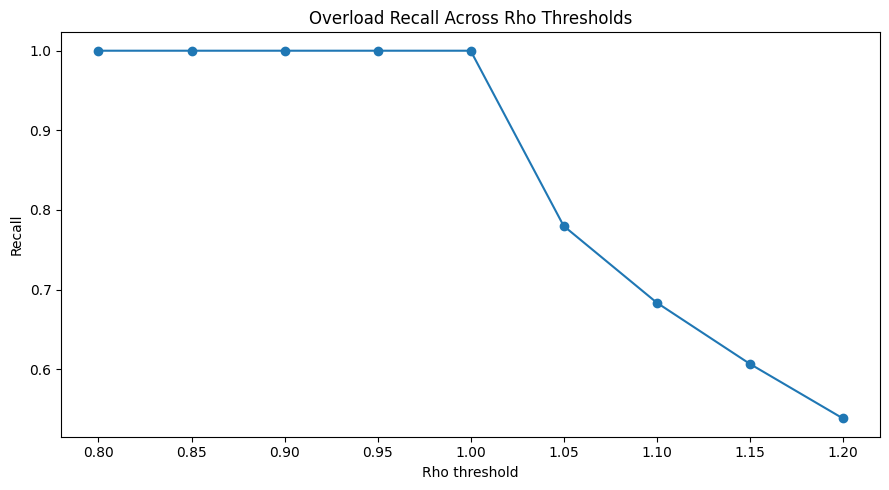

In [55]:
# EDA 52: RHO-THRESHOLD SENSITIVITY ANALYSIS
threshold_rows = []
for threshold in np.arange(0.80, 1.21, 0.05):
    predicted_overload = df["max_rho"] >= threshold
    actual_overload = df["label"].astype(str) == "overload"
    true_positive = int((predicted_overload & actual_overload).sum())
    false_positive = int((predicted_overload & ~actual_overload).sum())
    false_negative = int((~predicted_overload & actual_overload).sum())
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    threshold_rows.append({
        "rho_threshold": round(float(threshold), 2),
        "predicted_overload_records": int(predicted_overload.sum()),
        "precision": precision,
        "recall": recall,
    })

rho_threshold_table = pd.DataFrame(threshold_rows)
store_table("52_rho_threshold_sensitivity", rho_threshold_table.round(6))
plot_line(rho_threshold_table["rho_threshold"], rho_threshold_table["recall"], "Overload Recall Across Rho Thresholds", "Rho threshold", "Recall")


,training_fraction,training_records,macro_f1
0,0.05,1500,0.993176
1,0.10,3000,0.993932
2,0.20,6000,0.994822
3,0.40,12000,0.996903
4,0.60,18000,0.997787
5,0.80,24000,0.998075
6,1.00,30000,0.998607


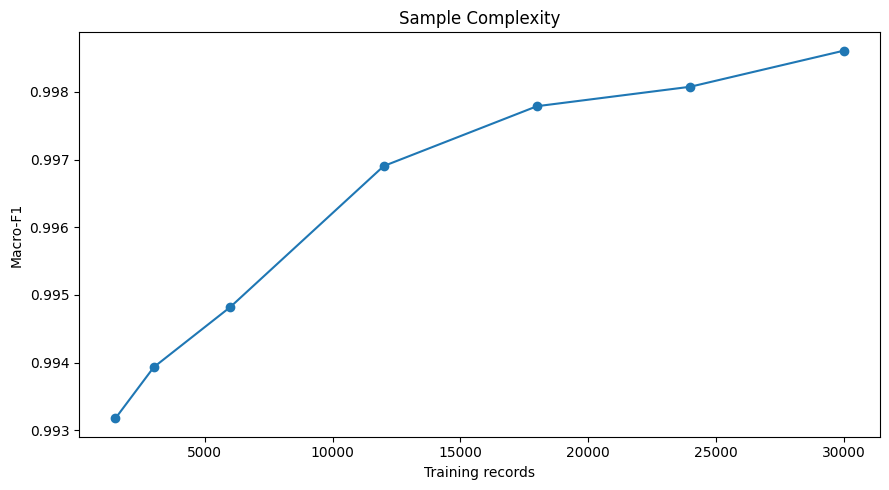

In [56]:
# EDA 53: SAMPLE-COMPLEXITY ANALYSIS
sample, X, y = model_frame(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 40_000))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

complexity_rows = []
for fraction in [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]:
    subset_size = max(200, int(len(X_train) * fraction))
    subset_indices = X_train.sample(n=subset_size, random_state=RANDOM_STATE).index
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train.loc[subset_indices], y_train.loc[subset_indices])
    prediction = model.predict(X_test)
    complexity_rows.append({
        "training_fraction": fraction,
        "training_records": subset_size,
        "macro_f1": f1_score(y_test, prediction, average="macro"),
    })

complexity_table = pd.DataFrame(complexity_rows)
store_table("53_sample_complexity", complexity_table.round(6))
plot_line(complexity_table["training_records"], complexity_table["macro_f1"], "Sample Complexity", "Training records", "Macro-F1")


In [57]:
# EDA 54: DATA-LEAKAGE AND SPLIT-RISK AUDIT
full_baseline = train_test_baseline(MODEL_FEATURES_FULL, n=min(MODEL_SAMPLE_SIZE, 35_000))
reduced_baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 35_000))

leakage_rows = [
    {
        "feature_setting": "full aggregate features",
        "macro_f1": f1_score(full_baseline["y_test"], full_baseline["pred"], average="macro"),
        "contains_direct_rule_signals": True,
    },
    {
        "feature_setting": "reduced aggregate features",
        "macro_f1": f1_score(reduced_baseline["y_test"], reduced_baseline["pred"], average="macro"),
        "contains_direct_rule_signals": False,
    },
]
store_table("54_direct_signal_leakage_check", pd.DataFrame(leakage_rows).round(6))

available_chronics = np.array(sorted(df["chronic_id"].unique()))
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(available_chronics)
test_chronic_count = max(1, int(round(0.20 * len(available_chronics))))
test_chronics = set(available_chronics[:test_chronic_count])
train_chronics = set(available_chronics[test_chronic_count:])

chronic_train = df[df["chronic_id"].isin(train_chronics)]
chronic_test = df[df["chronic_id"].isin(test_chronics)]
chronic_overlap = len(train_chronics.intersection(test_chronics))

chronic_split_table = pd.DataFrame({
    "metric": ["training chronics", "testing chronics", "chronic overlap", "training records", "testing records"],
    "value": [len(train_chronics), len(test_chronics), chronic_overlap, len(chronic_train), len(chronic_test)],
})
store_table("54_chronic_split_audit", chronic_split_table)


,feature_setting,macro_f1,contains_direct_rule_signals
0,full aggregate features,1.000000,True
1,reduced aggregate features,0.998356,False


,metric,value
0,training chronics,21284
1,testing chronics,5321
2,chronic overlap,0
3,training records,237808
4,testing records,62192


,metric,value
0,training chronics,21284
1,testing chronics,5321
2,chronic overlap,0
3,training records,237808
4,testing records,62192


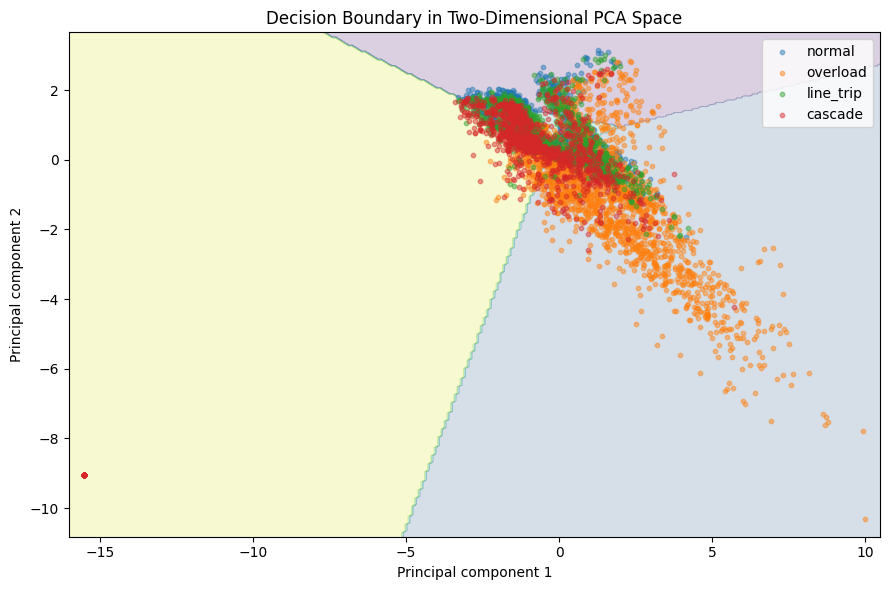

In [58]:
# EDA 55: TWO-DIMENSIONAL DECISION-BOUNDARY VISUALIZATION
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

sample = stratified_sample(df, min(6000, len(df)))
X = sample[MODEL_FEATURES_REDUCED].fillna(0.0)
y = sample["label"].astype(str)

scaled = StandardScaler().fit_transform(X)
projection = PCA(n_components=2).fit_transform(scaled)
boundary_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
boundary_model.fit(projection, y)

x_min, x_max = projection[:, 0].min() - 0.5, projection[:, 0].max() + 0.5
y_min, y_max = projection[:, 1].min() - 0.5, projection[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid_predictions = boundary_model.predict(np.column_stack([xx.ravel(), yy.ravel()]))
encoded_grid = pd.Series(grid_predictions).map(LABEL_TO_INT).to_numpy().reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, encoded_grid, alpha=0.20)
for label in LABEL_ORDER:
    mask = y.to_numpy() == label
    plt.scatter(projection[mask, 0], projection[mask, 1], s=10, alpha=0.45, label=label)
plt.title("Decision Boundary in Two-Dimensional PCA Space")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.legend()
plt.tight_layout()
plt.show()


,rho_topology_interaction,load_stress_interaction,flow_stress_interaction,imbalance_stress_interaction
label,,,,
normal,0.000000,523.920154,19.202560,6.320777
overload,0.043061,986.686112,37.514684,17.592137
line_trip,0.012775,523.627408,19.536400,6.561283
cascade,0.029083,493.333316,18.599719,6.626974


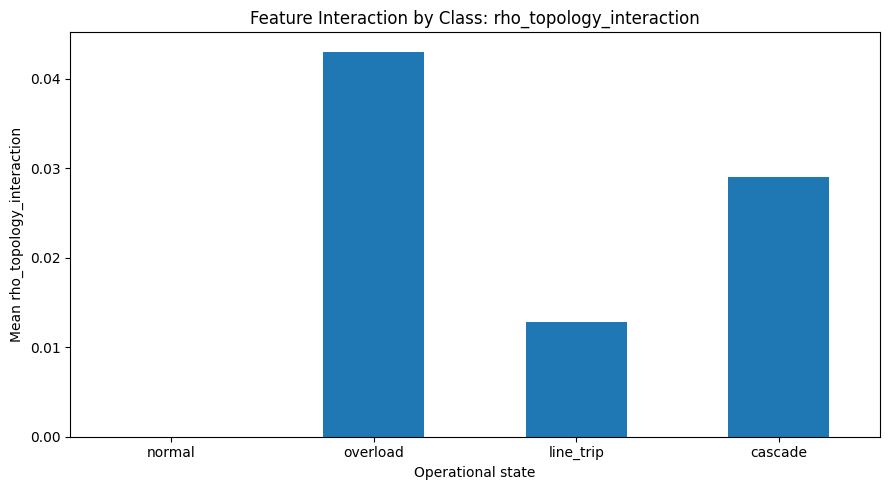

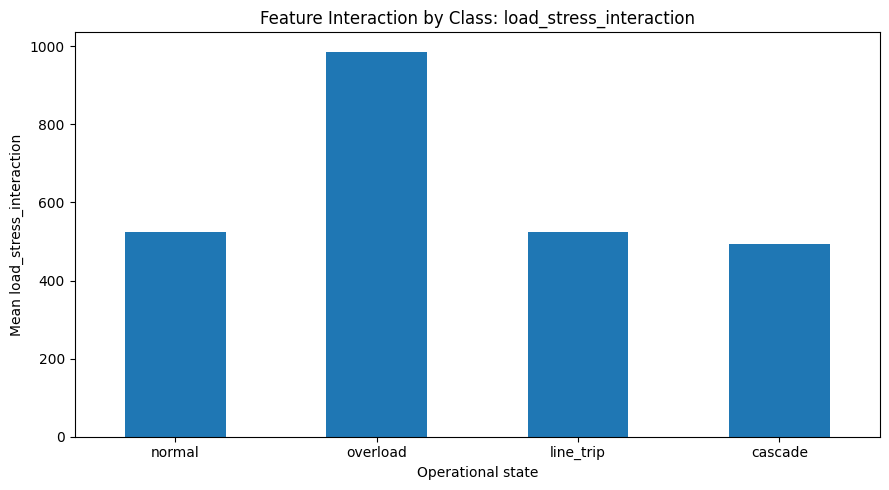

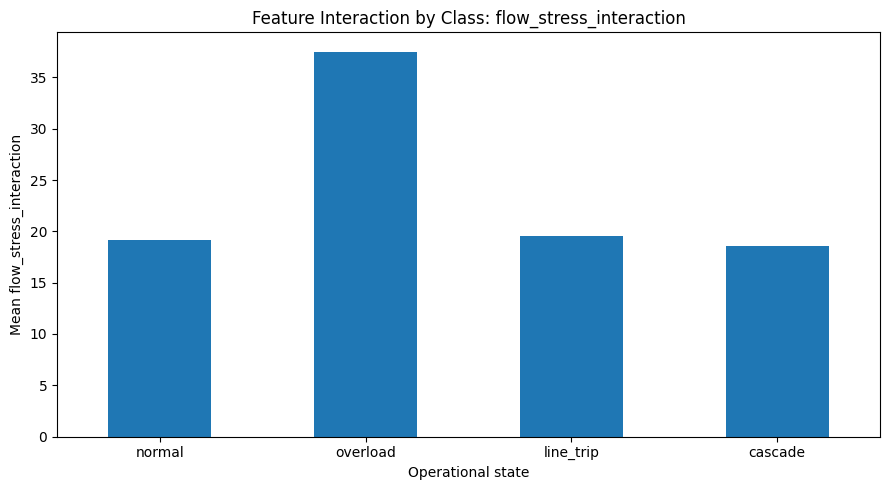

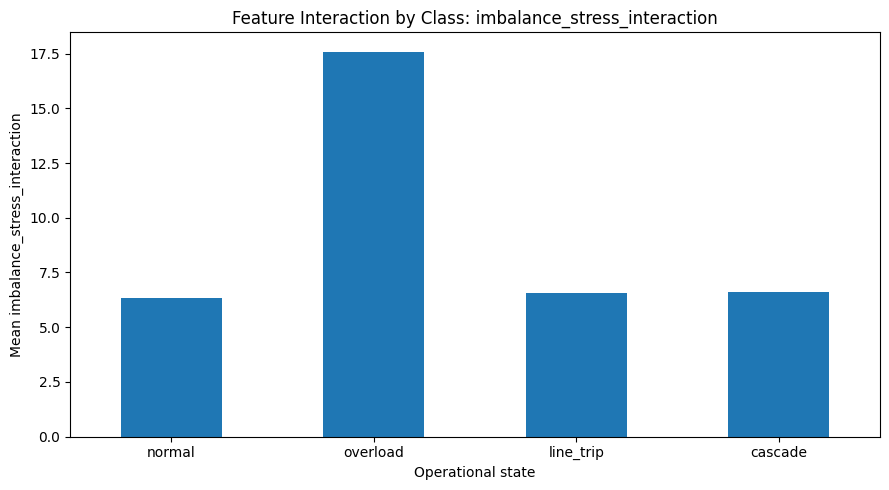

In [59]:
# EDA 56: FEATURE-INTERACTION ANALYSIS
interaction_frame = df.copy()
interaction_frame["rho_topology_interaction"] = interaction_frame["max_rho"] * (1.0 - interaction_frame["connected_fraction"])
interaction_frame["load_stress_interaction"] = interaction_frame["total_load"] * interaction_frame["max_rho"]
interaction_frame["flow_stress_interaction"] = interaction_frame["mean_abs_p_or"] * interaction_frame["max_rho"]
interaction_frame["imbalance_stress_interaction"] = interaction_frame["abs_power_balance"] * interaction_frame["max_rho"]

interaction_features = [
    "rho_topology_interaction",
    "load_stress_interaction",
    "flow_stress_interaction",
    "imbalance_stress_interaction",
]
interaction_summary = (
    interaction_frame.groupby("label", observed=False)[interaction_features]
                     .mean()
                     .round(6)
)
store_table("56_feature_interactions", interaction_summary)

for feature in interaction_features:
    plot_bar(
        interaction_frame.groupby("label", observed=False)[feature].mean(),
        f"Feature Interaction by Class: {feature}",
        "Operational state",
        f"Mean {feature}",
    )


,cascade_records,cascade_percentage,minimum_disconnected_lines,median_disconnected_lines,maximum_disconnected_lines,mean_connected_fraction
0,60000,20.0,2,2.0,59,0.893383


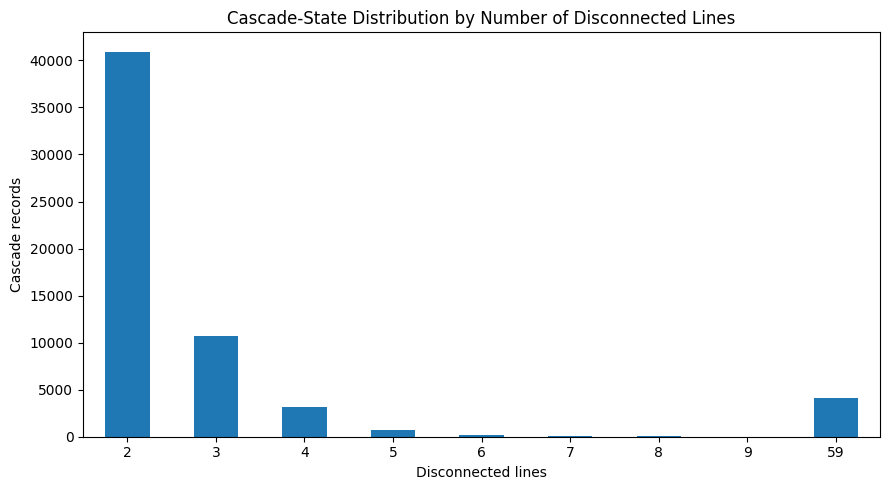

In [60]:
# EDA 57: CASCADE-PATTERN ANALYSIS
cascade = df[df["label"].astype(str) == "cascade"].copy()
cascade_summary = pd.DataFrame({
    "cascade_records": [len(cascade)],
    "cascade_percentage": [100 * len(cascade) / len(df)],
    "minimum_disconnected_lines": [int(cascade["disconnected_lines"].min()) if len(cascade) else np.nan],
    "median_disconnected_lines": [float(cascade["disconnected_lines"].median()) if len(cascade) else np.nan],
    "maximum_disconnected_lines": [int(cascade["disconnected_lines"].max()) if len(cascade) else np.nan],
    "mean_connected_fraction": [float(cascade["connected_fraction"].mean()) if len(cascade) else np.nan],
})
store_table("57_cascade_summary", cascade_summary.round(6))

if len(cascade):
    cascade_line_counts = cascade["disconnected_lines"].value_counts().sort_index()
    plot_bar(cascade_line_counts, "Cascade-State Distribution by Number of Disconnected Lines", "Disconnected lines", "Cascade records")


In [61]:
# EDA 58: PHYSICS-BASED VALIDATION
physics_checks = {
    "normal_has_no_overload": ((df["label"].astype(str) != "normal") | (df["max_rho"] < 1.0)),
    "normal_has_intact_topology": ((df["label"].astype(str) != "normal") | (df["disconnected_lines"] == 0)),
    "overload_meets_rho_threshold": ((df["label"].astype(str) != "overload") | (df["max_rho"] >= 1.0)),
    "line_trip_has_exactly_one_disconnection": ((df["label"].astype(str) != "line_trip") | (df["disconnected_lines"] == 1)),
    "cascade_has_multiple_disconnections": ((df["label"].astype(str) != "cascade") | (df["disconnected_lines"] > 1)),
    "connected_fraction_in_unit_interval": df["connected_fraction"].between(0.0, 1.0),
    "stored_rho_respects_clip": df["max_rho"] <= float(metadata.get("rho_clip", 2.0)),
}

physics_table = pd.DataFrame([
    {
        "check": name,
        "passed_records": int(mask.sum()),
        "failed_records": int((~mask).sum()),
        "pass_percentage": 100 * float(mask.mean()),
    }
    for name, mask in physics_checks.items()
])
store_table("58_physics_validation", physics_table.round(6))


,check,passed_records,failed_records,pass_percentage
0,normal_has_no_overload,300000,0,100.0
1,normal_has_intact_topology,300000,0,100.0
2,overload_meets_rho_threshold,300000,0,100.0
3,line_trip_has_exactly_one_disconnection,300000,0,100.0
4,cascade_has_multiple_disconnections,300000,0,100.0
5,connected_fraction_in_unit_interval,300000,0,100.0
6,stored_rho_respects_clip,300000,0,100.0


,check,passed_records,failed_records,pass_percentage
0,normal_has_no_overload,300000,0,100.0
1,normal_has_intact_topology,300000,0,100.0
2,overload_meets_rho_threshold,300000,0,100.0
3,line_trip_has_exactly_one_disconnection,300000,0,100.0
4,cascade_has_multiple_disconnections,300000,0,100.0
5,connected_fraction_in_unit_interval,300000,0,100.0
6,stored_rho_respects_clip,300000,0,100.0


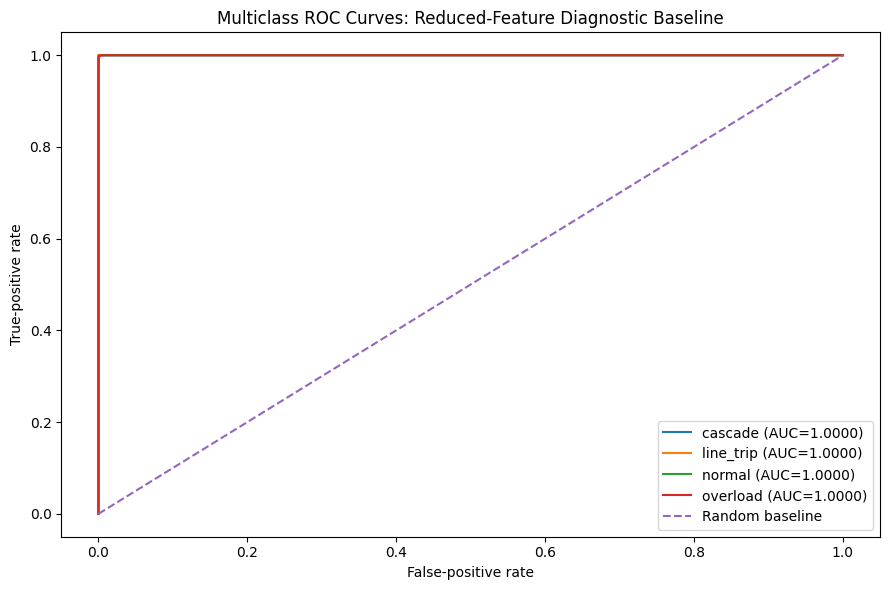

,class,roc_auc
0,cascade,1.000000
1,line_trip,1.000000
2,normal,0.999994
3,overload,0.999992


,class,roc_auc
0,cascade,1.000000
1,line_trip,1.000000
2,normal,0.999994
3,overload,0.999992


In [62]:
# EDA 59: MULTICLASS ROC-AUC CURVE ANALYSIS
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=MODEL_SAMPLE_SIZE)
probabilities = baseline["model"].predict_proba(baseline["X_test"])
class_order = baseline["model"].classes_.tolist()
binary_y = label_binarize(baseline["y_test"], classes=class_order)

roc_rows = []
plt.figure(figsize=(9, 6))
for index, label in enumerate(class_order):
    false_positive_rate, true_positive_rate, _ = roc_curve(binary_y[:, index], probabilities[:, index])
    area = auc(false_positive_rate, true_positive_rate)
    roc_rows.append({"class": label, "roc_auc": area})
    plt.plot(false_positive_rate, true_positive_rate, label=f"{label} (AUC={area:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.title("Multiclass ROC Curves: Reduced-Feature Diagnostic Baseline")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.legend()
plt.tight_layout()
plt.show()

store_table("59_roc_auc_summary", pd.DataFrame(roc_rows))


## **I. Advanced Diagnostic and Repository-Consistency Audits**


In [71]:
# SETUP 04: HELPERS FOR EXTENDED GRAPH, LINE, SPLIT, AND TEMPORAL AUDITS
from collections import Counter
from itertools import combinations
from pathlib import Path
import json
import sys

import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

# Run this notebook from the repository root.
sys.path.append(str(Path.cwd()))

from scripts.pyg_data import GridEnvMetadata, build_node_features, build_edges

PYG_META = GridEnvMetadata(metadata)
N_SUB = int(metadata["n_sub"])
N_LINE = int(metadata["n_line"])

LINE_OR_BUS = np.asarray(metadata["topology"]["line_or_bus"], dtype=int)
LINE_EX_BUS = np.asarray(metadata["topology"]["line_ex_bus"], dtype=int)

# These samples are large enough for reliable EDA while keeping runtime practical.
EXTENDED_SAMPLE_SIZE = min(8_000, len(df))
FEATURE_JUSTIFICATION_SAMPLE_SIZE = min(25_000, len(df))


def canonical_edge(node_a, node_b):
    """Return an undirected edge key."""
    return tuple(sorted((int(node_a), int(node_b))))


def safe_array(record, key, expected_length=None, dtype=float):
    """Read a JSONL array safely and optionally validate its length."""
    values = np.asarray(record.get(key, []), dtype=dtype)
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)

    if expected_length is not None and len(values) != int(expected_length):
        raise ValueError(
            f"{key!r} has length {len(values)}, expected {expected_length}."
        )

    return values


def load_records_by_indices(filepath, indices):
    """
    Stream the JSONL file once and return only the requested records.

    The returned dictionary is keyed by the original zero-based
    JSONL row index.
    """
    requested = {int(index) for index in indices}
    records = {}

    with Path(filepath).open("r", encoding="utf-8") as file:
        for record_index, line in enumerate(file):
            if record_index in requested:
                records[record_index] = json.loads(line)

                if len(records) == len(requested):
                    break

    missing = requested.difference(records)

    if missing:
        raise IndexError(
            f"Could not load {len(missing)} requested JSONL records."
        )

    return records


def sampled_record_indices(frame, n=EXTENDED_SAMPLE_SIZE):
    """Return a label-aware sample of original JSONL row indices."""
    sample = stratified_sample(frame, min(int(n), len(frame)))
    return sample["record_index"].astype(int).tolist()


def sample_frame(frame, n, random_state=RANDOM_STATE):
    """Return a reproducible sample without exceeding the available rows."""
    if len(frame) <= int(n):
        return frame.copy()

    return frame.sample(
        n=int(n),
        random_state=random_state,
    ).copy()


print("Extended EDA helpers are ready.")

Extended EDA helpers are ready.


In [63]:
# EDA 60: FEATURE-ENGINEERING IMPACT ANALYSIS
from sklearn.model_selection import StratifiedKFold, cross_val_score

sample, X_base, y = model_frame(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 30_000))
X_engineered = X_base.copy()
X_engineered["rho_topology_interaction"] = df.loc[X_engineered.index, "max_rho"] * (1.0 - df.loc[X_engineered.index, "connected_fraction"])
X_engineered["load_stress_interaction"] = df.loc[X_engineered.index, "total_load"] * df.loc[X_engineered.index, "max_rho"]
X_engineered["flow_stress_interaction"] = df.loc[X_engineered.index, "mean_abs_p_or"] * df.loc[X_engineered.index, "max_rho"]

cross_validation = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

base_scores = cross_val_score(model, X_base, y, cv=cross_validation, scoring="f1_macro", n_jobs=-1)
engineered_scores = cross_val_score(model, X_engineered, y, cv=cross_validation, scoring="f1_macro", n_jobs=-1)

engineering_table = pd.DataFrame({
    "feature_setting": ["baseline reduced aggregates", "with engineered interactions"],
    "feature_count": [X_base.shape[1], X_engineered.shape[1]],
    "mean_macro_f1": [base_scores.mean(), engineered_scores.mean()],
    "std_macro_f1": [base_scores.std(), engineered_scores.std()],
})
store_table("60_feature_engineering_impact", engineering_table.round(6))


,feature_setting,feature_count,mean_macro_f1,std_macro_f1
0,baseline reduced aggregates,13,0.998508,0.000189
1,with engineered interactions,16,0.999041,0.000344


,feature_setting,feature_count,mean_macro_f1,std_macro_f1
0,baseline reduced aggregates,13,0.998508,0.000189
1,with engineered interactions,16,0.999041,0.000344


In [64]:
# EDA 61: DISTRIBUTION-FIT ANALYSIS
from scipy.stats import kstest, kurtosis, skew

distribution_rows = []
for feature in MODEL_FEATURES_REDUCED:
    values = df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    values = values.sample(n=min(5000, len(values)), random_state=RANDOM_STATE)
    standard_deviation = float(values.std())
    standardized = (values - values.mean()) / standard_deviation if standard_deviation > 0 else values * 0.0
    ks_statistic, p_value = kstest(standardized, "norm")
    distribution_rows.append({
        "feature": feature,
        "skewness": skew(values, bias=False),
        "excess_kurtosis": kurtosis(values, fisher=True, bias=False),
        "normal_fit_ks_statistic": ks_statistic,
        "normal_fit_p_value": p_value,
    })

distribution_fit_table = pd.DataFrame(distribution_rows).sort_values("normal_fit_p_value")
store_table("61_distribution_fit", distribution_fit_table.round(6))


,feature,skewness,excess_kurtosis,normal_fit_ks_statistic,normal_fit_p_value
3,rho_above_90_pct,2.882429,8.783467,0.314650,0.000000
6,load_gen_ratio,-9.127220,81.826619,0.436889,0.000000
12,mean_v_ex,-8.614470,75.534074,0.363564,0.000000
11,mean_v_or,-8.570093,74.988798,0.360870,0.000000
10,mean_abs_q_or,-5.045306,33.647079,0.258939,0.000000
1,std_rho,1.365936,4.836159,0.137184,0.000000
2,rho_range,0.962010,1.187002,0.136093,0.000000
4,total_load,1.371146,4.618990,0.121392,0.000000
5,total_gen,1.330311,4.561016,0.119311,0.000000
7,power_balance,2.283643,15.901763,0.105477,0.000000


,feature,skewness,excess_kurtosis,normal_fit_ks_statistic,normal_fit_p_value
3,rho_above_90_pct,2.882429,8.783467,0.314650,0.000000
6,load_gen_ratio,-9.127220,81.826619,0.436889,0.000000
12,mean_v_ex,-8.614470,75.534074,0.363564,0.000000
11,mean_v_or,-8.570093,74.988798,0.360870,0.000000
10,mean_abs_q_or,-5.045306,33.647079,0.258939,0.000000
1,std_rho,1.365936,4.836159,0.137184,0.000000
2,rho_range,0.962010,1.187002,0.136093,0.000000
4,total_load,1.371146,4.618990,0.121392,0.000000
5,total_gen,1.330311,4.561016,0.119311,0.000000
7,power_balance,2.283643,15.901763,0.105477,0.000000


In [65]:
# EDA 62: PREDICTION-ERROR ANALYSIS
baseline = train_test_baseline(MODEL_FEATURES_REDUCED, n=MODEL_SAMPLE_SIZE)
error_frame = baseline["X_test"].copy()
error_frame["actual_label"] = baseline["y_test"].astype(str)
error_frame["predicted_label"] = baseline["pred"].astype(str)
error_frame["prediction_correct"] = error_frame["actual_label"] == error_frame["predicted_label"]

error_summary = (
    error_frame.groupby(["actual_label", "predicted_label"])
               .size()
               .reset_index(name="records")
               .sort_values("records", ascending=False)
)
store_table("62_prediction_error_pairs", error_summary)

incorrect = error_frame[~error_frame["prediction_correct"]]
print(f"Incorrect predictions: {len(incorrect):,} / {len(error_frame):,}")
if len(incorrect):
    store_table(
        "62_misclassified_feature_profile",
        incorrect[MODEL_FEATURES_REDUCED].describe().T.round(6),
    )


,actual_label,predicted_label,records
7,overload,overload,3450
3,line_trip,line_trip,2497
4,normal,normal,2038
0,cascade,cascade,1999
5,normal,overload,10
2,line_trip,cascade,3
6,overload,normal,2
1,cascade,overload,1


Incorrect predictions: 16 / 10,000


,count,mean,std,min,25%,50%,75%,max
mean_rho,16.0,0.357180,0.046908,0.289837,0.325831,0.352008,0.382894,0.472517
std_rho,16.0,0.209143,0.019772,0.180939,0.198673,0.204727,0.213931,0.267394
rho_range,16.0,0.955602,0.031902,0.854309,0.948137,0.961043,0.969656,0.999608
rho_above_90_pct,16.0,1.187500,0.834166,0.000000,1.000000,1.000000,1.000000,4.000000
total_load,16.0,991.923125,449.945199,498.239996,585.912507,776.695001,1376.922511,1664.729978
total_gen,16.0,1001.338145,449.366220,504.747590,594.621829,795.964502,1383.463257,1672.962915
load_gen_ratio,16.0,0.988618,0.006537,0.975646,0.985456,0.988371,0.994689,0.996128
power_balance,16.0,9.415020,4.144496,5.509893,6.892610,8.393014,9.574824,20.648197
abs_power_balance,16.0,9.415020,4.144496,5.509893,6.892610,8.393014,9.574824,20.648197
mean_abs_p_or,16.0,26.242499,5.140204,19.577350,23.581322,24.771337,27.286325,38.593749


,property,value
0,nodes,36
1,transmission lines,59
2,simple edges,55
3,connected components,1
4,is connected,True
5,average degree,3.055556
6,minimum degree,1.0
7,maximum degree,9.0
8,density,0.087302
9,average clustering coefficient,0.235031


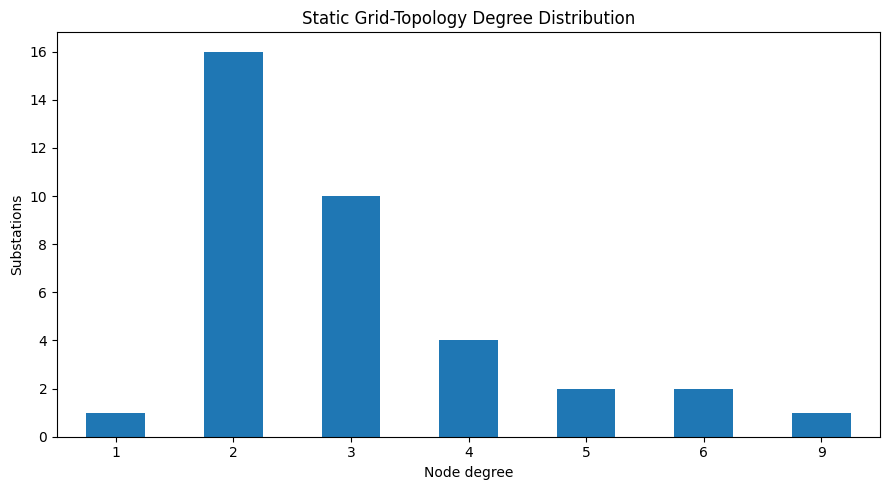

In [66]:
# EDA 63: STATIC GRAPH-PROPERTY ANALYSIS
import networkx as nx

line_or_bus = np.asarray(metadata["topology"]["line_or_bus"], dtype=int)
line_ex_bus = np.asarray(metadata["topology"]["line_ex_bus"], dtype=int)

graph = nx.MultiGraph()
graph.add_nodes_from(range(int(metadata["n_sub"])))
graph.add_edges_from(zip(line_or_bus, line_ex_bus))

simple_graph = nx.Graph(graph)
degree_values = np.asarray([simple_graph.degree(node) for node in simple_graph.nodes()], dtype=float)

graph_property_table = pd.DataFrame({
    "property": [
        "nodes", "transmission lines", "simple edges", "connected components",
        "is connected", "average degree", "minimum degree", "maximum degree",
        "density", "average clustering coefficient",
    ],
    "value": [
        graph.number_of_nodes(), graph.number_of_edges(), simple_graph.number_of_edges(),
        nx.number_connected_components(simple_graph), nx.is_connected(simple_graph),
        float(degree_values.mean()), float(degree_values.min()), float(degree_values.max()),
        nx.density(simple_graph), nx.average_clustering(simple_graph),
    ],
})
store_table("63_static_graph_properties", graph_property_table)

degree_counts = pd.Series(degree_values.astype(int)).value_counts().sort_index()
plot_bar(degree_counts, "Static Grid-Topology Degree Distribution", "Node degree", "Substations")


In [67]:
# EDA 64: HYPERPARAMETER, CLASS-IMBALANCE, RAW-JSONL, AND METADATA INTEGRITY AUDIT
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Part A: lightweight hyperparameter sensitivity.
sample, X, y = model_frame(MODEL_FEATURES_REDUCED, n=min(MODEL_SAMPLE_SIZE, 25_000))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

hyperparameter_rows = []
for n_estimators in [40, 80, 140]:
    for max_depth in [None, 12, 24]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        hyperparameter_rows.append({
            "n_estimators": n_estimators,
            "max_depth": str(max_depth),
            "macro_f1": f1_score(y_test, prediction, average="macro"),
        })
store_table("64_hyperparameter_sensitivity", pd.DataFrame(hyperparameter_rows).round(6))

# Part B: compare no weighting with balanced class weighting.
imbalance_rows = []
for class_weight in [None, "balanced", "balanced_subsample"]:
    model = RandomForestClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight,
    )
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    imbalance_rows.append({
        "class_weight": str(class_weight),
        "macro_f1": f1_score(y_test, prediction, average="macro"),
        "weighted_f1": f1_score(y_test, prediction, average="weighted"),
    })
store_table("64_class_weight_comparison", pd.DataFrame(imbalance_rows).round(6))

# Part C: stream the JSONL file to verify row counts, array lengths, and label counts.
expected_lengths = {
    "rho": int(metadata["n_line"]),
    "p_or": int(metadata["n_line"]),
    "q_or": int(metadata["n_line"]),
    "p_ex": int(metadata["n_line"]),
    "q_ex": int(metadata["n_line"]),
    "v_or": int(metadata["n_line"]),
    "v_ex": int(metadata["n_line"]),
    "line_status": int(metadata["n_line"]),
    "load_p": int(metadata["n_load"]),
    "load_q": int(metadata["n_load"]),
    "gen_p": int(metadata["n_gen"]),
    "gen_q": int(metadata["n_gen"]),
}
raw_label_counts = Counter()
length_mismatches = Counter()
nonfinite_values = Counter()
raw_records = 0

with JSONL_PATH.open("r", encoding="utf-8") as file:
    for raw_records, line in enumerate(file, start=1):
        record = json.loads(line)
        raw_label_counts[str(record.get("label"))] += 1
        for key, expected_length in expected_lengths.items():
            values = record.get(key, [])
            if len(values) != expected_length:
                length_mismatches[key] += 1
            try:
                array = np.asarray(values, dtype=float)
                nonfinite_values[key] += int((~np.isfinite(array)).sum())
            except Exception:
                nonfinite_values[key] += 1

        if RAW_AUDIT_MAX_LINES is not None and raw_records >= RAW_AUDIT_MAX_LINES:
            break

raw_integrity_table = pd.DataFrame({
    "metric": [
        "raw JSONL rows scanned",
        "metadata total_records",
        "DataFrame rows loaded",
        "array-length mismatch fields",
        "non-finite-value fields",
        "metadata edge_feature_dim",
        "current pyg_data.py edge attributes",
    ],
    "value": [
        raw_records,
        metadata.get("total_records"),
        len(df),
        dict(length_mismatches),
        dict(nonfinite_values),
        metadata.get("edge_feature_dim"),
        "4: rho, p_or, q_or, line_status",
    ],
})
store_table("64_raw_integrity_summary", raw_integrity_table)

label_count_comparison = pd.DataFrame({
    "metadata_count": pd.Series(metadata.get("label_counts", {})),
    "raw_jsonl_count": pd.Series(raw_label_counts),
    "loaded_dataframe_count": df["label"].value_counts(),
}).fillna(0).astype(int).reindex(LABEL_ORDER)
store_table("64_label_count_comparison", label_count_comparison)

print(
    "\nImportant repository-consistency note:\n"
    "- The generator metadata records edge_feature_dim = 3 for the raw measurements rho, p_or, and q_or.\n"
    "- The current scripts/pyg_data.py graph builder constructs 4 active-edge attributes by adding line_status.\n"
    "- Keep this distinction explicit when documenting the final graph representation."
)


,n_estimators,max_depth,macro_f1
0,40,None,0.998586
1,40,12,0.998741
2,40,24,0.998586
3,80,None,0.998586
4,80,12,0.998561
5,80,24,0.998586
6,140,None,0.998586
7,140,12,0.998561
8,140,24,0.998586


,class_weight,macro_f1,weighted_f1
0,None,0.998586,0.99856
1,balanced,0.998430,0.99840
2,balanced_subsample,0.998717,0.99872


,metric,value
0,raw JSONL rows scanned,300000
1,metadata total_records,300000
2,DataFrame rows loaded,300000
3,array-length mismatch fields,{}
4,non-finite-value fields,"{'rho': 0, 'p_or': 0, 'q_or': 0, 'p_ex': 0, 'q..."
5,metadata edge_feature_dim,3
6,current pyg_data.py edge attributes,"4: rho, p_or, q_or, line_status"


,metadata_count,raw_jsonl_count,loaded_dataframe_count
normal,61444,61444,61444
overload,103556,103556,103556
line_trip,75000,75000,75000
cascade,60000,60000,60000



Important repository-consistency note:
- The generator metadata records edge_feature_dim = 3 for the raw measurements rho, p_or, and q_or.
- The current scripts/pyg_data.py graph builder constructs 4 active-edge attributes by adding line_status.
- Keep this distinction explicit when documenting the final graph representation.


In [72]:
# EDA 65: RAW-TO-GRAPH PYTORCH GEOMETRIC TENSOR AUDIT

graph_audit_indices = sampled_record_indices(
    df,
    n=EXTENDED_SAMPLE_SIZE,
)

graph_audit_records = load_records_by_indices(
    JSONL_PATH,
    graph_audit_indices,
)

graph_audit_rows = []
shape_failure_rows = []

for record_index in graph_audit_indices:
    record = graph_audit_records[record_index]

    line_status = safe_array(
        record,
        "line_status",
        expected_length=N_LINE,
        dtype=int,
    )

    expected_active_edges = int(np.sum(line_status == 1))

    node_features = np.asarray(
        build_node_features(record, PYG_META),
        dtype=np.float32,
    )

    edge_index_list, edge_attr_list = build_edges(
        record,
        PYG_META,
    )

    edge_index = np.asarray(
        edge_index_list,
        dtype=np.int64,
    )

    if edge_index.size == 0:
        edge_index = np.empty((2, 0), dtype=np.int64)
    else:
        edge_index = edge_index.reshape(2, -1)

    edge_attr = np.asarray(
        edge_attr_list,
        dtype=np.float32,
    )

    if edge_attr.size == 0:
        edge_attr = np.empty((0, 4), dtype=np.float32)
    else:
        edge_attr = edge_attr.reshape(-1, 4)

    graph = Data(
        x=torch.tensor(
            node_features,
            dtype=torch.float,
        ),
        edge_index=torch.tensor(
            edge_index,
            dtype=torch.long,
        ),
        edge_attr=torch.tensor(
            edge_attr,
            dtype=torch.float,
        ),
        y=torch.tensor(
            int(record.get("label_int", -1)),
            dtype=torch.long,
        ),
    )

    active_pairs = {
        (int(source), int(target))
        for source, target in graph.edge_index.t().tolist()
    }

    reciprocal_edges = sum(
        (target, source) in active_pairs
        for source, target in active_pairs
    )

    reciprocal_edge_fraction = (
        reciprocal_edges / len(active_pairs)
        if active_pairs
        else np.nan
    )

    row = {
        "record_index": int(record_index),
        "label": str(record.get("label")),
        "node_rows": int(graph.x.shape[0]),
        "node_feature_dim": int(graph.x.shape[1]),
        "active_edges": int(graph.edge_index.shape[1]),
        "edge_attr_rows": int(graph.edge_attr.shape[0]),
        "edge_feature_dim": int(graph.edge_attr.shape[1]),
        "expected_active_edges_from_line_status": expected_active_edges,
        "dead_lines_removed": (
            int(graph.edge_index.shape[1])
            == expected_active_edges
        ),
        "edge_attr_matches_edge_index": (
            int(graph.edge_attr.shape[0])
            == int(graph.edge_index.shape[1])
        ),
        "node_shape_valid": (
            tuple(graph.x.shape)
            == (N_SUB, 4)
        ),
        "edge_feature_shape_valid": (
            int(graph.edge_attr.shape[1])
            == 4
        ),
        "all_retained_edge_status_values_are_one": (
            bool(
                np.allclose(
                    graph.edge_attr[:, 3].numpy(),
                    1.0,
                )
            )
            if graph.edge_attr.shape[0] > 0
            else True
        ),
        "reciprocal_edge_fraction": reciprocal_edge_fraction,
    }

    graph_audit_rows.append(row)

    if not all([
        row["dead_lines_removed"],
        row["edge_attr_matches_edge_index"],
        row["node_shape_valid"],
        row["edge_feature_shape_valid"],
        row["all_retained_edge_status_values_are_one"],
    ]):
        shape_failure_rows.append(row)


graph_audit_detail = pd.DataFrame(
    graph_audit_rows
)

store_table(
    "65_raw_to_graph_audit_detail",
    graph_audit_detail.head(50),
)

graph_audit_summary = pd.DataFrame({
    "metric": [
        "sampled graphs",
        "graphs with valid node shape: n_sub x 4",
        "graphs with valid edge_attr width: 4",
        "graphs where active edges match connected lines",
        "graphs where edge_attr rows match edge_index columns",
        "graphs where retained line_status values are all 1",
        "graphs with zero active edges",
        "mean active edges",
        "metadata edge_feature_dim",
        "current pyg_data.py edge_feature_dim",
        "mean reciprocal-edge fraction",
    ],
    "value": [
        len(graph_audit_detail),
        int(
            graph_audit_detail[
                "node_shape_valid"
            ].sum()
        ),
        int(
            graph_audit_detail[
                "edge_feature_shape_valid"
            ].sum()
        ),
        int(
            graph_audit_detail[
                "dead_lines_removed"
            ].sum()
        ),
        int(
            graph_audit_detail[
                "edge_attr_matches_edge_index"
            ].sum()
        ),
        int(
            graph_audit_detail[
                "all_retained_edge_status_values_are_one"
            ].sum()
        ),
        int(
            (
                graph_audit_detail[
                    "active_edges"
                ]
                == 0
            ).sum()
        ),
        float(
            graph_audit_detail[
                "active_edges"
            ].mean()
        ),
        metadata.get("edge_feature_dim"),
        4,
        float(
            graph_audit_detail[
                "reciprocal_edge_fraction"
            ]
            .dropna()
            .mean()
        ),
    ],
})

store_table(
    "65_raw_to_graph_audit_summary",
    graph_audit_summary,
)

graph_shape_failures = pd.DataFrame(
    shape_failure_rows
)

store_table(
    "65_raw_to_graph_failures",
    graph_shape_failures,
)

active_edges_by_class = (
    graph_audit_detail
    .groupby(
        "label",
        observed=False,
    )["active_edges"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
    ])
    .reindex(LABEL_ORDER)
    .round(4)
)

store_table(
    "65_active_edges_by_class",
    active_edges_by_class,
)

print(
    "\nInterpretation note:\n"
    "- The current graph builder should produce 4 node features and 4 edge attributes.\n"
    "- Disconnected lines should be absent from edge_index.\n"
    "- The reciprocal-edge fraction is reported for inspection only.\n"
    "  A low value means that the builder stores mostly one directed\n"
    "  orientation per physical transmission line.\n"
)

,record_index,label,node_rows,node_feature_dim,active_edges,edge_attr_rows,edge_feature_dim,expected_active_edges_from_line_status,dead_lines_removed,edge_attr_matches_edge_index,node_shape_valid,edge_feature_shape_valid,all_retained_edge_status_values_are_one,reciprocal_edge_fraction
0,260570,overload,36,4,59,59,4,59,True,True,True,True,True,0.0
1,131539,overload,36,4,58,58,4,58,True,True,True,True,True,0.0
2,155216,overload,36,4,57,57,4,57,True,True,True,True,True,0.0
3,257689,overload,36,4,58,58,4,58,True,True,True,True,True,0.0
4,244804,overload,36,4,57,57,4,57,True,True,True,True,True,0.0
5,140581,overload,36,4,57,57,4,57,True,True,True,True,True,0.0
6,252970,overload,36,4,58,58,4,58,True,True,True,True,True,0.0
7,219891,overload,36,4,57,57,4,57,True,True,True,True,True,0.0
8,258344,overload,36,4,58,58,4,58,True,True,True,True,True,0.0
9,232664,overload,36,4,57,57,4,57,True,True,True,True,True,0.0


Saved table: F:\T2530913-code\eda_outputs\tables\65_raw_to_graph_audit_detail.csv


,metric,value
0,sampled graphs,8000.00000
1,graphs with valid node shape: n_sub x 4,8000.00000
2,graphs with valid edge_attr width: 4,8000.00000
3,graphs where active edges match connected lines,8000.00000
4,graphs where edge_attr rows match edge_index c...,8000.00000
5,graphs where retained line_status values are a...,8000.00000
6,graphs with zero active edges,114.00000
7,mean active edges,56.81275
8,metadata edge_feature_dim,3.00000
9,current pyg_data.py edge_feature_dim,4.00000


Saved table: F:\T2530913-code\eda_outputs\tables\65_raw_to_graph_audit_summary.csv


""


Saved table: F:\T2530913-code\eda_outputs\tables\65_raw_to_graph_failures.csv


,count,mean,median,min,max
label,,,,,
normal,1639,59.0000,59.0,59,59
overload,2761,57.1061,57.0,49,59
line_trip,2000,58.0000,58.0,58,58
cascade,1600,52.5819,57.0,0,57


Saved table: F:\T2530913-code\eda_outputs\tables\65_active_edges_by_class.csv

Interpretation note:
- The current graph builder should produce 4 node features and 4 edge attributes.
- Disconnected lines should be absent from edge_index.
- The reciprocal-edge fraction is reported for inspection only.
  A low value means that the builder stores mostly one directed
  orientation per physical transmission line.



## **J. Transmission-Line and Substation Vulnerability Analysis**

,line_id,origin_substation,extremity_substation,mean_rho,maximum_rho,overload_frames,overload_frame_pct,disconnected_frames,disconnected_frame_pct,line_trip_disconnect_frames,cascade_disconnect_frames,endpoint_pair
13,13,11,12,0.546708,1.999945,26969,8.989667,32242,10.747333,6963,18150,11 -> 12
41,41,26,28,0.597830,1.999513,21091,7.030333,29947,9.982333,1345,8981,26 -> 28
39,39,22,26,0.510041,1.999305,15626,5.208667,24319,8.106333,5351,12018,22 -> 26
56,56,30,26,0.384536,1.490021,179,0.059667,23429,7.809667,355,4826,30 -> 26
45,45,30,31,0.384536,1.490021,179,0.059667,22729,7.576333,500,4812,30 -> 31
18,18,9,16,0.274962,1.934717,119,0.039667,19924,6.641333,5020,10501,9 -> 16
0,0,2,3,0.459280,1.999850,9940,3.313333,19800,6.600000,5777,10240,2 -> 3
23,23,16,18,0.531606,1.549367,8520,2.840000,17735,5.911667,2573,8050,16 -> 18
40,40,26,27,0.397353,1.999477,15166,5.055333,16281,5.427000,839,6539,26 -> 27
9,9,7,9,0.170055,1.899467,474,0.158000,15377,5.125667,4020,9040,7 -> 9


Saved table: F:\T2530913-code\eda_outputs\tables\66_line_level_transmission_profile.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\most_frequently_disconnected_transmission_lines_01.png


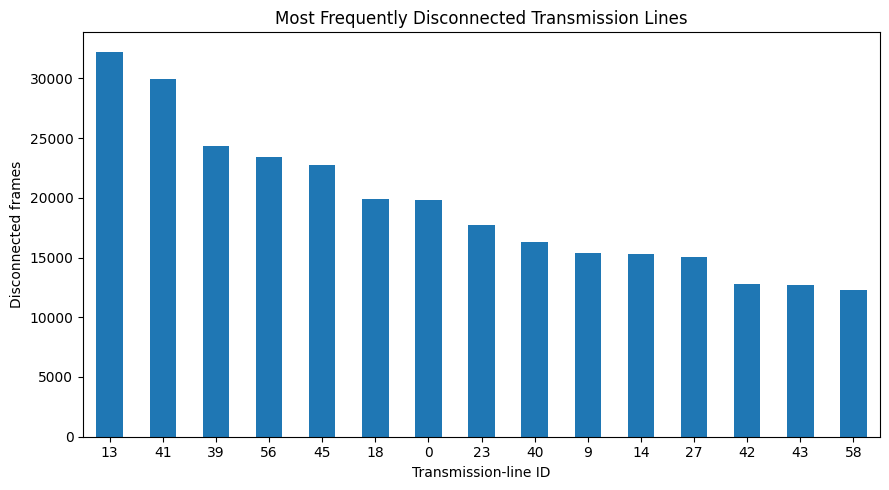

Saved figure: F:\T2530913-code\eda_outputs\figures\most_frequently_overloaded_transmission_lines_01.png


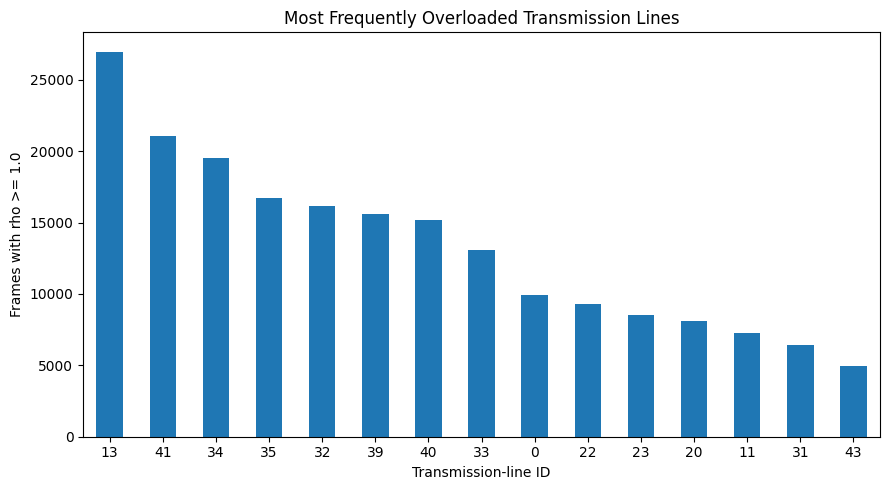

line_id,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
normal,0.463453,0.429147,0.182061,0.252561,0.545634,0.169514,0.138770,0.149508,0.203128,0.163147,...,0.278489,0.253140,0.223010,0.287082,0.175937,0.167811,0.638900,0.433889,0.350582,0.624381
overload,0.516552,0.417179,0.198524,0.293901,0.523262,0.209308,0.177355,0.174172,0.248654,0.188270,...,0.369741,0.317074,0.325848,0.313229,0.206546,0.193050,0.617120,0.310582,0.472099,0.621693
line_trip,0.433633,0.413450,0.180019,0.254547,0.543852,0.174537,0.143786,0.150073,0.213426,0.158178,...,0.278130,0.246692,0.221026,0.275274,0.170719,0.163105,0.630529,0.429846,0.344397,0.622723
cascade,0.388216,0.367907,0.167874,0.239818,0.491187,0.181510,0.154387,0.149539,0.220292,0.160539,...,0.262222,0.225024,0.209715,0.243239,0.148871,0.142112,0.564885,0.405000,0.307618,0.566564


Saved table: F:\T2530913-code\eda_outputs\tables\66_class_mean_rho_by_line.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\mean_transmission_line_loading_ratio_by_class_01.png


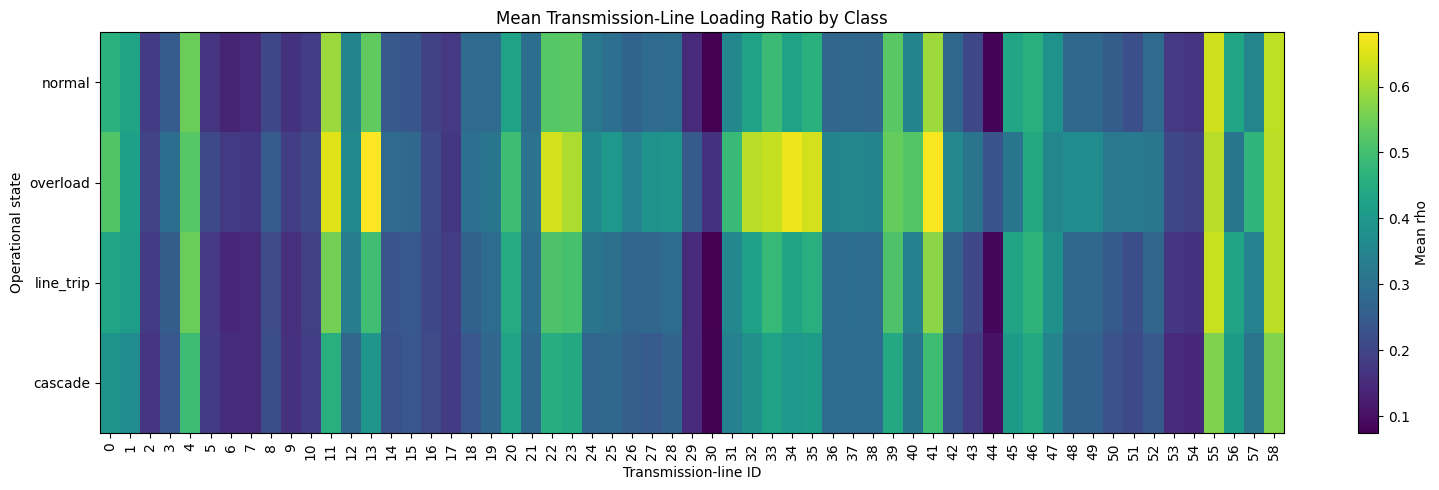

In [73]:
# EDA 66: LINE-LEVEL TRANSMISSION-STRESS AND DISCONNECTION ANALYSIS

line_rho_sum = np.zeros(
    N_LINE,
    dtype=np.float64,
)

line_rho_max = np.full(
    N_LINE,
    -np.inf,
    dtype=np.float64,
)

line_overload_frames = np.zeros(
    N_LINE,
    dtype=np.int64,
)

line_disconnect_frames = np.zeros(
    N_LINE,
    dtype=np.int64,
)

line_cascade_disconnect_frames = np.zeros(
    N_LINE,
    dtype=np.int64,
)

line_trip_disconnect_frames = np.zeros(
    N_LINE,
    dtype=np.int64,
)

line_class_rho_sum = {
    label: np.zeros(
        N_LINE,
        dtype=np.float64,
    )
    for label in LABEL_ORDER
}

line_class_record_count = Counter()

disconnected_pair_counter = Counter()
cascade_pair_counter = Counter()

raw_rows_scanned = 0

with JSONL_PATH.open(
    "r",
    encoding="utf-8",
) as file:

    for raw_rows_scanned, line in enumerate(
        file,
        start=1,
    ):
        record = json.loads(line)

        rho = safe_array(
            record,
            "rho",
            expected_length=N_LINE,
            dtype=float,
        )

        line_status = safe_array(
            record,
            "line_status",
            expected_length=N_LINE,
            dtype=int,
        )

        label = str(
            record.get("label")
        )

        disconnected_indices = np.flatnonzero(
            line_status == 0
        )

        overloaded_mask = (
            rho >= 1.0
        )

        line_rho_sum += rho

        line_rho_max = np.maximum(
            line_rho_max,
            rho,
        )

        line_overload_frames += overloaded_mask.astype(
            np.int64
        )

        line_disconnect_frames += (
            line_status == 0
        ).astype(
            np.int64
        )

        if label in line_class_rho_sum:
            line_class_rho_sum[label] += rho
            line_class_record_count[label] += 1

        if label == "line_trip":
            line_trip_disconnect_frames += (
                line_status == 0
            ).astype(
                np.int64
            )

        if label == "cascade":
            line_cascade_disconnect_frames += (
                line_status == 0
            ).astype(
                np.int64
            )

        if len(disconnected_indices) >= 2:
            for first_line, second_line in combinations(
                disconnected_indices.tolist(),
                2,
            ):
                pair_key = tuple(
                    sorted(
                        (
                            int(first_line),
                            int(second_line),
                        )
                    )
                )

                disconnected_pair_counter[
                    pair_key
                ] += 1

                if label == "cascade":
                    cascade_pair_counter[
                        pair_key
                    ] += 1


line_level_table = pd.DataFrame({
    "line_id": np.arange(
        N_LINE,
        dtype=int,
    ),
    "origin_substation": LINE_OR_BUS,
    "extremity_substation": LINE_EX_BUS,
    "mean_rho": (
        line_rho_sum
        / max(
            raw_rows_scanned,
            1,
        )
    ),
    "maximum_rho": line_rho_max,
    "overload_frames": line_overload_frames,
    "overload_frame_pct": (
        100
        * line_overload_frames
        / max(
            raw_rows_scanned,
            1,
        )
    ),
    "disconnected_frames": line_disconnect_frames,
    "disconnected_frame_pct": (
        100
        * line_disconnect_frames
        / max(
            raw_rows_scanned,
            1,
        )
    ),
    "line_trip_disconnect_frames": (
        line_trip_disconnect_frames
    ),
    "cascade_disconnect_frames": (
        line_cascade_disconnect_frames
    ),
})

line_level_table["endpoint_pair"] = (
    line_level_table[
        "origin_substation"
    ].astype(str)
    + " -> "
    + line_level_table[
        "extremity_substation"
    ].astype(str)
)

line_level_ranked = (
    line_level_table
    .sort_values(
        [
            "disconnected_frames",
            "overload_frames",
            "maximum_rho",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
)

store_table(
    "66_line_level_transmission_profile",
    line_level_ranked,
)

top_disconnected = (
    line_level_table
    .nlargest(
        15,
        "disconnected_frames",
    )
    .set_index(
        "line_id"
    )[
        "disconnected_frames"
    ]
)

plot_bar(
    top_disconnected,
    "Most Frequently Disconnected Transmission Lines",
    "Transmission-line ID",
    "Disconnected frames",
)

top_overloaded = (
    line_level_table
    .nlargest(
        15,
        "overload_frames",
    )
    .set_index(
        "line_id"
    )[
        "overload_frames"
    ]
)

plot_bar(
    top_overloaded,
    "Most Frequently Overloaded Transmission Lines",
    "Transmission-line ID",
    "Frames with rho >= 1.0",
)

class_mean_rho_by_line = pd.DataFrame(
    {
        label: (
            line_class_rho_sum[label]
            / max(
                line_class_record_count[label],
                1,
            )
        )
        for label in LABEL_ORDER
    },
    index=pd.Index(
        np.arange(
            N_LINE
        ),
        name="line_id",
    ),
).T

store_table(
    "66_class_mean_rho_by_line",
    class_mean_rho_by_line.round(6),
)

plt.figure(
    figsize=(
        16,
        5,
    )
)

plt.imshow(
    class_mean_rho_by_line,
    aspect="auto",
)

plt.colorbar(
    label="Mean rho"
)

plt.yticks(
    range(
        len(
            LABEL_ORDER
        )
    ),
    LABEL_ORDER,
)

plt.xticks(
    range(
        N_LINE
    ),
    range(
        N_LINE
    ),
    rotation=90,
)

plt.xlabel(
    "Transmission-line ID"
)

plt.ylabel(
    "Operational state"
)

plt.title(
    "Mean Transmission-Line Loading Ratio by Class"
)

plt.tight_layout()
plt.show()

,first_line_id,second_line_id,first_line_path,second_line_path,co_disconnected_frames
0,41,56,26 -> 28,30 -> 26,13405
1,41,45,26 -> 28,30 -> 31,12772
2,40,41,26 -> 27,26 -> 28,12715
3,40,56,26 -> 27,30 -> 26,8182
4,42,43,27 -> 28,27 -> 29,7916
5,40,45,26 -> 27,30 -> 31,7854
6,13,39,11 -> 12,22 -> 26,7110
7,13,41,11 -> 12,26 -> 28,6847
8,41,43,26 -> 28,27 -> 29,6752
9,13,18,11 -> 12,9 -> 16,6592


Saved table: F:\T2530913-code\eda_outputs\tables\67_top_co_disconnected_line_pairs_all_multiline_states.csv


,first_line_id,second_line_id,first_line_path,second_line_path,co_disconnected_frames
0,13,18,11 -> 12,9 -> 16,6149
1,41,43,26 -> 28,27 -> 29,5912
2,13,39,11 -> 12,22 -> 26,5897
3,42,43,27 -> 28,27 -> 29,5431
4,41,42,26 -> 28,27 -> 28,5376
5,13,55,11 -> 12,5 -> 4,5332
6,13,20,11 -> 12,12 -> 16,5303
7,13,46,11 -> 12,5 -> 32,5296
8,40,41,26 -> 27,26 -> 28,4966
9,39,58,22 -> 26,32 -> 33,4942


Saved table: F:\T2530913-code\eda_outputs\tables\67_top_co_disconnected_line_pairs_cascade_only.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\most_frequent_co_disconnected_line_pairs_in_cascade_states_01.png


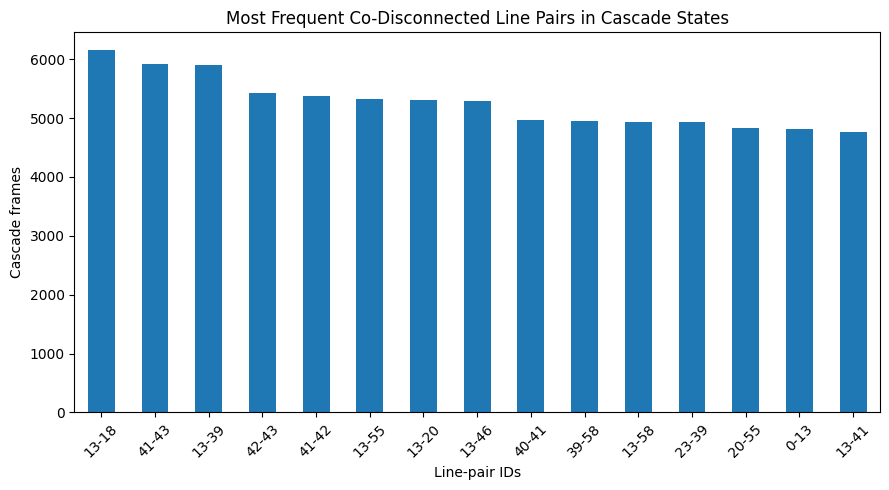

In [74]:
# EDA 67: FREQUENTLY CO-DISCONNECTED LINE-PAIR ANALYSIS

def pair_counter_to_table(
    counter,
    table_name,
    top_n=50,
):
    rows = []

    for (
        first_line,
        second_line,
    ), count in counter.most_common(
        top_n
    ):
        rows.append({
            "first_line_id": int(
                first_line
            ),
            "second_line_id": int(
                second_line
            ),
            "first_line_path": (
                f"{LINE_OR_BUS[first_line]}"
                f" -> "
                f"{LINE_EX_BUS[first_line]}"
            ),
            "second_line_path": (
                f"{LINE_OR_BUS[second_line]}"
                f" -> "
                f"{LINE_EX_BUS[second_line]}"
            ),
            "co_disconnected_frames": int(
                count
            ),
        })

    table = pd.DataFrame(
        rows
    )

    store_table(
        table_name,
        table,
    )

    return table


top_all_pairs = pair_counter_to_table(
    disconnected_pair_counter,
    "67_top_co_disconnected_line_pairs_all_multiline_states",
    top_n=50,
)

top_cascade_pairs = pair_counter_to_table(
    cascade_pair_counter,
    "67_top_co_disconnected_line_pairs_cascade_only",
    top_n=50,
)

if len(
    top_cascade_pairs
):
    top_pairs_plot = (
        top_cascade_pairs
        .head(
            15
        )
        .copy()
    )

    top_pairs_plot["line_pair"] = (
        top_pairs_plot.apply(
            lambda row: (
                f"{int(row['first_line_id'])}"
                f"-"
                f"{int(row['second_line_id'])}"
            ),
            axis=1,
        )
    )

    plot_bar(
        top_pairs_plot
        .set_index(
            "line_pair"
        )[
            "co_disconnected_frames"
        ],
        "Most Frequent Co-Disconnected Line Pairs in Cascade States",
        "Line-pair IDs",
        "Cascade frames",
        rotation=45,
    )

else:
    print(
        "No co-disconnected line pairs were found."
    )

,first_line_id,second_line_id,first_line_path,second_line_path,co_disconnected_frames
0,41,56,26 -> 28,30 -> 26,13405
1,41,45,26 -> 28,30 -> 31,12772
2,40,41,26 -> 27,26 -> 28,12715
3,40,56,26 -> 27,30 -> 26,8182
4,42,43,27 -> 28,27 -> 29,7916
5,40,45,26 -> 27,30 -> 31,7854
6,13,39,11 -> 12,22 -> 26,7110
7,13,41,11 -> 12,26 -> 28,6847
8,41,43,26 -> 28,27 -> 29,6752
9,13,18,11 -> 12,9 -> 16,6592


Saved table: F:\T2530913-code\eda_outputs\tables\67_top_co_disconnected_line_pairs_all_multiline_states.csv


,first_line_id,second_line_id,first_line_path,second_line_path,co_disconnected_frames
0,13,18,11 -> 12,9 -> 16,6149
1,41,43,26 -> 28,27 -> 29,5912
2,13,39,11 -> 12,22 -> 26,5897
3,42,43,27 -> 28,27 -> 29,5431
4,41,42,26 -> 28,27 -> 28,5376
5,13,55,11 -> 12,5 -> 4,5332
6,13,20,11 -> 12,12 -> 16,5303
7,13,46,11 -> 12,5 -> 32,5296
8,40,41,26 -> 27,26 -> 28,4966
9,39,58,22 -> 26,32 -> 33,4942


Saved table: F:\T2530913-code\eda_outputs\tables\67_top_co_disconnected_line_pairs_cascade_only.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\most_frequent_co_disconnected_line_pairs_in_cascade_states_02.png


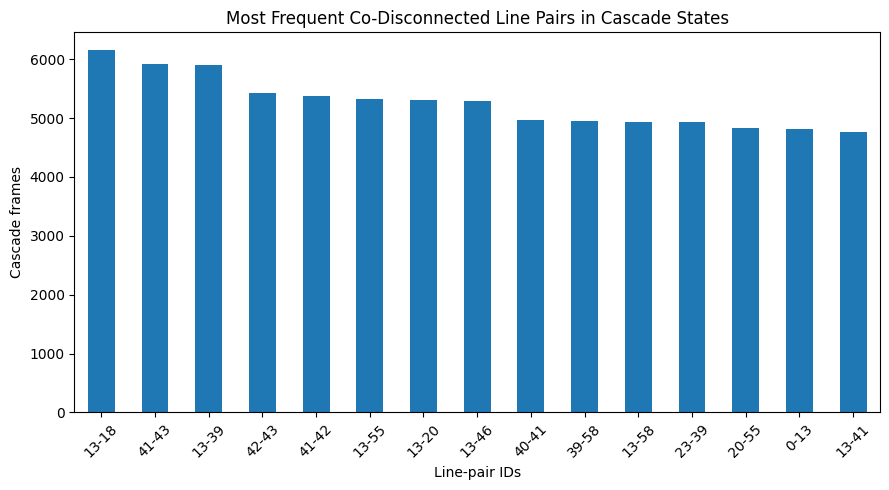

In [75]:
# EDA 67: FREQUENTLY CO-DISCONNECTED LINE-PAIR ANALYSIS

def pair_counter_to_table(
    counter,
    table_name,
    top_n=50,
):
    rows = []

    for (
        first_line,
        second_line,
    ), count in counter.most_common(
        top_n
    ):
        rows.append({
            "first_line_id": int(
                first_line
            ),
            "second_line_id": int(
                second_line
            ),
            "first_line_path": (
                f"{LINE_OR_BUS[first_line]}"
                f" -> "
                f"{LINE_EX_BUS[first_line]}"
            ),
            "second_line_path": (
                f"{LINE_OR_BUS[second_line]}"
                f" -> "
                f"{LINE_EX_BUS[second_line]}"
            ),
            "co_disconnected_frames": int(
                count
            ),
        })

    table = pd.DataFrame(
        rows
    )

    store_table(
        table_name,
        table,
    )

    return table


top_all_pairs = pair_counter_to_table(
    disconnected_pair_counter,
    "67_top_co_disconnected_line_pairs_all_multiline_states",
    top_n=50,
)

top_cascade_pairs = pair_counter_to_table(
    cascade_pair_counter,
    "67_top_co_disconnected_line_pairs_cascade_only",
    top_n=50,
)

if len(
    top_cascade_pairs
):
    top_pairs_plot = (
        top_cascade_pairs
        .head(
            15
        )
        .copy()
    )

    top_pairs_plot["line_pair"] = (
        top_pairs_plot.apply(
            lambda row: (
                f"{int(row['first_line_id'])}"
                f"-"
                f"{int(row['second_line_id'])}"
            ),
            axis=1,
        )
    )

    plot_bar(
        top_pairs_plot
        .set_index(
            "line_pair"
        )[
            "co_disconnected_frames"
        ],
        "Most Frequent Co-Disconnected Line Pairs in Cascade States",
        "Line-pair IDs",
        "Cascade frames",
        rotation=45,
    )

else:
    print(
        "No co-disconnected line pairs were found."
    )

,substation_id,static_degree,attached_load_count,attached_generator_count,betweenness_centrality,closeness_centrality,is_articulation_point,fault_location_records,overload_endpoint_frames,disconnect_endpoint_frames,cascade_disconnect_endpoint_frames,disconnect_exposure_per_attached_line
16,16,9,1,4,0.564754,0.448718,False,11351,28873.0,124738.0,79815.0,13859.777778
26,26,6,1,1,0.108543,0.315315,False,32727,59502.0,118061.0,49522.0,19676.833333
12,12,3,1,0,0.117075,0.343137,False,10105,35786.0,58523.0,33137.0,19507.666667
28,28,4,0,1,0.032693,0.289256,False,1123,26846.0,58303.0,27107.0,14575.750000
21,21,5,1,1,0.194138,0.372340,False,4486,8655.0,54175.0,36726.0,10835.000000
23,23,5,1,3,0.040056,0.304348,False,16885,47632.0,53688.0,35084.0,10737.600000
9,9,3,1,2,0.205270,0.368421,False,6006,1017.0,50768.0,30982.0,16922.666667
4,4,6,0,0,0.218051,0.299145,True,2102,940.0,47100.0,30783.0,7850.000000
30,30,2,0,0,0.012945,0.275591,False,925,358.0,46158.0,9638.0,23079.000000
33,33,4,1,1,0.180532,0.380435,False,975,6997.0,43099.0,28612.0,10774.750000


Saved table: F:\T2530913-code\eda_outputs\tables\68_substation_hotspot_profile.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\substations_with_the_highest_disconnection_exposure_01.png


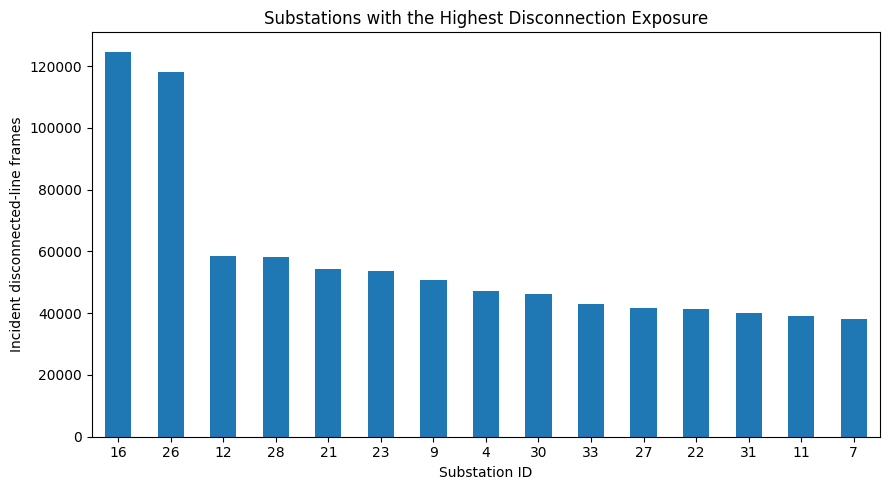

Saved figure: F:\T2530913-code\eda_outputs\figures\substation_degree_versus_recorded_fault_location_frequency_01.png


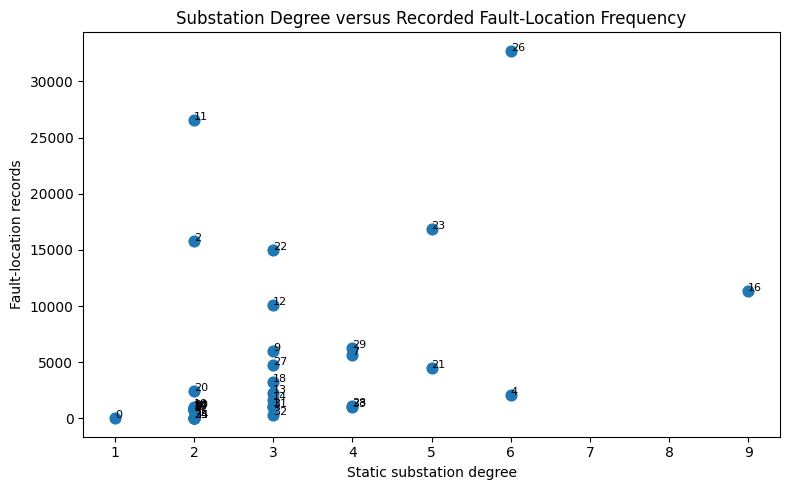

In [76]:
# EDA 68: SUBSTATION-LEVEL HOTSPOT, CENTRALITY, AND EXPOSURE ANALYSIS

static_multigraph = nx.MultiGraph()

static_multigraph.add_nodes_from(
    range(
        N_SUB
    )
)

static_multigraph.add_edges_from(
    zip(
        LINE_OR_BUS.tolist(),
        LINE_EX_BUS.tolist(),
    )
)

static_graph = nx.Graph(
    static_multigraph
)

degree_map = dict(
    static_graph.degree()
)

betweenness_map = nx.betweenness_centrality(
    static_graph,
    normalized=True,
)

closeness_map = nx.closeness_centrality(
    static_graph
)

articulation_points = set(
    nx.articulation_points(
        static_graph
    )
)

load_counts = np.bincount(
    np.asarray(
        metadata[
            "topology"
        ][
            "load_to_sub"
        ],
        dtype=int,
    ),
    minlength=N_SUB,
)

generator_counts = np.bincount(
    np.asarray(
        metadata[
            "topology"
        ][
            "gen_to_sub"
        ],
        dtype=int,
    ),
    minlength=N_SUB,
)

substation_overload_endpoint_frames = np.zeros(
    N_SUB,
    dtype=np.float64,
)

substation_disconnect_endpoint_frames = np.zeros(
    N_SUB,
    dtype=np.float64,
)

substation_cascade_disconnect_endpoint_frames = np.zeros(
    N_SUB,
    dtype=np.float64,
)

np.add.at(
    substation_overload_endpoint_frames,
    LINE_OR_BUS,
    line_level_table[
        "overload_frames"
    ].to_numpy(
        dtype=float
    ),
)

np.add.at(
    substation_overload_endpoint_frames,
    LINE_EX_BUS,
    line_level_table[
        "overload_frames"
    ].to_numpy(
        dtype=float
    ),
)

np.add.at(
    substation_disconnect_endpoint_frames,
    LINE_OR_BUS,
    line_level_table[
        "disconnected_frames"
    ].to_numpy(
        dtype=float
    ),
)

np.add.at(
    substation_disconnect_endpoint_frames,
    LINE_EX_BUS,
    line_level_table[
        "disconnected_frames"
    ].to_numpy(
        dtype=float
    ),
)

np.add.at(
    substation_cascade_disconnect_endpoint_frames,
    LINE_OR_BUS,
    line_level_table[
        "cascade_disconnect_frames"
    ].to_numpy(
        dtype=float
    ),
)

np.add.at(
    substation_cascade_disconnect_endpoint_frames,
    LINE_EX_BUS,
    line_level_table[
        "cascade_disconnect_frames"
    ].to_numpy(
        dtype=float
    ),
)

fault_location_counts = (
    df
    .loc[
        df[
            "fault_loc"
        ]
        >= 0,
        "fault_loc",
    ]
    .astype(
        int
    )
    .value_counts()
    .reindex(
        range(
            N_SUB
        ),
        fill_value=0,
    )
)

substation_hotspot_table = pd.DataFrame({
    "substation_id": np.arange(
        N_SUB,
        dtype=int,
    ),
    "static_degree": [
        degree_map.get(
            node,
            0,
        )
        for node in range(
            N_SUB
        )
    ],
    "attached_load_count": load_counts,
    "attached_generator_count": generator_counts,
    "betweenness_centrality": [
        betweenness_map.get(
            node,
            0.0,
        )
        for node in range(
            N_SUB
        )
    ],
    "closeness_centrality": [
        closeness_map.get(
            node,
            0.0,
        )
        for node in range(
            N_SUB
        )
    ],
    "is_articulation_point": [
        node in articulation_points
        for node in range(
            N_SUB
        )
    ],
    "fault_location_records": (
        fault_location_counts
        .to_numpy(
            dtype=int
        )
    ),
    "overload_endpoint_frames": (
        substation_overload_endpoint_frames
    ),
    "disconnect_endpoint_frames": (
        substation_disconnect_endpoint_frames
    ),
    "cascade_disconnect_endpoint_frames": (
        substation_cascade_disconnect_endpoint_frames
    ),
})

substation_hotspot_table[
    "disconnect_exposure_per_attached_line"
] = (
    substation_hotspot_table[
        "disconnect_endpoint_frames"
    ]
    / substation_hotspot_table[
        "static_degree"
    ].replace(
        0,
        np.nan,
    )
)

substation_hotspot_ranked = (
    substation_hotspot_table
    .sort_values(
        [
            "disconnect_endpoint_frames",
            "cascade_disconnect_endpoint_frames",
            "overload_endpoint_frames",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
)

store_table(
    "68_substation_hotspot_profile",
    substation_hotspot_ranked.round(
        6
    ),
)

plot_bar(
    substation_hotspot_table
    .nlargest(
        15,
        "disconnect_endpoint_frames",
    )
    .set_index(
        "substation_id"
    )[
        "disconnect_endpoint_frames"
    ],
    "Substations with the Highest Disconnection Exposure",
    "Substation ID",
    "Incident disconnected-line frames",
)

plt.figure(
    figsize=(
        8,
        5,
    )
)

plt.scatter(
    substation_hotspot_table[
        "static_degree"
    ],
    substation_hotspot_table[
        "fault_location_records"
    ],
    s=60,
)

for _, row in substation_hotspot_table.iterrows():
    plt.annotate(
        str(
            int(
                row[
                    "substation_id"
                ]
            )
        ),
        (
            row[
                "static_degree"
            ],
            row[
                "fault_location_records"
            ],
        ),
        fontsize=8,
    )

plt.xlabel(
    "Static substation degree"
)

plt.ylabel(
    "Fault-location records"
)

plt.title(
    "Substation Degree versus Recorded Fault-Location Frequency"
)

plt.tight_layout()
plt.show()

## **K. Dynamic Connectivity and Temporal Behaviour**

,record_index,label,active_lines,disconnected_lines,connected_components,largest_component_size,largest_component_fraction,isolated_substations,dynamic_density,disconnected_static_bridge_lines,is_fragmented
0,260570,overload,59,0,1,36,1.0,0,0.087302,0,False
1,131539,overload,58,1,1,36,1.0,0,0.085714,0,False
2,155216,overload,57,2,1,36,1.0,0,0.085714,0,False
3,257689,overload,58,1,1,36,1.0,0,0.085714,0,False
4,244804,overload,57,2,1,36,1.0,0,0.084127,0,False
5,140581,overload,57,2,1,36,1.0,0,0.084127,0,False
6,252970,overload,58,1,1,36,1.0,0,0.085714,0,False
7,219891,overload,57,2,1,36,1.0,0,0.085714,0,False
8,258344,overload,58,1,1,36,1.0,0,0.085714,0,False
9,232664,overload,57,2,1,36,1.0,0,0.084127,0,False


Saved table: F:\T2530913-code\eda_outputs\tables\69_dynamic_connectivity_detail.csv


,sampled_graphs,mean_active_lines,mean_disconnected_lines,mean_connected_components,max_connected_components,mean_largest_component_fraction,mean_isolated_substations,fragmentation_rate_pct,mean_disconnected_static_bridge_lines
label,,,,,,,,,
normal,1639,59.000000,0.000000,1.000000,1,1.000000,0.000000,0.000000,0.00000
overload,2761,57.106121,1.893879,1.000724,2,0.999980,0.000724,0.072438,0.00000
line_trip,2000,58.000000,1.000000,1.000000,1,1.000000,0.000000,0.000000,0.00000
cascade,1600,52.581875,6.418125,3.493750,36,0.930729,2.565000,7.125000,0.07125


Saved table: F:\T2530913-code\eda_outputs\tables\69_dynamic_connectivity_by_class.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\mean_number_of_connected_components_by_operational_state_01.png


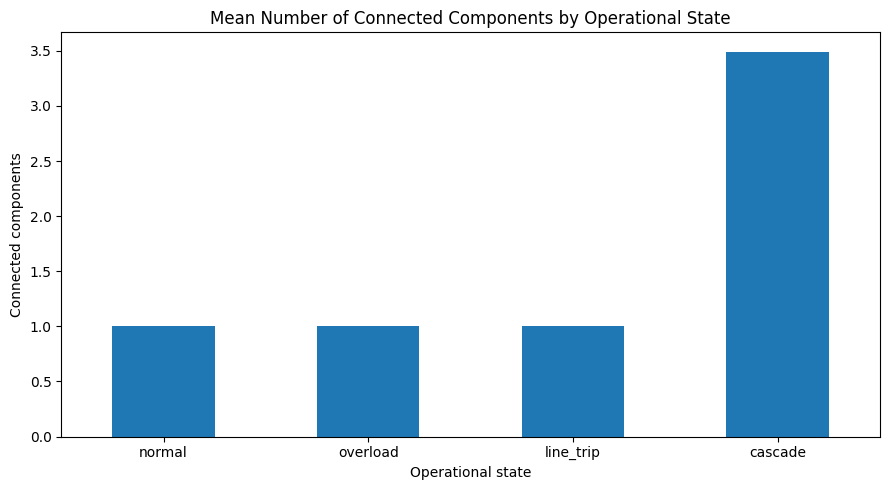

Saved figure: F:\T2530913-code\eda_outputs\figures\mean_number_of_isolated_substations_by_operational_state_01.png


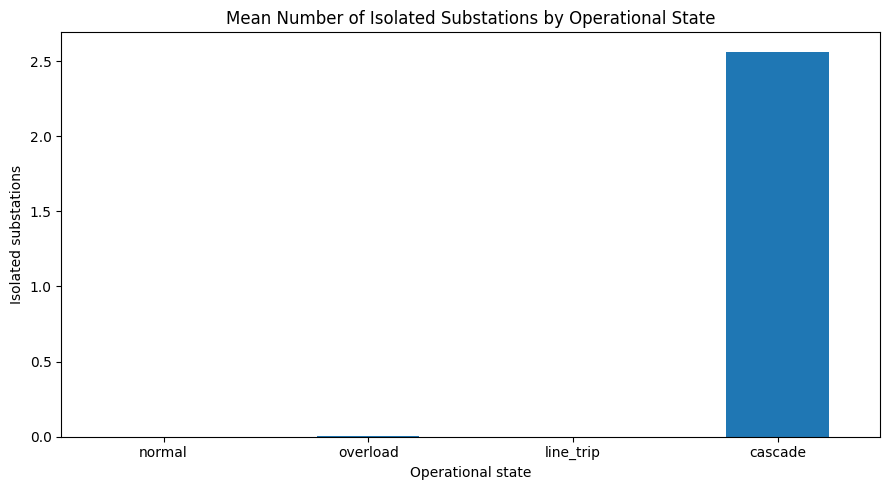

In [77]:
# EDA 69: DYNAMIC GRAPH-CONNECTIVITY AND ISLANDING ANALYSIS

dynamic_indices = sampled_record_indices(
    df,
    n=EXTENDED_SAMPLE_SIZE,
)

dynamic_records = load_records_by_indices(
    JSONL_PATH,
    dynamic_indices,
)

static_pair_multiplicity = Counter(
    canonical_edge(
        origin,
        extremity,
    )
    for origin, extremity in zip(
        LINE_OR_BUS,
        LINE_EX_BUS,
    )
)

static_simple_graph = nx.Graph()

static_simple_graph.add_nodes_from(
    range(
        N_SUB
    )
)

static_simple_graph.add_edges_from(
    canonical_edge(
        origin,
        extremity,
    )
    for origin, extremity in zip(
        LINE_OR_BUS,
        LINE_EX_BUS,
    )
)

# A bridge pair is counted only when one physical transmission line
# represents the endpoint pair.
static_bridge_pairs = {
    canonical_edge(
        origin,
        extremity,
    )
    for origin, extremity in nx.bridges(
        static_simple_graph
    )
    if static_pair_multiplicity[
        canonical_edge(
            origin,
            extremity,
        )
    ]
    == 1
}

dynamic_rows = []

for record_index in dynamic_indices:
    record = dynamic_records[
        record_index
    ]

    line_status = safe_array(
        record,
        "line_status",
        expected_length=N_LINE,
        dtype=int,
    )

    active_line_ids = np.flatnonzero(
        line_status == 1
    )

    disconnected_line_ids = np.flatnonzero(
        line_status == 0
    )

    graph = nx.Graph()

    graph.add_nodes_from(
        range(
            N_SUB
        )
    )

    graph.add_edges_from(
        (
            int(
                LINE_OR_BUS[
                    line_id
                ]
            ),
            int(
                LINE_EX_BUS[
                    line_id
                ]
            ),
        )
        for line_id in active_line_ids
    )

    components = list(
        nx.connected_components(
            graph
        )
    )

    component_sizes = sorted(
        (
            len(
                component
            )
            for component in components
        ),
        reverse=True,
    )

    disconnected_static_bridge_lines = sum(
        canonical_edge(
            LINE_OR_BUS[
                line_id
            ],
            LINE_EX_BUS[
                line_id
            ],
        )
        in static_bridge_pairs
        for line_id in disconnected_line_ids
    )

    dynamic_rows.append({
        "record_index": int(
            record_index
        ),
        "label": str(
            record.get(
                "label"
            )
        ),
        "active_lines": int(
            len(
                active_line_ids
            )
        ),
        "disconnected_lines": int(
            len(
                disconnected_line_ids
            )
        ),
        "connected_components": int(
            len(
                components
            )
        ),
        "largest_component_size": (
            int(
                component_sizes[
                    0
                ]
            )
            if component_sizes
            else 0
        ),
        "largest_component_fraction": (
            float(
                component_sizes[
                    0
                ]
                / N_SUB
            )
            if component_sizes
            else 0.0
        ),
        "isolated_substations": int(
            len(
                list(
                    nx.isolates(
                        graph
                    )
                )
            )
        ),
        "dynamic_density": float(
            nx.density(
                graph
            )
        ),
        "disconnected_static_bridge_lines": int(
            disconnected_static_bridge_lines
        ),
        "is_fragmented": bool(
            len(
                components
            )
            > 1
        ),
    })


dynamic_connectivity_detail = pd.DataFrame(
    dynamic_rows
)

store_table(
    "69_dynamic_connectivity_detail",
    dynamic_connectivity_detail.head(
        50
    ),
)

dynamic_connectivity_by_class = (
    dynamic_connectivity_detail
    .groupby(
        "label",
        observed=False,
    )
    .agg(
        sampled_graphs=(
            "record_index",
            "size",
        ),
        mean_active_lines=(
            "active_lines",
            "mean",
        ),
        mean_disconnected_lines=(
            "disconnected_lines",
            "mean",
        ),
        mean_connected_components=(
            "connected_components",
            "mean",
        ),
        max_connected_components=(
            "connected_components",
            "max",
        ),
        mean_largest_component_fraction=(
            "largest_component_fraction",
            "mean",
        ),
        mean_isolated_substations=(
            "isolated_substations",
            "mean",
        ),
        fragmentation_rate_pct=(
            "is_fragmented",
            lambda values: (
                100
                * values.mean()
            ),
        ),
        mean_disconnected_static_bridge_lines=(
            "disconnected_static_bridge_lines",
            "mean",
        ),
    )
    .reindex(
        LABEL_ORDER
    )
    .round(
        6
    )
)

store_table(
    "69_dynamic_connectivity_by_class",
    dynamic_connectivity_by_class,
)

plot_bar(
    dynamic_connectivity_detail
    .groupby(
        "label",
        observed=False,
    )[
        "connected_components"
    ]
    .mean()
    .reindex(
        LABEL_ORDER
    ),
    "Mean Number of Connected Components by Operational State",
    "Operational state",
    "Connected components",
)

plot_bar(
    dynamic_connectivity_detail
    .groupby(
        "label",
        observed=False,
    )[
        "isolated_substations"
    ]
    .mean()
    .reindex(
        LABEL_ORDER
    ),
    "Mean Number of Isolated Substations by Operational State",
    "Operational state",
    "Isolated substations",
)

,records,observed_episodes,first_record_index,last_record_index,minimum_timestep,maximum_timestep,mean_max_rho,mean_disconnected_lines,normal_records,overload_records,line_trip_records,cascade_records
chronic_id,,,,,,,,,,,,
0,110,1,0,109,5,288,0.760694,1.581818,5,8,91,6
1,169,1,110,278,5,523,0.748428,1.497041,10,5,117,37
2,14,1,279,292,10,55,1.008869,5.571429,0,6,7,1
3,40,1,293,332,1,288,0.643014,2.425000,6,1,27,6
4,54,1,333,386,4,254,0.697475,2.037037,5,0,45,4
...,...,...,...,...,...,...,...,...,...,...,...,...
28381,7,1,299970,299976,2,224,1.176950,1.142857,3,4,0,0
28382,9,1,299977,299985,12,103,1.218326,0.888889,1,8,0,0
28383,7,1,299986,299992,0,62,0.933924,0.857143,3,4,0,0


Saved table: F:\T2530913-code\eda_outputs\tables\70_chronic_level_summary.csv


next_label,normal,overload,line_trip,cascade
label_str,,,,
normal,34343,19279,2526,1412
overload,7821,72002,697,4471
line_trip,2437,1703,68014,2846
cascade,1089,1537,2566,50652


Saved table: F:\T2530913-code\eda_outputs\tables\70_state_transition_counts.csv


next_label,normal,overload,line_trip,cascade
label_str,,,,
normal,0.596647,0.334937,0.043885,0.024531
overload,0.092022,0.847172,0.008201,0.052606
line_trip,0.032493,0.022707,0.906853,0.037947
cascade,0.019501,0.027523,0.045949,0.907027


Saved table: F:\T2530913-code\eda_outputs\tables\70_state_transition_probabilities.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\observed_state_transition_probability_matrix_01.png


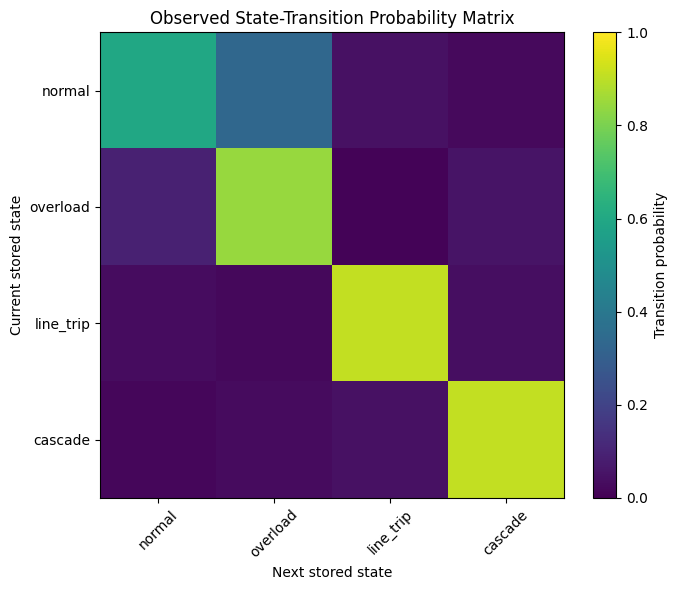

,observed_runs,median_stored_frames,mean_stored_frames,median_observed_timestep_span,mean_observed_timestep_span,maximum_observed_timestep_span
label_str,,,,,,
normal,27101,2.0,2.267223,7.0,50.845024,994
overload,31554,2.0,3.281866,2.0,12.464759,620
line_trip,6986,7.0,10.735757,10.0,21.495992,241
cascade,9348,2.0,6.418485,2.0,9.852589,328


Saved table: F:\T2530913-code\eda_outputs\tables\70_state_run_duration_summary.csv


,count,mean,median,min,max
label_str,,,,,
overload,7821,47.625240,34.0,1.0,486.0
line_trip,2437,13.729175,10.0,1.0,99.0
cascade,1089,35.932048,27.0,2.0,225.0


Saved table: F:\T2530913-code\eda_outputs\tables\70_observed_recovery_gap_summary.csv


,metric,value
0,lag-1 max_rho autocorrelation within episodes,0.63266


Saved table: F:\T2530913-code\eda_outputs\tables\70_lag1_rho_autocorrelation.csv


,metric,value
0,lag-1 max_rho autocorrelation within episodes,0.63266


In [78]:
# EDA 70: TEMPORAL, CHRONIC-LEVEL, STATE-PERSISTENCE, AND RECOVERY ANALYSIS

temporal = (
    df
    .sort_values(
        "record_index"
    )
    .copy()
)

temporal[
    "label_str"
] = temporal[
    "label"
].astype(
    str
)

previous_chronic = temporal[
    "chronic_id"
].shift(
    1
)

previous_timestep = temporal[
    "timestep"
].shift(
    1
)

new_episode = (
    temporal[
        "chronic_id"
    ].ne(
        previous_chronic
    )
    | temporal[
        "timestep"
    ].le(
        previous_timestep
    )
    | previous_timestep.isna()
)

temporal[
    "episode_id"
] = new_episode.cumsum().astype(
    int
)

chronic_summary = (
    temporal
    .groupby(
        "chronic_id",
        observed=False,
    )
    .agg(
        records=(
            "record_index",
            "size",
        ),
        observed_episodes=(
            "episode_id",
            "nunique",
        ),
        first_record_index=(
            "record_index",
            "min",
        ),
        last_record_index=(
            "record_index",
            "max",
        ),
        minimum_timestep=(
            "timestep",
            "min",
        ),
        maximum_timestep=(
            "timestep",
            "max",
        ),
        mean_max_rho=(
            "max_rho",
            "mean",
        ),
        mean_disconnected_lines=(
            "disconnected_lines",
            "mean",
        ),
    )
)

for label in LABEL_ORDER:
    chronic_summary[
        f"{label}_records"
    ] = (
        temporal
        .assign(
            is_label=temporal[
                "label_str"
            ].eq(
                label
            )
        )
        .groupby(
            "chronic_id"
        )[
            "is_label"
        ]
        .sum()
    )

store_table(
    "70_chronic_level_summary",
    chronic_summary.round(
        6
    ),
)

temporal[
    "next_episode_id"
] = temporal[
    "episode_id"
].shift(
    -1
)

temporal[
    "next_label"
] = temporal[
    "label_str"
].shift(
    -1
)

valid_transition_mask = temporal[
    "episode_id"
].eq(
    temporal[
        "next_episode_id"
    ]
)

transition_counts = pd.crosstab(
    temporal.loc[
        valid_transition_mask,
        "label_str",
    ],
    temporal.loc[
        valid_transition_mask,
        "next_label",
    ],
).reindex(
    index=LABEL_ORDER,
    columns=LABEL_ORDER,
    fill_value=0,
)

transition_probabilities = (
    transition_counts
    .div(
        transition_counts
        .sum(
            axis=1
        )
        .replace(
            0,
            np.nan,
        ),
        axis=0,
    )
    .fillna(
        0.0
    )
    .round(
        6
    )
)

store_table(
    "70_state_transition_counts",
    transition_counts,
)

store_table(
    "70_state_transition_probabilities",
    transition_probabilities,
)

plt.figure(
    figsize=(
        7,
        6,
    )
)

plt.imshow(
    transition_probabilities,
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

plt.colorbar(
    label="Transition probability"
)

plt.xticks(
    range(
        len(
            LABEL_ORDER
        )
    ),
    LABEL_ORDER,
    rotation=45,
)

plt.yticks(
    range(
        len(
            LABEL_ORDER
        )
    ),
    LABEL_ORDER,
)

plt.xlabel(
    "Next stored state"
)

plt.ylabel(
    "Current stored state"
)

plt.title(
    "Observed State-Transition Probability Matrix"
)

plt.tight_layout()
plt.show()

run_boundary = (
    temporal[
        "episode_id"
    ].ne(
        temporal[
            "episode_id"
        ].shift(
            1
        )
    )
    | temporal[
        "label_str"
    ].ne(
        temporal[
            "label_str"
        ].shift(
            1
        )
    )
)

temporal[
    "run_id"
] = run_boundary.cumsum().astype(
    int
)

state_runs = (
    temporal
    .groupby(
        [
            "episode_id",
            "run_id",
            "label_str",
        ],
        observed=False,
    )
    .agg(
        stored_frames=(
            "record_index",
            "size",
        ),
        start_record_index=(
            "record_index",
            "min",
        ),
        end_record_index=(
            "record_index",
            "max",
        ),
        start_timestep=(
            "timestep",
            "min",
        ),
        end_timestep=(
            "timestep",
            "max",
        ),
        maximum_rho=(
            "max_rho",
            "max",
        ),
        maximum_disconnected_lines=(
            "disconnected_lines",
            "max",
        ),
    )
    .reset_index()
)

state_runs[
    "observed_timestep_span"
] = (
    state_runs[
        "end_timestep"
    ]
    - state_runs[
        "start_timestep"
    ]
    + 1
)

run_summary = (
    state_runs
    .groupby(
        "label_str",
        observed=False,
    )
    .agg(
        observed_runs=(
            "run_id",
            "size",
        ),
        median_stored_frames=(
            "stored_frames",
            "median",
        ),
        mean_stored_frames=(
            "stored_frames",
            "mean",
        ),
        median_observed_timestep_span=(
            "observed_timestep_span",
            "median",
        ),
        mean_observed_timestep_span=(
            "observed_timestep_span",
            "mean",
        ),
        maximum_observed_timestep_span=(
            "observed_timestep_span",
            "max",
        ),
    )
    .reindex(
        LABEL_ORDER
    )
    .round(
        6
    )
)

store_table(
    "70_state_run_duration_summary",
    run_summary,
)

state_runs[
    "next_episode_id"
] = state_runs[
    "episode_id"
].shift(
    -1
)

state_runs[
    "next_label"
] = state_runs[
    "label_str"
].shift(
    -1
)

state_runs[
    "next_start_timestep"
] = state_runs[
    "start_timestep"
].shift(
    -1
)

recovery_runs = state_runs[
    state_runs[
        "label_str"
    ].isin(
        [
            "overload",
            "line_trip",
            "cascade",
        ]
    )
    & state_runs[
        "episode_id"
    ].eq(
        state_runs[
            "next_episode_id"
        ]
    )
    & state_runs[
        "next_label"
    ].eq(
        "normal"
    )
].copy()

recovery_runs[
    "observed_recovery_gap"
] = (
    recovery_runs[
        "next_start_timestep"
    ]
    - recovery_runs[
        "end_timestep"
    ]
)

recovery_summary = (
    recovery_runs
    .groupby(
        "label_str",
        observed=False,
    )[
        "observed_recovery_gap"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
    ])
    .reindex(
        [
            "overload",
            "line_trip",
            "cascade",
        ]
    )
    .round(
        6
    )
)

store_table(
    "70_observed_recovery_gap_summary",
    recovery_summary,
)

lag_pairs = temporal[
    temporal[
        "episode_id"
    ].eq(
        temporal[
            "episode_id"
        ].shift(
            -1
        )
    )
][[
    "max_rho"
]].copy()

lag_pairs[
    "next_max_rho"
] = temporal[
    "max_rho"
].shift(
    -1
)

lag1_autocorrelation = lag_pairs[
    "max_rho"
].corr(
    lag_pairs[
        "next_max_rho"
    ]
)

store_table(
    "70_lag1_rho_autocorrelation",
    pd.DataFrame({
        "metric": [
            "lag-1 max_rho autocorrelation within episodes"
        ],
        "value": [
            lag1_autocorrelation
        ],
    }).round(
        6
    ),
)

## **L. Split Integrity, Generator Bias, and Feature-Selection Justification**

In [79]:
# EDA 71: ACTUAL SAVED SPLIT-FILE AUDIT

from scipy.stats import ks_2samp

SPLIT_PATHS = {
    "train": Path(
        "data/split_neurips2020_train_idx.npy"
    ),
    "validation": Path(
        "data/split_neurips2020_val_idx.npy"
    ),
    "test": Path(
        "data/split_neurips2020_test_idx.npy"
    ),
}

missing_split_files = [
    str(
        path
    )
    for path in SPLIT_PATHS.values()
    if not path.exists()
]

if missing_split_files:
    print(
        "The saved split files were not found:"
    )

    for missing_file in missing_split_files:
        print(
            " -",
            missing_file,
        )

    print(
        "\nGenerate them first with:\n"
        "python scripts/split.py "
        "--input data/grid_dataset_neurips2020.jsonl "
        "--output_prefix split_neurips2020"
    )

else:
    split_indices = {
        split_name: np.load(
            path
        ).astype(
            int
        )
        for split_name, path in SPLIT_PATHS.items()
    }

    indexed_df = df.set_index(
        "record_index",
        drop=False,
    )

    split_frames = {}
    missing_index_rows = []

    for split_name, indices in split_indices.items():
        available_mask = np.isin(
            indices,
            indexed_df.index.to_numpy(),
        )

        missing_count = int(
            (
                ~available_mask
            ).sum()
        )

        missing_index_rows.append({
            "split": split_name,
            "saved_indices": int(
                len(
                    indices
                )
            ),
            "indices_found_in_loaded_dataframe": int(
                available_mask.sum()
            ),
            "indices_missing_from_loaded_dataframe": (
                missing_count
            ),
            "unique_indices": int(
                len(
                    np.unique(
                        indices
                    )
                )
            ),
            "duplicate_indices_inside_split": int(
                len(
                    indices
                )
                - len(
                    np.unique(
                        indices
                    )
                )
            ),
        })

        split_frames[
            split_name
        ] = (
            indexed_df
            .reindex(
                indices
            )
            .dropna(
                subset=[
                    "record_index"
                ]
            )
            .copy()
        )

    store_table(
        "71_split_index_integrity",
        pd.DataFrame(
            missing_index_rows
        ),
    )

    split_distribution_rows = []

    for split_name, frame in split_frames.items():
        label_counts = (
            frame[
                "label"
            ]
            .astype(
                str
            )
            .value_counts()
            .reindex(
                LABEL_ORDER,
                fill_value=0,
            )
        )

        for label in LABEL_ORDER:
            split_distribution_rows.append({
                "split": split_name,
                "label": label,
                "records": int(
                    label_counts[
                        label
                    ]
                ),
                "percentage_within_split": (
                    100
                    * int(
                        label_counts[
                            label
                        ]
                    )
                    / max(
                        len(
                            frame
                        ),
                        1,
                    )
                ),
            })

    split_distribution_table = pd.DataFrame(
        split_distribution_rows
    )

    store_table(
        "71_actual_split_class_distribution",
        split_distribution_table.round(
            6
        ),
    )

    split_names = list(
        split_frames
    )

    overlap_rows = []

    for first_split, second_split in combinations(
        split_names,
        2,
    ):
        first_indices = set(
            split_indices[
                first_split
            ].tolist()
        )

        second_indices = set(
            split_indices[
                second_split
            ].tolist()
        )

        first_chronics = set(
            split_frames[
                first_split
            ][
                "chronic_id"
            ].astype(
                int
            )
        )

        second_chronics = set(
            split_frames[
                second_split
            ][
                "chronic_id"
            ].astype(
                int
            )
        )

        overlap_rows.append({
            "first_split": first_split,
            "second_split": second_split,
            "shared_record_indices": len(
                first_indices.intersection(
                    second_indices
                )
            ),
            "shared_chronics": len(
                first_chronics.intersection(
                    second_chronics
                )
            ),
            "first_split_chronics": len(
                first_chronics
            ),
            "second_split_chronics": len(
                second_chronics
            ),
        })

    store_table(
        "71_split_record_and_chronic_overlap",
        pd.DataFrame(
            overlap_rows
        ),
    )

    fingerprint_columns = [
        "label",
        "max_rho",
        "mean_rho",
        "std_rho",
        "total_load",
        "total_gen",
        "connected_lines",
        "disconnected_lines",
        "fault_loc",
        "timestep",
        "chronic_id",
    ]

    def aggregate_fingerprint_set(
        frame,
        decimals=None,
    ):
        fingerprint_frame = frame[
            fingerprint_columns
        ].copy()

        numeric_columns = (
            fingerprint_frame
            .select_dtypes(
                include=[
                    np.number
                ]
            )
            .columns
        )

        if decimals is not None:
            fingerprint_frame[
                numeric_columns
            ] = fingerprint_frame[
                numeric_columns
            ].round(
                decimals
            )

        hashed = pd.util.hash_pandas_object(
            fingerprint_frame,
            index=False,
        ).astype(
            str
        )

        return set(
            hashed.tolist()
        )

    exact_fingerprints = {
        split_name: aggregate_fingerprint_set(
            frame,
            decimals=None,
        )
        for split_name, frame in split_frames.items()
    }

    near_fingerprints = {
        split_name: aggregate_fingerprint_set(
            frame,
            decimals=3,
        )
        for split_name, frame in split_frames.items()
    }

    fingerprint_overlap_rows = []

    for first_split, second_split in combinations(
        split_names,
        2,
    ):
        fingerprint_overlap_rows.append({
            "first_split": first_split,
            "second_split": second_split,
            "exact_aggregate_fingerprint_overlap": len(
                exact_fingerprints[
                    first_split
                ].intersection(
                    exact_fingerprints[
                        second_split
                    ]
                )
            ),
            "rounded_near_duplicate_overlap": len(
                near_fingerprints[
                    first_split
                ].intersection(
                    near_fingerprints[
                        second_split
                    ]
                )
            ),
        })

    store_table(
        "71_split_duplicate_and_near_duplicate_overlap",
        pd.DataFrame(
            fingerprint_overlap_rows
        ),
    )

    drift_features = [
        "max_rho",
        "mean_rho",
        "total_load",
        "total_gen",
        "connected_lines",
        "disconnected_lines",
    ]

    drift_rows = []

    for first_split, second_split in combinations(
        split_names,
        2,
    ):
        for feature in drift_features:
            statistic, p_value = ks_2samp(
                split_frames[
                    first_split
                ][
                    feature
                ],
                split_frames[
                    second_split
                ][
                    feature
                ],
            )

            drift_rows.append({
                "first_split": first_split,
                "second_split": second_split,
                "feature": feature,
                "ks_statistic": statistic,
                "p_value": p_value,
            })

    store_table(
        "71_split_distribution_drift_ks_tests",
        pd.DataFrame(
            drift_rows
        ).round(
            8
        ),
    )

The saved split files were not found:
 - data\split_neurips2020_train_idx.npy
 - data\split_neurips2020_val_idx.npy
 - data\split_neurips2020_test_idx.npy

Generate them first with:
python scripts/split.py --input data/grid_dataset_neurips2020.jsonl --output_prefix split_neurips2020


label_str,normal,overload,line_trip,cascade
generation_bin,,,,
00-10%,3.593333,5.663333,66.670000,24.073333
10-20%,3.650000,6.370000,65.826667,24.153333
20-30%,3.466667,6.626667,65.293333,24.613333
30-40%,5.240000,8.876667,52.210000,33.673333
40-50%,10.426667,17.786667,0.000000,71.786667
50-60%,28.763333,49.536667,0.000000,21.700000
60-70%,37.540000,62.460000,0.000000,0.000000
70-80%,37.176667,62.823333,0.000000,0.000000
80-90%,37.223333,62.776667,0.000000,0.000000


Saved table: F:\T2530913-code\eda_outputs\tables\72_generation_decile_class_percentages.csv


,records,unique_chronics,mean_max_rho,mean_disconnected_lines,mean_connected_fraction,first_record_index,last_record_index
generation_bin,,,,,,,
00-10%,30000,484,0.775748,2.254300,0.961792,0,29999
10-20%,30000,504,0.777441,2.294667,0.961107,30000,59999
20-30%,30000,565,0.783178,2.428400,0.958841,60000,89999
30-40%,30000,735,0.791117,2.875467,0.951263,90000,119999
40-50%,30000,1455,0.826699,4.765200,0.919234,120000,149999
50-60%,30000,3800,1.012188,2.232900,0.962154,150000,179999
60-70%,30000,4733,1.090323,1.187567,0.979872,180000,209999
70-80%,30000,4779,1.092377,1.185900,0.979900,210000,239999
80-90%,30000,4810,1.092278,1.184433,0.979925,240000,269999


Saved table: F:\T2530913-code\eda_outputs\tables\72_generation_decile_summary.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\class_composition_across_the_dataset_generation_process_01.png


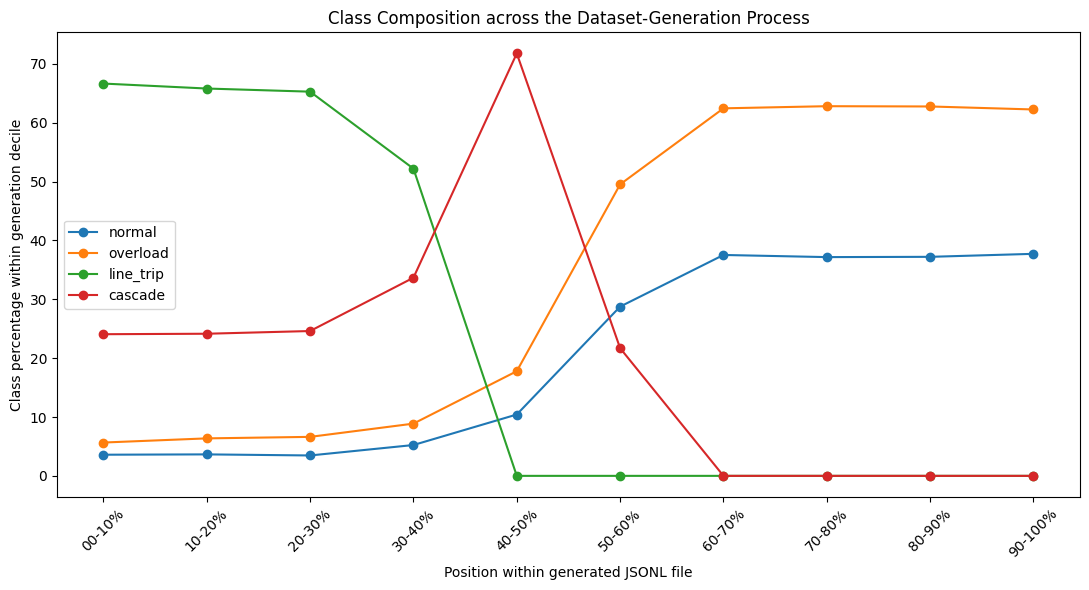

,label,configured_cap_records,final_records,cap_reached,first_dataset_position_where_cap_was_reached,first_record_index_where_cap_was_reached
0,normal,105000,61444,False,NaN,NaN
1,line_trip,75000,75000,True,113718.0,113718.0
2,cascade,60000,60000,True,158991.0,158991.0


Saved table: F:\T2530913-code\eda_outputs\tables\72_generation_quota_saturation.csv
Saved figure: F:\T2530913-code\eda_outputs\figures\cumulative_class_counts_and_configured_sampling_caps_01.png


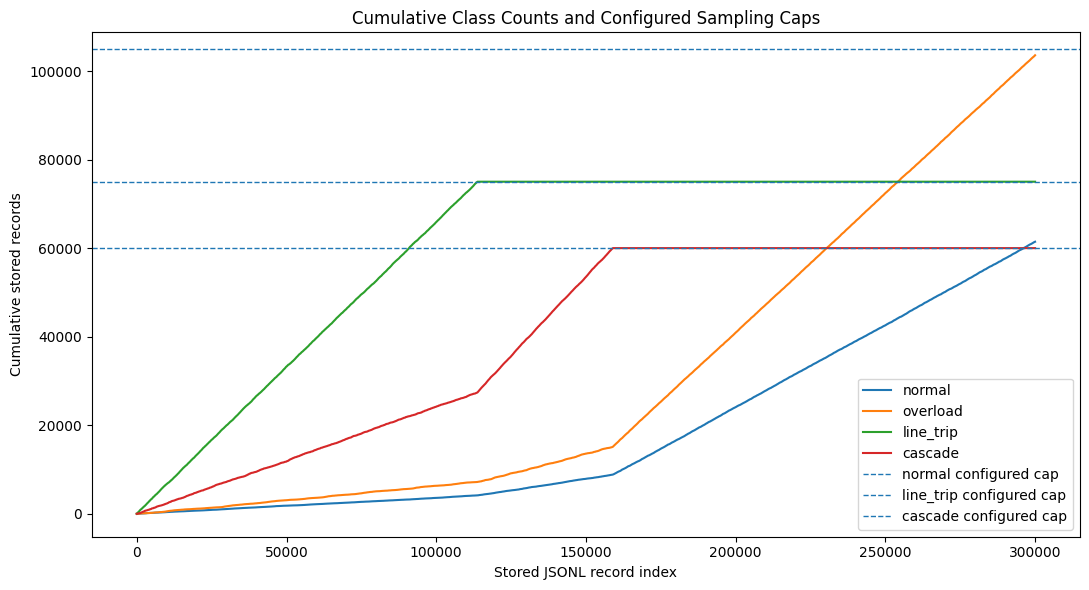

In [ ]:
# EDA 72: GENERATOR-SAMPLING BIAS AND QUOTA-SATURATION ANALYSIS

ordered_generation = (
    df
    .sort_values(
        "record_index"
    )
    .copy()
)

ordered_generation[
    "label_str"
] = ordered_generation[
    "label"
].astype(
    str
)

generation_bin_labels = [
    f"{10 * i:02d}-{10 * (i + 1):02d}%"
    for i in range(
        10
    )
]

ordered_generation[
    "generation_bin"
] = pd.qcut(
    ordered_generation[
        "record_index"
    ].rank(
        method="first"
    ),
    q=10,
    labels=generation_bin_labels,
)

generation_distribution = (
    pd.crosstab(
        ordered_generation[
            "generation_bin"
        ],
        ordered_generation[
            "label_str"
        ],
        normalize="index",
    )
    .reindex(
        columns=LABEL_ORDER,
        fill_value=0.0,
    )
    * 100
)

store_table(
    "72_generation_decile_class_percentages",
    generation_distribution.round(
        6
    ),
)

generation_bin_summary = (
    ordered_generation
    .groupby(
        "generation_bin",
        observed=False,
    )
    .agg(
        records=(
            "record_index",
            "size",
        ),
        unique_chronics=(
            "chronic_id",
            "nunique",
        ),
        mean_max_rho=(
            "max_rho",
            "mean",
        ),
        mean_disconnected_lines=(
            "disconnected_lines",
            "mean",
        ),
        mean_connected_fraction=(
            "connected_fraction",
            "mean",
        ),
        first_record_index=(
            "record_index",
            "min",
        ),
        last_record_index=(
            "record_index",
            "max",
        ),
    )
    .round(
        6
    )
)

store_table(
    "72_generation_decile_summary",
    generation_bin_summary,
)

plt.figure(
    figsize=(
        11,
        6,
    )
)

for label in LABEL_ORDER:
    plt.plot(
        generation_distribution
        .index
        .astype(
            str
        ),
        generation_distribution[
            label
        ],
        marker="o",
        label=label,
    )

plt.xlabel(
    "Position within generated JSONL file"
)

plt.ylabel(
    "Class percentage within generation decile"
)

plt.title(
    "Class Composition across the Dataset-Generation Process"
)

plt.xticks(
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

target_records = int(
    metadata.get(
        "total_records",
        len(
            ordered_generation
        ),
    )
)

configured_caps = {
    "normal": int(
        0.35
        * target_records
    ),
    "line_trip": int(
        0.25
        * target_records
    ),
    "cascade": int(
        0.20
        * target_records
    ),
}

quota_rows = []

for label, configured_cap in configured_caps.items():
    cumulative_count = (
        ordered_generation[
            "label_str"
        ]
        .eq(
            label
        )
        .cumsum()
    )

    reached_positions = np.flatnonzero(
        cumulative_count.to_numpy()
        >= configured_cap
    )

    if len(
        reached_positions
    ):
        first_position = int(
            reached_positions[
                0
            ]
        )

        first_record_index = int(
            ordered_generation
            .iloc[
                first_position
            ][
                "record_index"
            ]
        )

        reached = True

    else:
        first_position = np.nan
        first_record_index = np.nan
        reached = False

    final_count = int(
        ordered_generation[
            "label_str"
        ]
        .eq(
            label
        )
        .sum()
    )

    quota_rows.append({
        "label": label,
        "configured_cap_records": configured_cap,
        "final_records": final_count,
        "cap_reached": reached,
        "first_dataset_position_where_cap_was_reached": (
            first_position
        ),
        "first_record_index_where_cap_was_reached": (
            first_record_index
        ),
    })

quota_table = pd.DataFrame(
    quota_rows
)

store_table(
    "72_generation_quota_saturation",
    quota_table,
)

plt.figure(
    figsize=(
        11,
        6,
    )
)

for label in LABEL_ORDER:
    cumulative_values = (
        ordered_generation[
            "label_str"
        ]
        .eq(
            label
        )
        .cumsum()
    )

    plt.plot(
        ordered_generation[
            "record_index"
        ],
        cumulative_values,
        label=label,
    )

for label, configured_cap in configured_caps.items():
    plt.axhline(
        configured_cap,
        linestyle="--",
        linewidth=1,
        label=f"{label} configured cap",
    )

plt.xlabel(
    "Stored JSONL record index"
)

plt.ylabel(
    "Cumulative stored records"
)

plt.title(
    "Cumulative Class Counts and Configured Sampling Caps"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# EDA 73: RAW-FEATURE COVERAGE AND FEATURE-SELECTION JUSTIFICATION

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

feature_sample_indices = sampled_record_indices(
    df,
    n=FEATURE_JUSTIFICATION_SAMPLE_SIZE,
)

feature_sample_records = load_records_by_indices(
    JSONL_PATH,
    feature_sample_indices,
)

RAW_FIELD_SELECTION = {
    "load_p": True,
    "v_or": True,
    "rho": True,
    "line_status": True,
    "p_or": True,
    "q_or": True,
    "load_q": False,
    "gen_p": False,
    "gen_q": False,
    "p_ex": False,
    "q_ex": False,
    "v_ex": False,
    "topo_vect": False,
}

feature_rows = []

for record_index in feature_sample_indices:
    record = feature_sample_records[
        record_index
    ]

    row = {
        "record_index": int(
            record_index
        ),
        "label": str(
            record.get(
                "label"
            )
        ),
    }

    for field_name in RAW_FIELD_SELECTION:
        values = safe_array(
            record,
            field_name,
            dtype=float,
        )

        if values.size == 0:
            row[
                f"{field_name}__mean"
            ] = 0.0

            row[
                f"{field_name}__std"
            ] = 0.0

            row[
                f"{field_name}__minimum"
            ] = 0.0

            row[
                f"{field_name}__maximum"
            ] = 0.0

            row[
                f"{field_name}__sum"
            ] = 0.0

            row[
                f"{field_name}__abs_mean"
            ] = 0.0

            row[
                f"{field_name}__nonzero_fraction"
            ] = 0.0

            row[
                f"{field_name}__unique_count"
            ] = 0

            continue

        row[
            f"{field_name}__mean"
        ] = float(
            np.mean(
                values
            )
        )

        row[
            f"{field_name}__std"
        ] = float(
            np.std(
                values
            )
        )

        row[
            f"{field_name}__minimum"
        ] = float(
            np.min(
                values
            )
        )

        row[
            f"{field_name}__maximum"
        ] = float(
            np.max(
                values
            )
        )

        row[
            f"{field_name}__sum"
        ] = float(
            np.sum(
                values
            )
        )

        row[
            f"{field_name}__abs_mean"
        ] = float(
            np.mean(
                np.abs(
                    values
                )
            )
        )

        row[
            f"{field_name}__nonzero_fraction"
        ] = float(
            np.mean(
                values
                != 0
            )
        )

        row[
            f"{field_name}__unique_count"
        ] = int(
            np.unique(
                values
            ).size
        )

    feature_rows.append(
        row
    )

raw_feature_proxy_frame = pd.DataFrame(
    feature_rows
)

proxy_feature_columns = [
    column
    for column in raw_feature_proxy_frame.columns
    if column
    not in {
        "record_index",
        "label",
    }
]

X_proxy = (
    raw_feature_proxy_frame[
        proxy_feature_columns
    ]
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
    .fillna(
        0.0
    )
)

y_proxy = raw_feature_proxy_frame[
    "label"
].astype(
    str
)

mutual_information = mutual_info_classif(
    X_proxy,
    y_proxy,
    random_state=RANDOM_STATE,
)

proxy_mi_table = pd.DataFrame({
    "proxy_feature": proxy_feature_columns,
    "mutual_information": mutual_information,
})

proxy_mi_table[
    "raw_field"
] = (
    proxy_mi_table[
        "proxy_feature"
    ]
    .str
    .split(
        "__"
    )
    .str[
        0
    ]
)

proxy_mi_table[
    "selected_by_current_graph_builder"
] = (
    proxy_mi_table[
        "raw_field"
    ]
    .map(
        RAW_FIELD_SELECTION
    )
)

store_table(
    "73_proxy_feature_mutual_information",
    proxy_mi_table
    .sort_values(
        "mutual_information",
        ascending=False,
    )
    .round(
        8
    ),
)

raw_field_justification_table = (
    proxy_mi_table
    .groupby(
        [
            "raw_field",
            "selected_by_current_graph_builder",
        ],
        observed=False,
    )
    .agg(
        maximum_proxy_mutual_information=(
            "mutual_information",
            "max",
        ),
        mean_proxy_mutual_information=(
            "mutual_information",
            "mean",
        ),
        proxy_feature_count=(
            "proxy_feature",
            "size",
        ),
    )
    .reset_index()
    .sort_values(
        "maximum_proxy_mutual_information",
        ascending=False,
    )
    .round(
        8
    )
)

store_table(
    "73_raw_field_selection_justification",
    raw_field_justification_table,
)

selected_proxy_columns = [
    "load_p__sum",
    "v_or__mean",
    "rho__maximum",
    "line_status__mean",
    "p_or__abs_mean",
    "q_or__abs_mean",
]

excluded_proxy_columns = [
    column
    for column in proxy_feature_columns
    if column.split(
        "__"
    )[
        0
    ]
    in {
        field_name
        for field_name, is_selected
        in RAW_FIELD_SELECTION.items()
        if not is_selected
    }
]

def proxy_baseline_score(
    feature_columns
):
    X = X_proxy[
        feature_columns
    ]

    (
        X_train,
        X_test,
        y_train,
        y_test,
    ) = train_test_split(
        X,
        y_proxy,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_proxy,
    )

    model = RandomForestClassifier(
        n_estimators=140,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )

    model.fit(
        X_train,
        y_train,
    )

    prediction = model.predict(
        X_test
    )

    return {
        "feature_count": len(
            feature_columns
        ),
        "macro_f1": f1_score(
            y_test,
            prediction,
            average="macro",
        ),
        "weighted_f1": f1_score(
            y_test,
            prediction,
            average="weighted",
        ),
    }


current_proxy_result = proxy_baseline_score(
    selected_proxy_columns
)

expanded_proxy_result = proxy_baseline_score(
    selected_proxy_columns
    + excluded_proxy_columns
)

feature_coverage_comparison = pd.DataFrame([
    {
        "diagnostic_setting": (
            "current graph-source proxy fields only"
        ),
        **current_proxy_result,
    },
    {
        "diagnostic_setting": (
            "current proxy fields plus excluded raw fields"
        ),
        **expanded_proxy_result,
    },
])

store_table(
    "73_proxy_feature_coverage_comparison",
    feature_coverage_comparison.round(
        8
    ),
)

print(
    "\nInterpretation note:\n"
    "- This cell helps identify which raw fields deserve deeper ablation experiments.\n"
    "- The Random-Forest results are diagnostic proxies only.\n"
    "- A final thesis claim about feature selection should be supported by a true GNN ablation run.\n"
)

,proxy_feature,mutual_information,raw_field,selected_by_current_graph_builder
8,v_or__mean,0.984167,v_or,True
13,v_or__abs_mean,0.984136,v_or,True
12,v_or__sum,0.984104,v_or,True
9,v_or__std,0.972964,v_or,True
89,v_ex__std,0.949642,v_ex,False
...,...,...,...,...
99,topo_vect__maximum,0.023081,topo_vect,False
70,gen_q__nonzero_fraction,0.020166,gen_q,False
101,topo_vect__abs_mean,0.006135,topo_vect,False
58,gen_p__minimum,0.003810,gen_p,False


Saved table: F:\T2530913-code\eda_outputs\tables\73_proxy_feature_mutual_information.csv


,raw_field,selected_by_current_graph_builder,maximum_proxy_mutual_information,mean_proxy_mutual_information,proxy_feature_count
12,v_or,True,0.984167,0.691260,8
11,v_ex,False,0.949642,0.647047,8
2,line_status,True,0.799354,0.606816,8
5,p_ex,False,0.799071,0.212324,8
8,q_or,True,0.797749,0.242475,8
7,q_ex,False,0.797090,0.236800,8
10,topo_vect,False,0.796199,0.406879,8
6,p_or,True,0.796065,0.213032,8
9,rho,True,0.793297,0.393686,8
1,gen_q,False,0.227416,0.092965,8


Saved table: F:\T2530913-code\eda_outputs\tables\73_raw_field_selection_justification.csv


,diagnostic_setting,feature_count,macro_f1,weighted_f1
0,current graph-source proxy fields only,6,0.999862,0.99984
1,current proxy fields plus excluded raw fields,62,0.999569,0.99952


Saved table: F:\T2530913-code\eda_outputs\tables\73_proxy_feature_coverage_comparison.csv

Interpretation note:
- This cell helps identify which raw fields deserve deeper ablation experiments.
- The Random-Forest results are diagnostic proxies only.
- A final thesis claim about feature selection should be supported by a true GNN ablation run.



## **Export Report-Ready Tables**



In [82]:
# EXPORT: SAVE REPORT-READY TABLES, FIGURE PATHS, AND RUN SUMMARY

# 1. Re-export every registered table

for table_name, table in EDA_TABLES.items():

    safe_name = make_safe_filename(
        table_name
    )

    output_path = (
        TABLE_OUTPUT_DIR
        / f"{safe_name}.csv"
    )

    table.to_csv(
        output_path,
        index=True,
    )

    SAVED_TABLE_PATHS[
        table_name
    ] = str(
        output_path.resolve()
    )


# 2. Export the table manifest

table_manifest_path = (
    SUMMARY_OUTPUT_DIR
    / "eda_table_manifest.json"
)

with table_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        SAVED_TABLE_PATHS,
        file,
        indent=2,
    )


# 3. Export the figure manifest

figure_manifest_path = (
    SUMMARY_OUTPUT_DIR
    / "eda_figure_manifest.json"
)

with figure_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        SAVED_FIGURE_PATHS,
        file,
        indent=2,
    )


# 4. Export the complete EDA-run summary

run_summary = {
    "environment": metadata.get(
        "env_name"
    ),
    "records_loaded": int(
        len(
            df
        )
    ),
    "labels": LABEL_ORDER,
    "generated_table_count": int(
        len(
            SAVED_TABLE_PATHS
        )
    ),
    "generated_figure_count": int(
        len(
            SAVED_FIGURE_PATHS
        )
    ),
    "table_output_directory": str(
        TABLE_OUTPUT_DIR.resolve()
    ),
    "figure_output_directory": str(
        FIGURE_OUTPUT_DIR.resolve()
    ),
    "summary_output_directory": str(
        SUMMARY_OUTPUT_DIR.resolve()
    ),
    "generated_tables": sorted(
        SAVED_TABLE_PATHS
    ),
    "generated_figures": (
        SAVED_FIGURE_PATHS
    ),
}

summary_path = (
    SUMMARY_OUTPUT_DIR
    / "eda_run_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        run_summary,
        file,
        indent=2,
    )


print(
    f"Saved {len(SAVED_TABLE_PATHS)} tables to:"
)

print(
    TABLE_OUTPUT_DIR.resolve()
)

print(
    f"\nSaved {len(SAVED_FIGURE_PATHS)} figures to:"
)

print(
    FIGURE_OUTPUT_DIR.resolve()
)

print(
    "\nSaved the run summary to:"
)

print(
    summary_path.resolve()
)

print(
    "\nSaved the table manifest to:"
)

print(
    table_manifest_path.resolve()
)

print(
    "\nSaved the figure manifest to:"
)

print(
    figure_manifest_path.resolve()
)

Saved 84 tables to:
F:\T2530913-code\eda_outputs\tables

Saved 12 figures to:
F:\T2530913-code\eda_outputs\figures

Saved the run summary to:
F:\T2530913-code\eda_outputs\summaries\eda_run_summary.json

Saved the table manifest to:
F:\T2530913-code\eda_outputs\summaries\eda_table_manifest.json

Saved the figure manifest to:
F:\T2530913-code\eda_outputs\summaries\eda_figure_manifest.json
